## First Version

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv('Crimes.csv')
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13998259,JJ452257,10/15/2025 12:00:00 AM,035XX S HONORE ST,1320,CRIMINAL DAMAGE,TO VEHICLE,RESIDENCE - YARD (FRONT / BACK),False,False,...,12.0,59.0,14,1164597.0,1881179.0,2025,10/22/2025 03:42:01 PM,41.829567,-87.671601,"(41.82956688, -87.671600615)"
1,13999795,JJ454236,10/15/2025 12:00:00 AM,060XX S BISHOP ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,16.0,67.0,11,1167699.0,1864694.0,2025,10/22/2025 03:42:01 PM,41.784264,-87.660693,"(41.784264073, -87.660692809)"
2,14000982,JJ454683,10/15/2025 12:00:00 AM,009XX W HURON ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,27.0,24.0,14,1169881.0,1905076.0,2025,10/22/2025 03:42:01 PM,41.895029,-87.651517,"(41.895028832, -87.651517456)"
3,13998239,JJ452250,10/15/2025 12:00:00 AM,023XX E 70TH ST,810,THEFT,OVER $500,APARTMENT,False,False,...,5.0,43.0,6,1192774.0,1858997.0,2025,10/22/2025 03:42:01 PM,41.768056,-87.568945,"(41.768056035, -87.568945009)"
4,13998902,JJ453006,10/15/2025 12:00:00 AM,080XX S FRANCISCO AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,RESIDENCE,False,False,...,18.0,70.0,17,1158443.0,1851141.0,2025,10/22/2025 03:42:01 PM,41.747266,-87.694998,"(41.747266298, -87.694997865)"


=== ANÁLISIS EXPLORATORIO TEMPORAL ===
Período de datos: 2021-07-21 19:35:00 a 2025-10-15 00:00:00
Total de crímenes: 1,048,575
Promedio diario: 677 crímenes


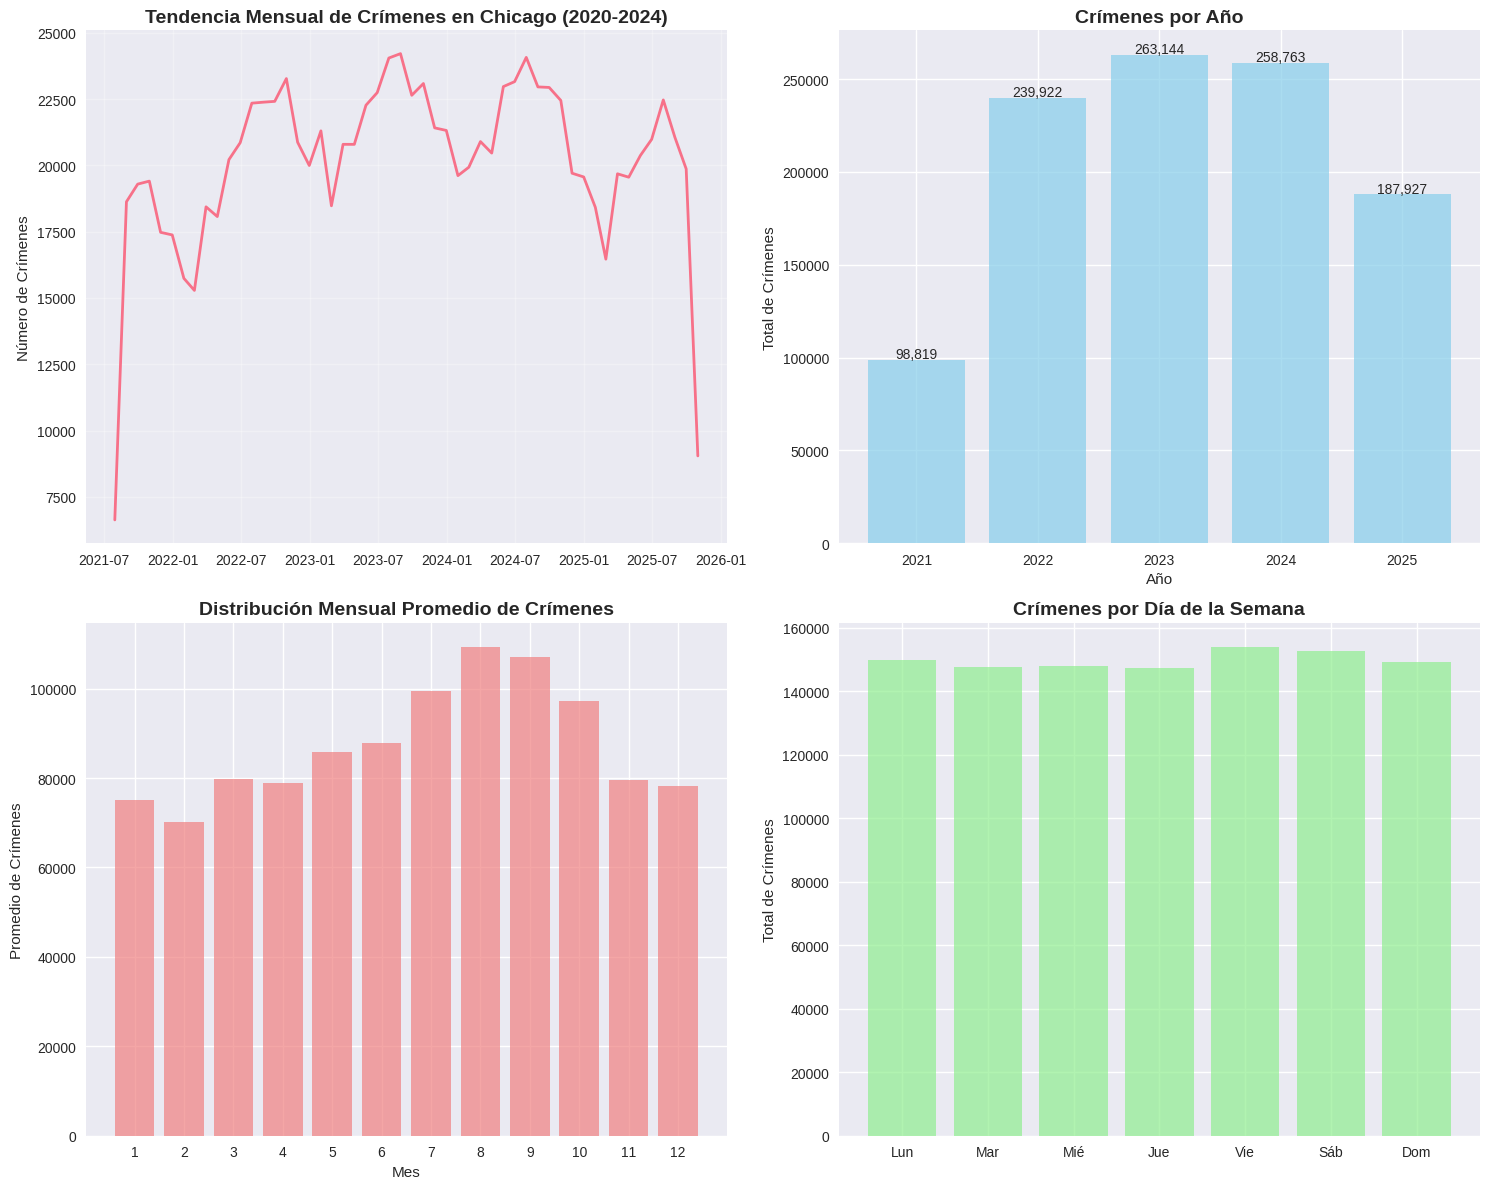


=== ANÁLISIS POR TIPO DE CRIMEN ===
Top 10 tipos de crimen:
  THEFT: 237,796
  BATTERY: 184,400
  CRIMINAL DAMAGE: 118,353
  ASSAULT: 94,006
  MOTOR VEHICLE THEFT: 91,319
  DECEPTIVE PRACTICE: 68,779
  OTHER OFFENSE: 66,734
  ROBBERY: 38,100
  BURGLARY: 34,573
  WEAPONS VIOLATION: 33,761


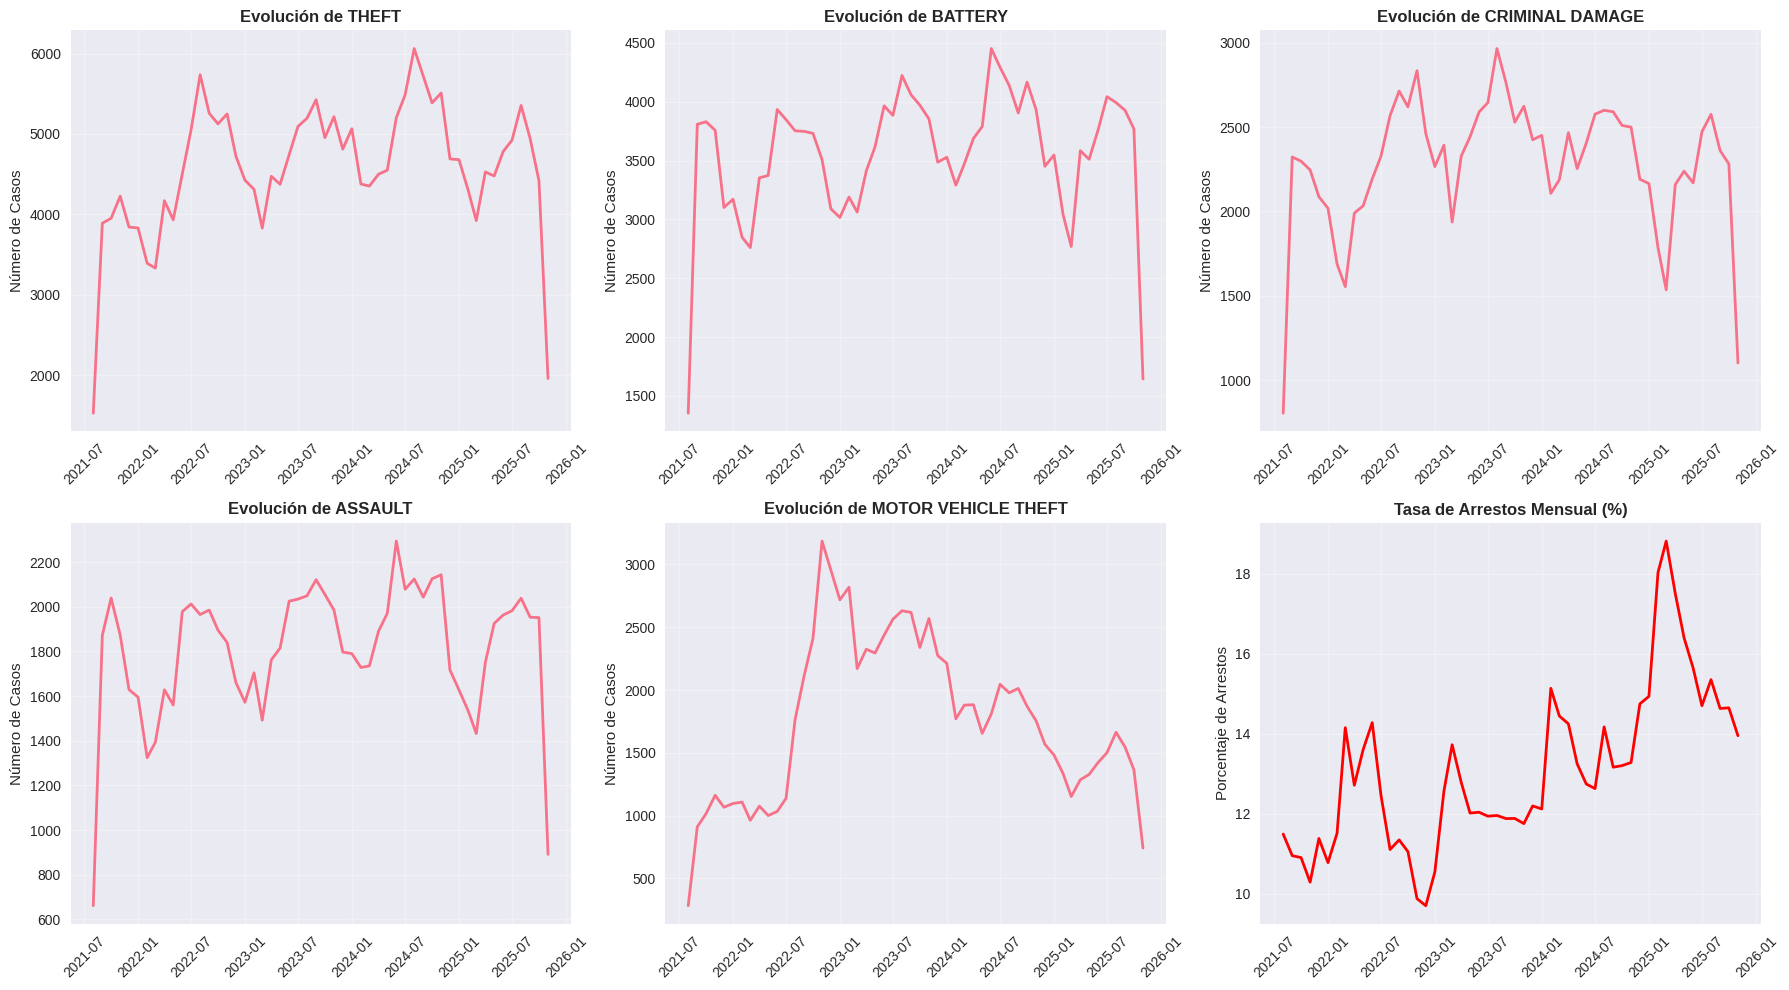


=== ANÁLISIS DE ESTACIONALIDAD ===


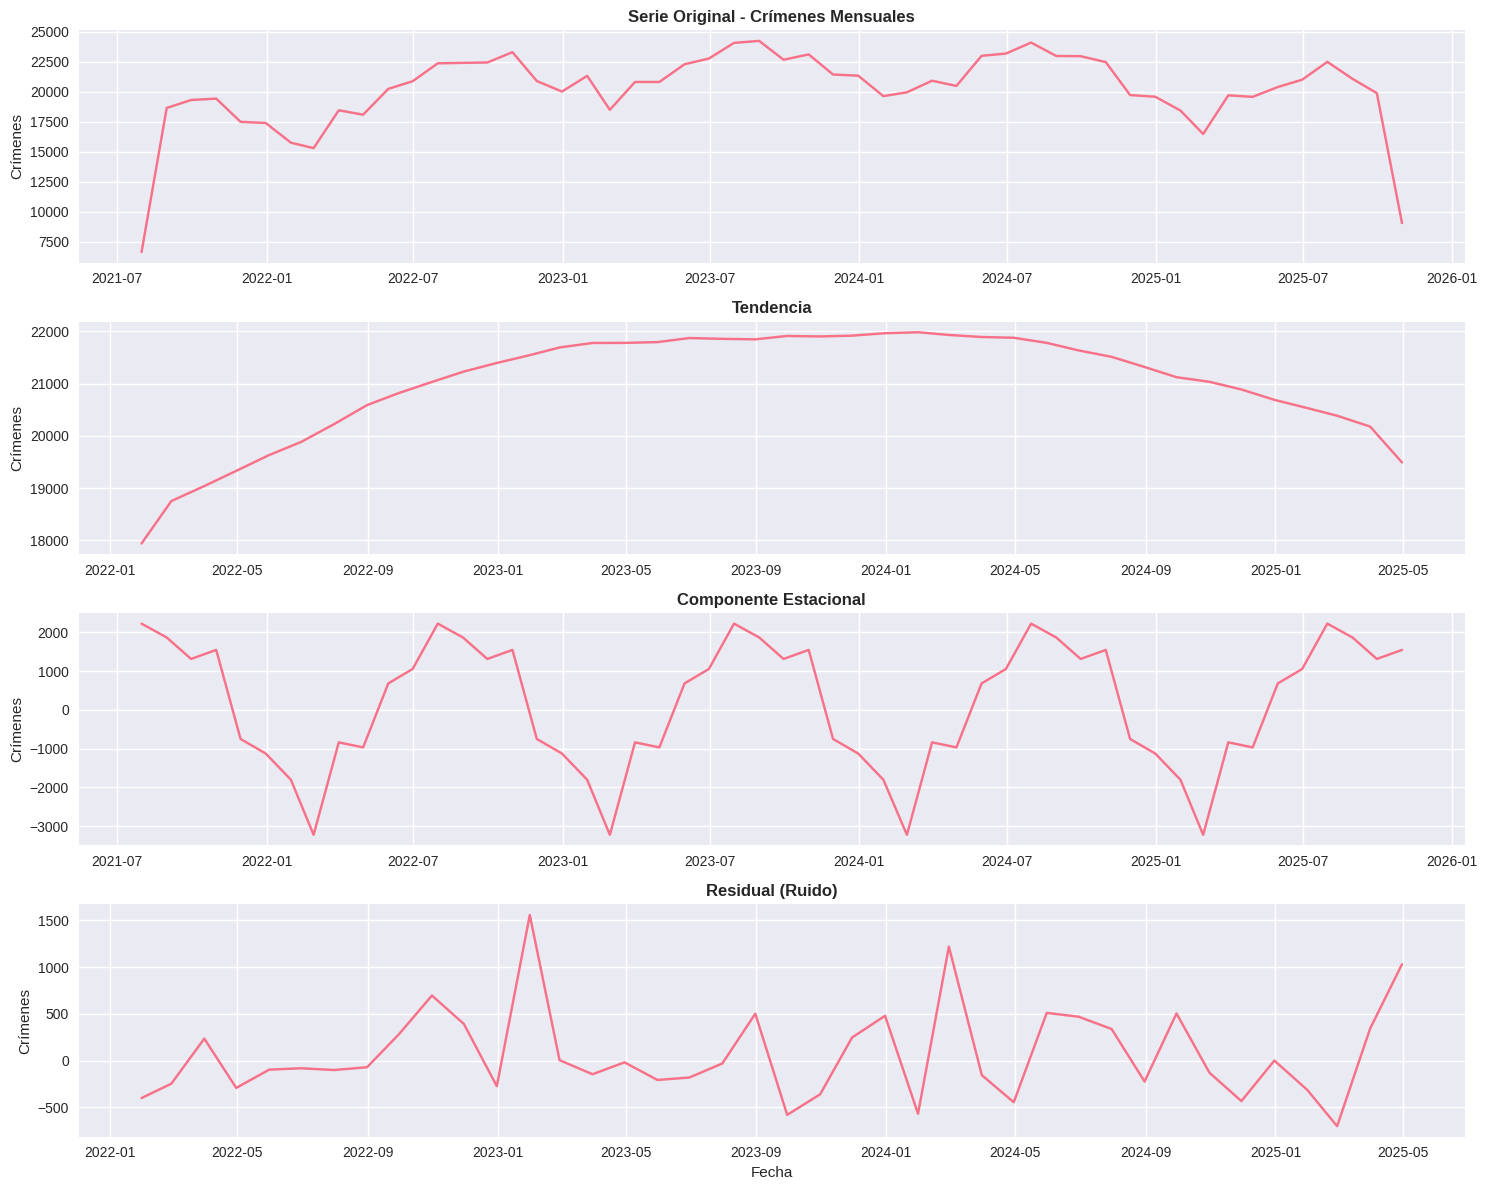


=== PRUEBAS DE ESTACIONARIEDAD ===
Prueba de estacionariedad para serie mensual:
Test Estadístico: -1.4659
p-value: 0.5503
Valores Críticos:
	1%: -3.5715
	5%: -2.9226
	10%: -2.5993
→ La serie NO ES ESTACIONARIA (no podemos rechazar H0)

=== ANÁLISIS DE AUTOCORRELACIÓN ===


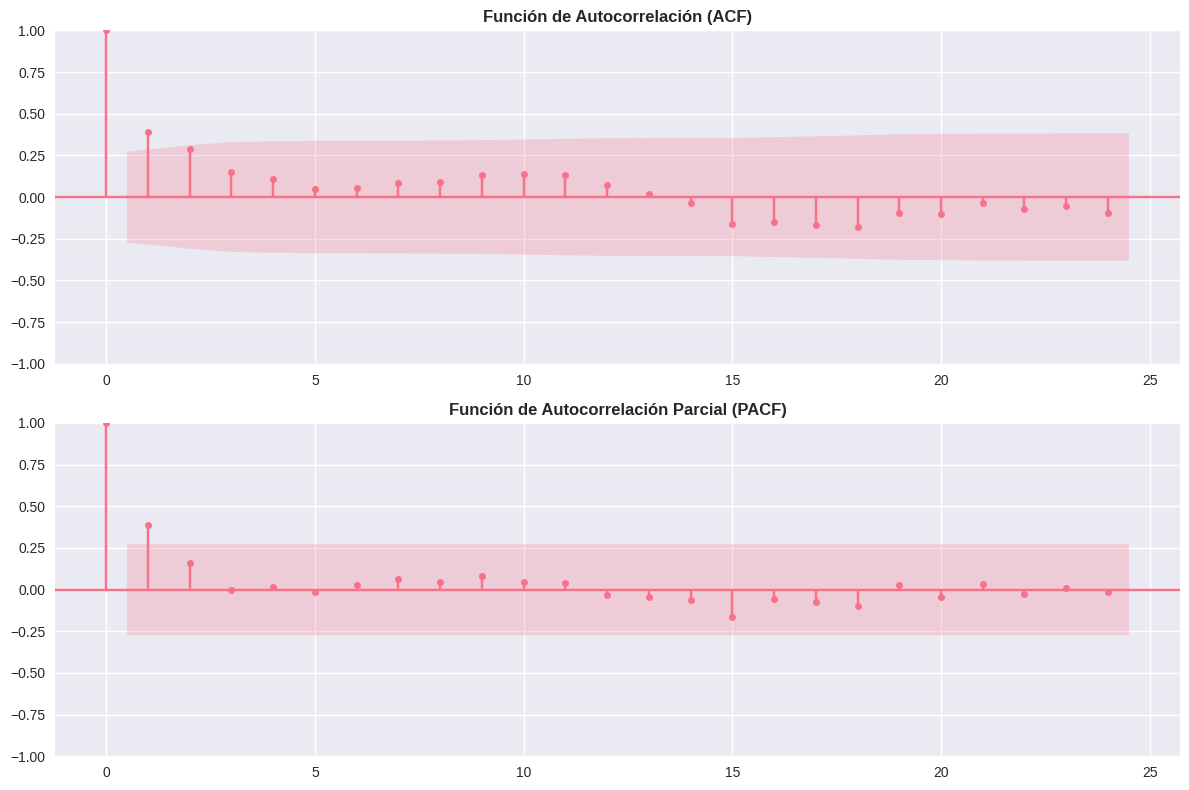


=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===
Distritos con mayor criminalidad:
  Distrito 8: 67,319 crímenes
  Distrito 12: 63,942 crímenes
  Distrito 6: 62,363 crímenes
  Distrito 4: 58,873 crímenes
  Distrito 1: 58,320 crímenes


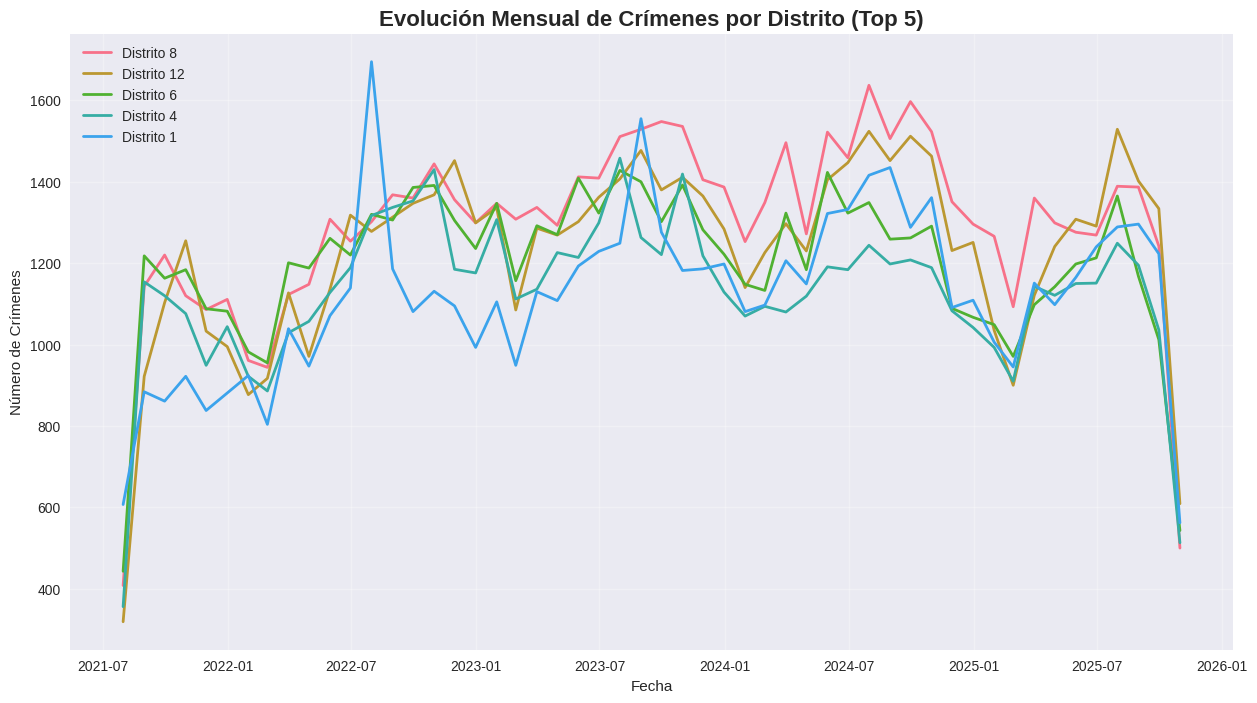


=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===


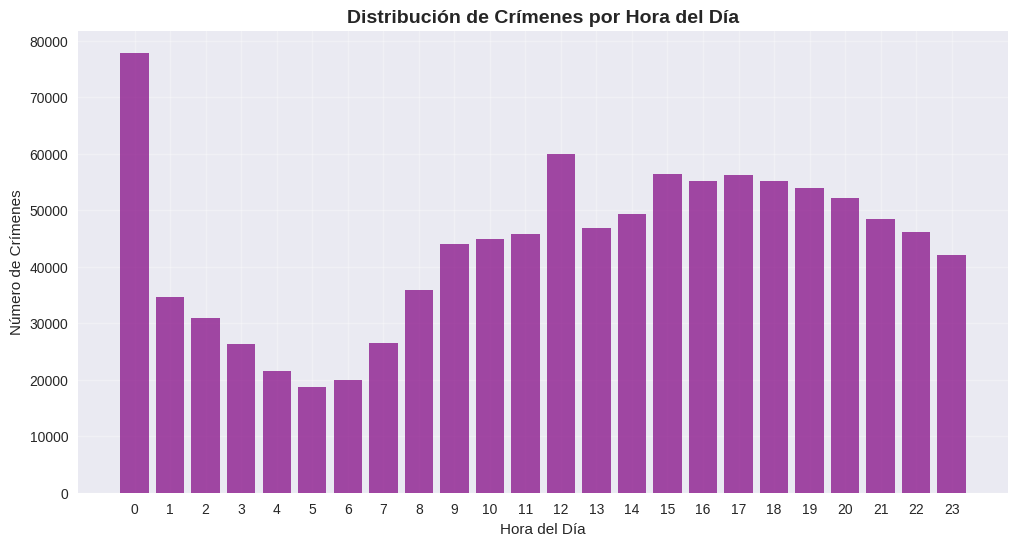


=== MODELADO DE TENDENCIAS ===

Tasas de crecimiento anual:
  2022: +142.8%
  2023: +9.7%
  2024: -1.7%
  2025: -27.4%

CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR

RESUMEN EJECUTIVO:
• Período analizado: 2021-07 a 2025-10
• Total de incidentes: 1,048,575
• Tendencia general: BAJISTA
• Distritos críticos: 8, 12, 6, 4, 1
• Tipos de crimen predominantes: THEFT, BATTERY, CRIMINAL DAMAGE, ASSAULT, MOTOR VEHICLE THEFT

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en 8 y valles en 2
2. Estacionalidad Semanal: Los días Vie muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos 8 y 12 durante 8
2. Programas preventivos enfocados en THEFT y BATTERY
3. Patrullaje intensivo los Vie
4. Monitoreo continuo de las tendencias identificadas



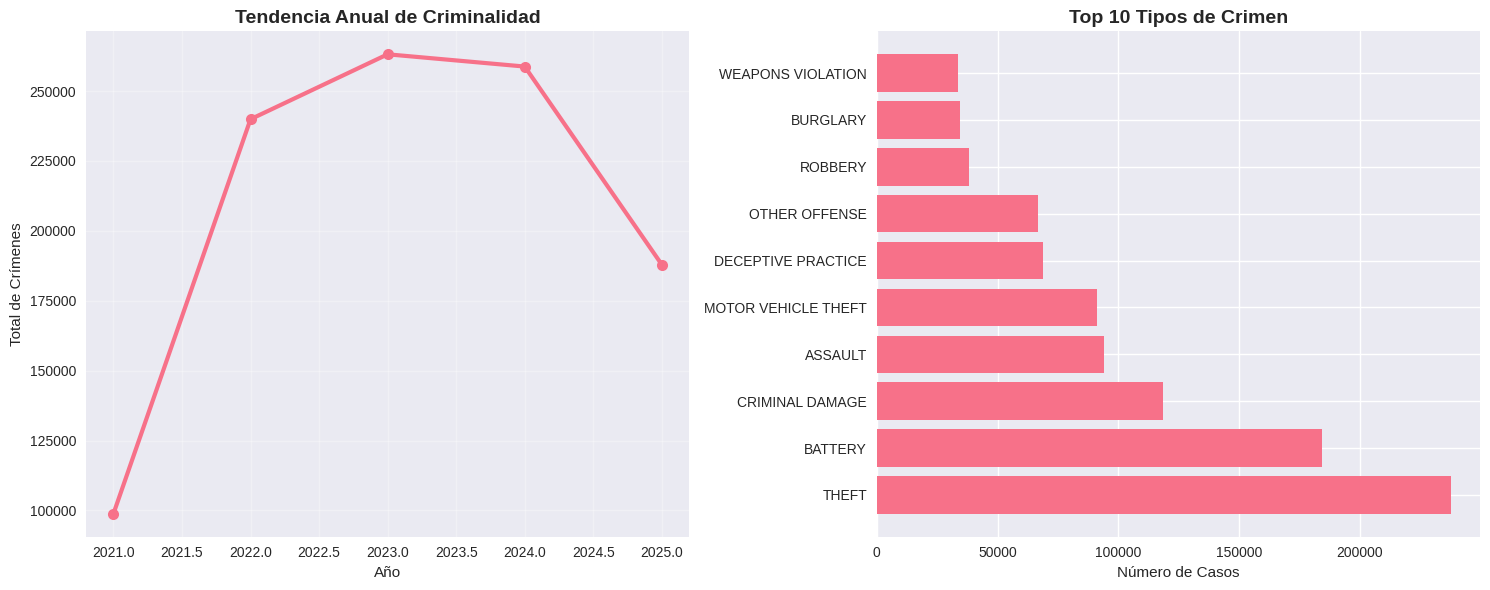

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv('Crimes.csv')

# Convertir la columna Date a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Eliminar filas con fechas inválidas
df = df.dropna(subset=['Date'])

# Ordenar por fecha
df = df.sort_values('Date')

# 1. ANÁLISIS EXPLORATORIO TEMPORAL
print("=== ANÁLISIS EXPLORATORIO TEMPORAL ===")

# Crear series temporales por diferentes periodos
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Series temporal mensual
monthly_crimes = df.resample('M', on='Date').size()
daily_crimes = df.resample('D', on='Date').size()

print(f"Período de datos: {df['Date'].min()} a {df['Date'].max()}")
print(f"Total de crímenes: {len(df):,}")
print(f"Promedio diario: {daily_crimes.mean():.0f} crímenes")

# 2. VISUALIZACIONES TEMPORALES
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Tendencia mensual
axes[0,0].plot(monthly_crimes.index, monthly_crimes.values, linewidth=2)
axes[0,0].set_title('Tendencia Mensual de Crímenes en Chicago (2020-2024)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Número de Crímenes')
axes[0,0].grid(True, alpha=0.3)

# Crímenes por año
yearly_counts = df['Year'].value_counts().sort_index()
axes[0,1].bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.7)
axes[0,1].set_title('Crímenes por Año', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Año')
axes[0,1].set_ylabel('Total de Crímenes')
for i, v in enumerate(yearly_counts.values):
    axes[0,1].text(yearly_counts.index[i], v + 1000, f'{v:,}', ha='center')

# Crímenes por mes (promedio)
monthly_avg = df.groupby('Month').size()
axes[1,0].bar(monthly_avg.index, monthly_avg.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Distribución Mensual Promedio de Crímenes', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Promedio de Crímenes')
axes[1,0].set_xticks(range(1, 13))

# Crímenes por día de la semana
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
axes[1,1].bar(dow_names, dow_counts.values, color='lightgreen', alpha=0.7)
axes[1,1].set_title('Crímenes por Día de la Semana', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Total de Crímenes')

plt.tight_layout()
plt.show()

# 3. ANÁLISIS POR TIPO DE CRIMEN A TRAVÉS DEL TIEMPO
print("\n=== ANÁLISIS POR TIPO DE CRIMEN ===")

# Top 10 tipos de crimen
top_crimes = df['Primary Type'].value_counts().head(10)
print("Top 10 tipos de crimen:")
for crime, count in top_crimes.items():
    print(f"  {crime}: {count:,}")

# Evolución de los principales tipos de crimen
top_5_crimes = top_crimes.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime_type in enumerate(top_5_crimes):
    crime_ts = df[df['Primary Type'] == crime_type].resample('M', on='Date').size()
    axes[i].plot(crime_ts.index, crime_ts.values, linewidth=2)
    axes[i].set_title(f'Evolución de {crime_type}', fontweight='bold')
    axes[i].set_ylabel('Número de Casos')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

# Tendencia de arrestos
arrest_ts = df.resample('M', on='Date')['Arrest'].mean() * 100
axes[5].plot(arrest_ts.index, arrest_ts.values, linewidth=2, color='red')
axes[5].set_title('Tasa de Arrestos Mensual (%)', fontweight='bold')
axes[5].set_ylabel('Porcentaje de Arrestos')
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. ANÁLISIS DE ESTACIONALIDAD
print("\n=== ANÁLISIS DE ESTACIONALIDAD ===")

# Descomposición estacional de la serie temporal mensual
monthly_series = monthly_crimes.astype(float)

# Completar valores faltantes si los hay
if monthly_series.isnull().any():
    monthly_series = monthly_series.interpolate()

# Descomposición estacional
decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Serie original
axes[0].plot(decomposition.observed)
axes[0].set_title('Serie Original - Crímenes Mensuales', fontweight='bold')
axes[0].set_ylabel('Crímenes')

# Tendencia
axes[1].plot(decomposition.trend)
axes[1].set_title('Tendencia', fontweight='bold')
axes[1].set_ylabel('Crímenes')

# Estacionalidad
axes[2].plot(decomposition.seasonal)
axes[2].set_title('Componente Estacional', fontweight='bold')
axes[2].set_ylabel('Crímenes')

# Residual
axes[3].plot(decomposition.resid)
axes[3].set_title('Residual (Ruido)', fontweight='bold')
axes[3].set_ylabel('Crímenes')
axes[3].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

# 5. PRUEBAS DE ESTACIONARIEDAD
print("\n=== PRUEBAS DE ESTACIONARIEDAD ===")

def test_stationarity(timeseries):
    # Dickey-Fuller test
    result = adfuller(timeseries.dropna())
    print('Test Estadístico: {:.4f}'.format(result[0]))
    print('p-value: {:.4f}'.format(result[1]))
    print('Valores Críticos:')
    for key, value in result[4].items():
        print('\t{}: {:.4f}'.format(key, value))

    if result[1] <= 0.05:
        print("→ La serie es ESTACIONARIA (rechazamos H0)")
    else:
        print("→ La serie NO ES ESTACIONARIA (no podemos rechazar H0)")

print("Prueba de estacionariedad para serie mensual:")
test_stationarity(monthly_series)

# 6. ANÁLISIS DE AUTOCORRELACIÓN
print("\n=== ANÁLISIS DE AUTOCORRELACIÓN ===")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF (Autocorrelation Function)
plot_acf(monthly_series.dropna(), ax=axes[0], lags=24)
axes[0].set_title('Función de Autocorrelación (ACF)', fontweight='bold')

# PACF (Partial Autocorrelation Function)
plot_pacf(monthly_series.dropna(), ax=axes[1], lags=24)
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontweight='bold')

plt.tight_layout()
plt.show()

# 7. ANÁLISIS DE ZONAS ESTRATÉGICAS POR DISTRITO
print("\n=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===")

# Identificar distritos con mayor criminalidad
district_crimes = df['District'].value_counts().head(5)
print("Distritos con mayor criminalidad:")
for district, count in district_crimes.items():
    print(f"  Distrito {district}: {count:,} crímenes")

# Evolución temporal por distrito
top_districts = district_crimes.index.tolist()

plt.figure(figsize=(15, 8))
for district in top_districts:
    district_ts = df[df['District'] == district].resample('M', on='Date').size()
    plt.plot(district_ts.index, district_ts.values, label=f'Distrito {district}', linewidth=2)

plt.title('Evolución Mensual de Crímenes por Distrito (Top 5)', fontsize=16, fontweight='bold')
plt.ylabel('Número de Crímenes')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 8. ANÁLISIS DE PATRONES DIARIOS Y HORARIOS
print("\n=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===")

# Extraer hora del día (si está disponible en los datos)
try:
    df['Hour'] = df['Date'].dt.hour
    hourly_pattern = df['Hour'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(hourly_pattern.index, hourly_pattern.values, color='purple', alpha=0.7)
    plt.title('Distribución de Crímenes por Hora del Día', fontsize=14, fontweight='bold')
    plt.xlabel('Hora del Día')
    plt.ylabel('Número de Crímenes')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.show()
except:
    print("Información de hora no disponible en los datos")

# 9. MODELADO DE TENDENCIAS
print("\n=== MODELADO DE TENDENCIAS ===")

# Calcular tasas de crecimiento anual
yearly_growth = yearly_counts.pct_change() * 100
print("\nTasas de crecimiento anual:")
for year, growth in yearly_growth.items():
    if not pd.isna(growth):
        print(f"  {year}: {growth:+.1f}%")

# 10. PRONÓSTICO SIMPLE Y RECOMENDACIONES
print("\n" + "="*50)
print("CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR")
print("="*50)

# Resumen ejecutivo
print(f"""
RESUMEN EJECUTIVO:
• Período analizado: {df['Date'].min().strftime('%Y-%m')} a {df['Date'].max().strftime('%Y-%m')}
• Total de incidentes: {len(df):,}
• Tendencia general: {'ALCISTA' if yearly_growth.iloc[-1] > 0 else 'BAJISTA' if yearly_growth.iloc[-1] < 0 else 'ESTABLE'}
• Distritos críticos: {', '.join(map(str, top_districts))}
• Tipos de crimen predominantes: {', '.join(top_5_crimes)}

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en {monthly_avg.idxmax()} y valles en {monthly_avg.idxmin()}
2. Estacionalidad Semanal: Los días {dow_names[dow_counts.idxmax()]} muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos {top_districts[0]} y {top_districts[1]} durante {monthly_avg.idxmax()}
2. Programas preventivos enfocados en {top_5_crimes[0]} y {top_5_crimes[1]}
3. Patrullaje intensivo los {dow_names[dow_counts.idxmax()]}
4. Monitoreo continuo de las tendencias identificadas
""")

# Visualización final resumen
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Resumen anual con tendencia
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=3, markersize=8)
axes[0].set_title('Tendencia Anual de Criminalidad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Total de Crímenes')
axes[0].grid(True, alpha=0.3)

# Distribución por tipo de crimen (top 10)
axes[1].barh(range(len(top_crimes)), top_crimes.values)
axes[1].set_yticks(range(len(top_crimes)))
axes[1].set_yticklabels(top_crimes.index)
axes[1].set_title('Top 10 Tipos de Crimen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Casos')

plt.tight_layout()
plt.show()

## Second Version


=== ANÁLISIS EXPLORATORIO TEMPORAL ===
Período de datos: 2021-07-21 19:35:00 a 2025-10-15 00:00:00
Total de crímenes: 1,048,575
Rango de años: 2021 - 2025
Número de meses únicos: 52


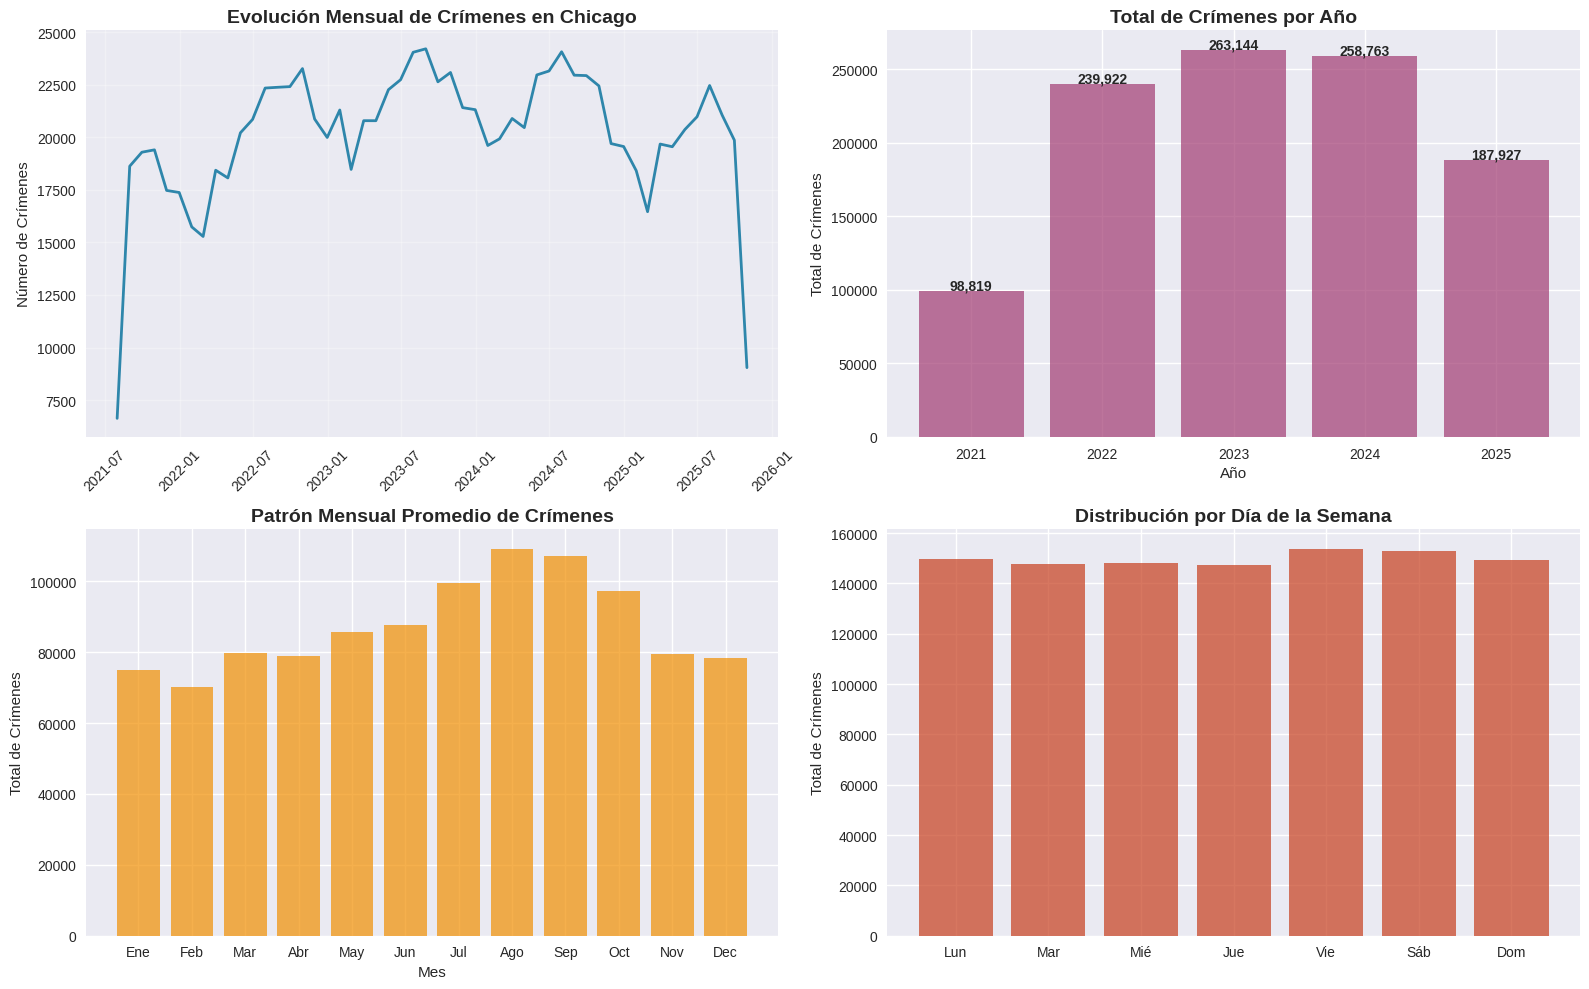


=== ANÁLISIS DE ESTACIONALIDAD Y TENDENCIAS ===


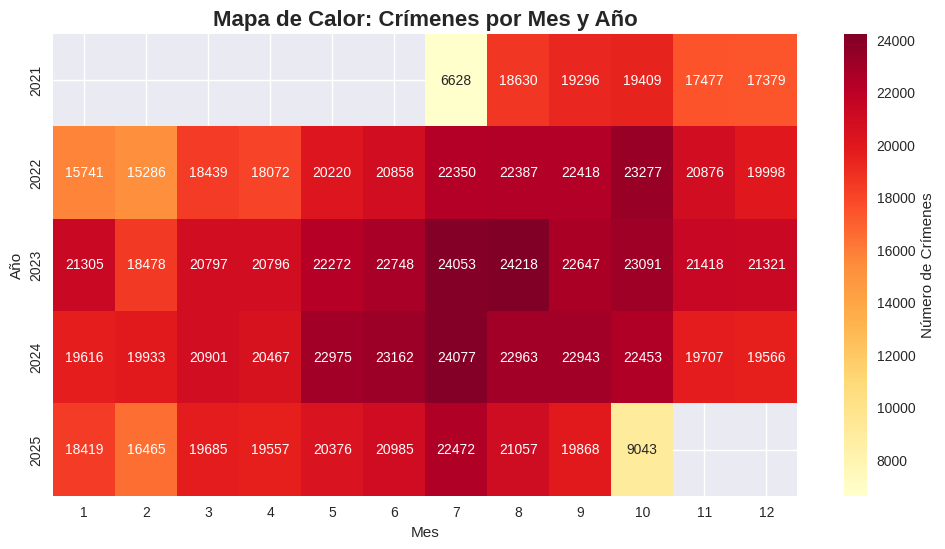


=== ANÁLISIS CON MEDIAS MÓVILES ===


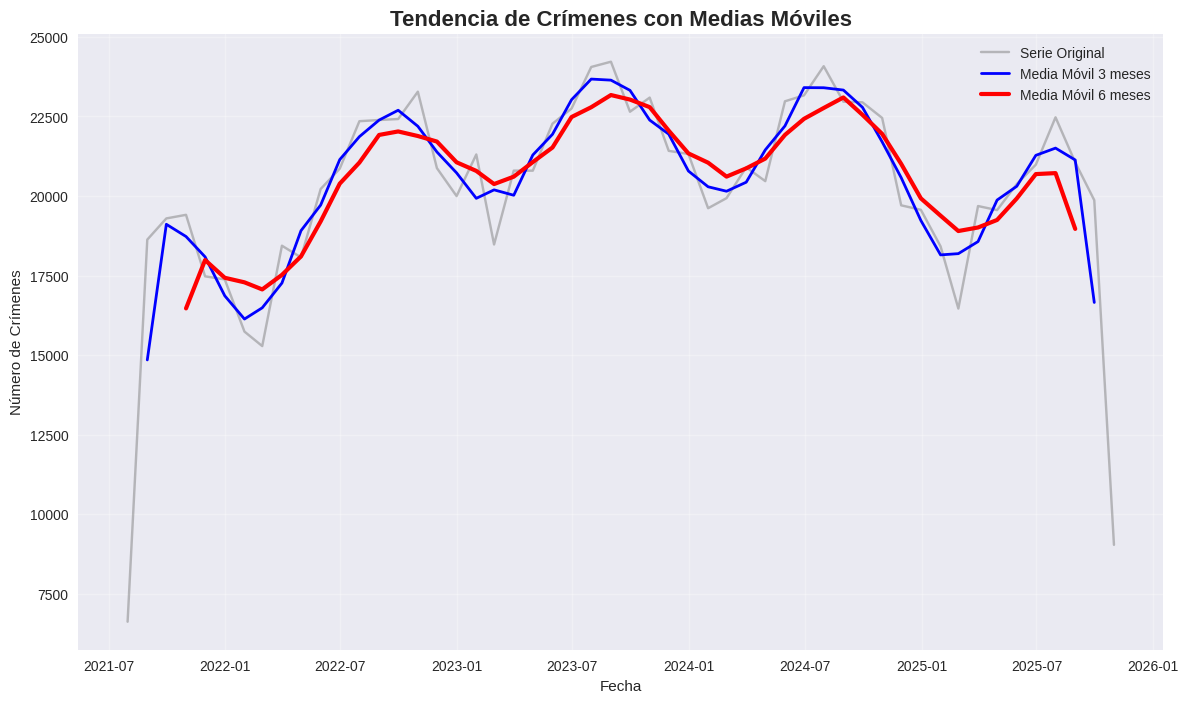


=== PRUEBAS DE ESTACIONARIEDAD ===
Prueba de estacionariedad para serie mensual original:

Serie Mensual Original:
----------------------------------------
Test Estadístico: -1.4659
p-value: 0.5503
Valores Críticos:
	1%: -3.5715
	5%: -2.9226
	10%: -2.5993
❌ La serie NO ES ESTACIONARIA (no podemos rechazar H0)

Prueba de estacionariedad para serie con diferencia de primer orden:

Serie con Primera Diferencia:
----------------------------------------
Test Estadístico: -2.5310
p-value: 0.1081
Valores Críticos:
	1%: -3.5813
	5%: -2.9268
	10%: -2.6015
❌ La serie NO ES ESTACIONARIA (no podemos rechazar H0)

=== ANÁLISIS DE AUTOCORRELACIÓN ===


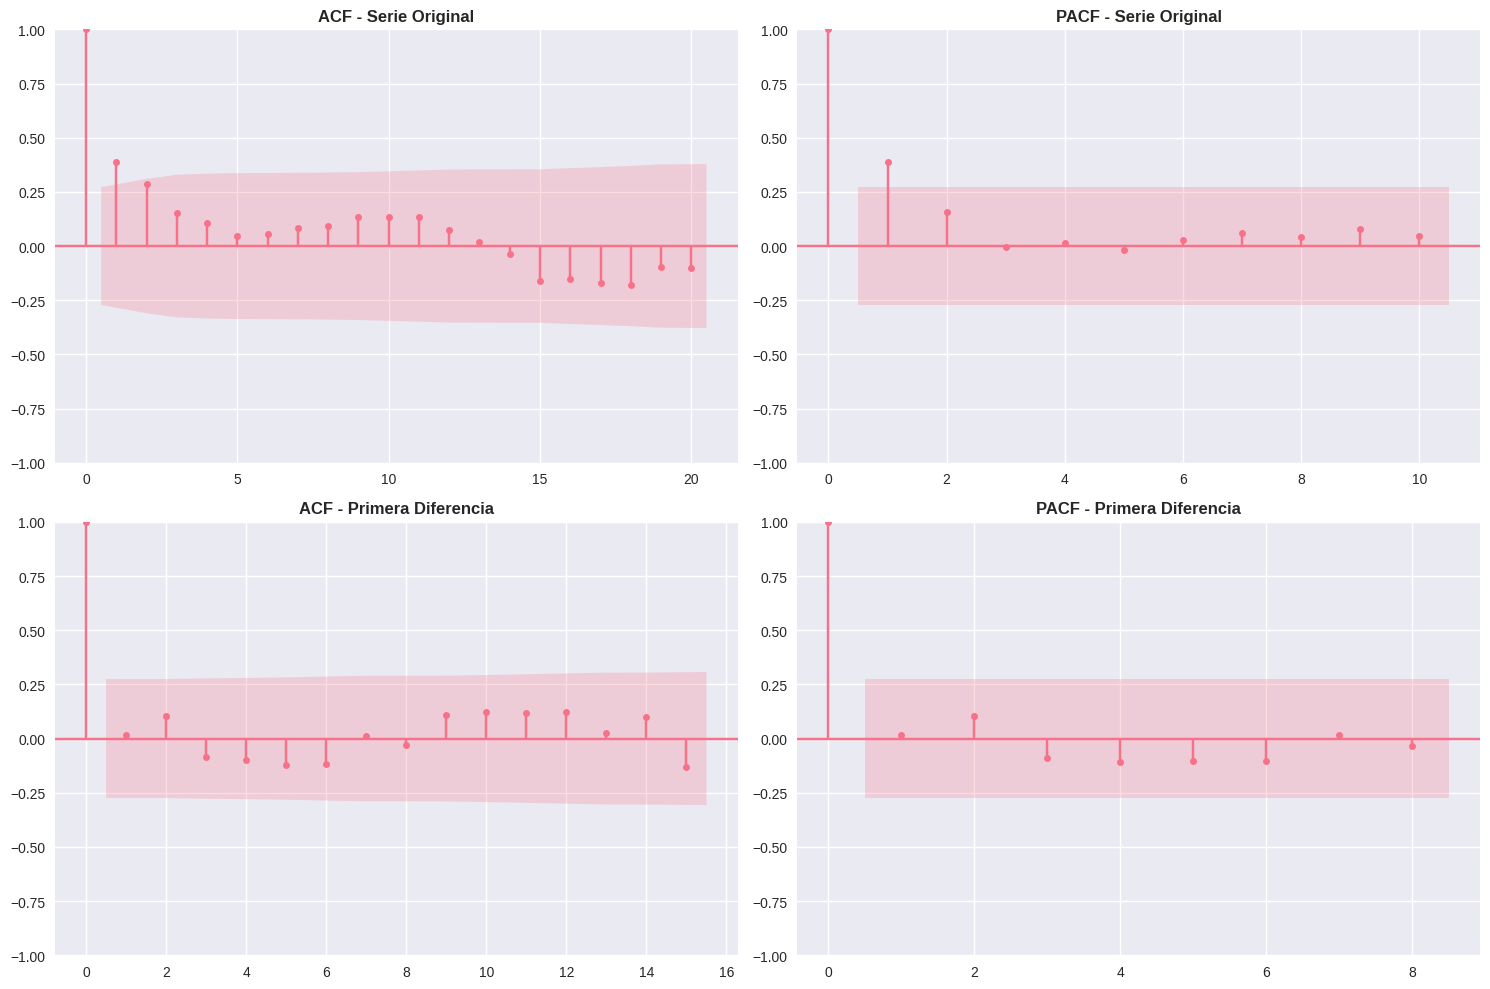


=== ANÁLISIS POR TIPO DE CRIMEN ===
Tipos de crimen más frecuentes:
  1. THEFT: 237,796
  2. BATTERY: 184,400
  3. CRIMINAL DAMAGE: 118,353
  4. ASSAULT: 94,006
  5. MOTOR VEHICLE THEFT: 91,319
  6. DECEPTIVE PRACTICE: 68,779
  7. OTHER OFFENSE: 66,734
  8. ROBBERY: 38,100


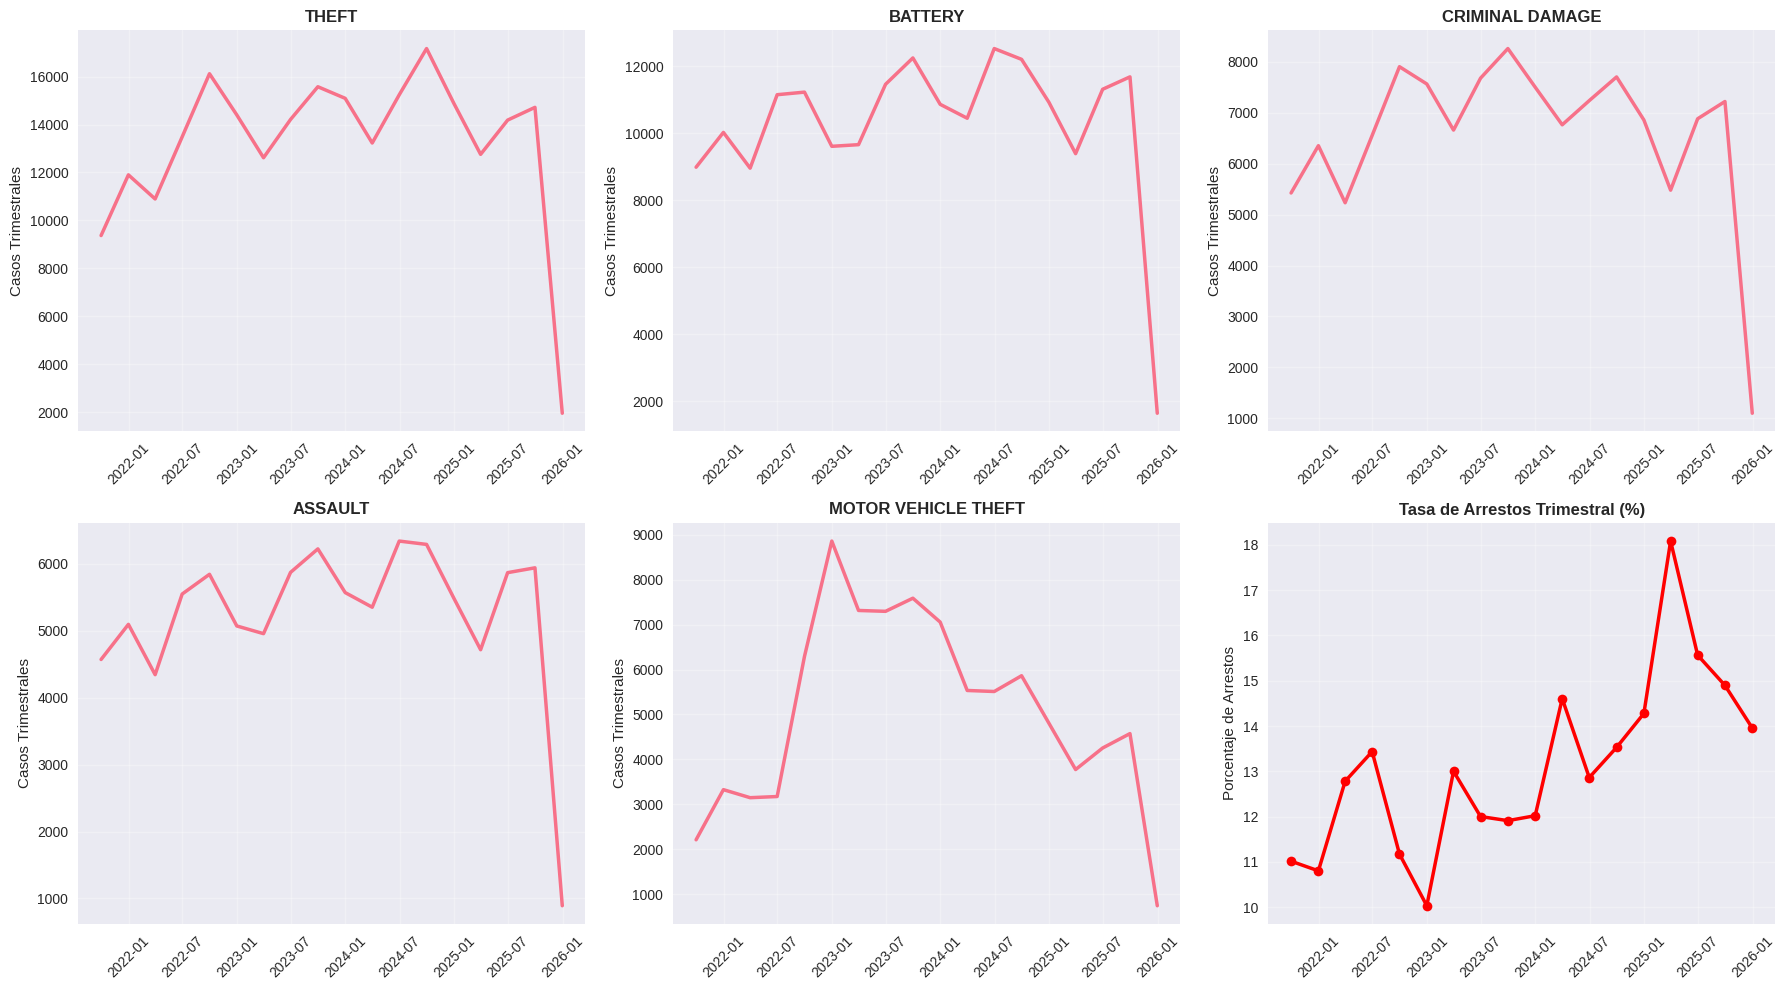


=== ANÁLISIS POR DISTRITOS ESTRATÉGICOS ===


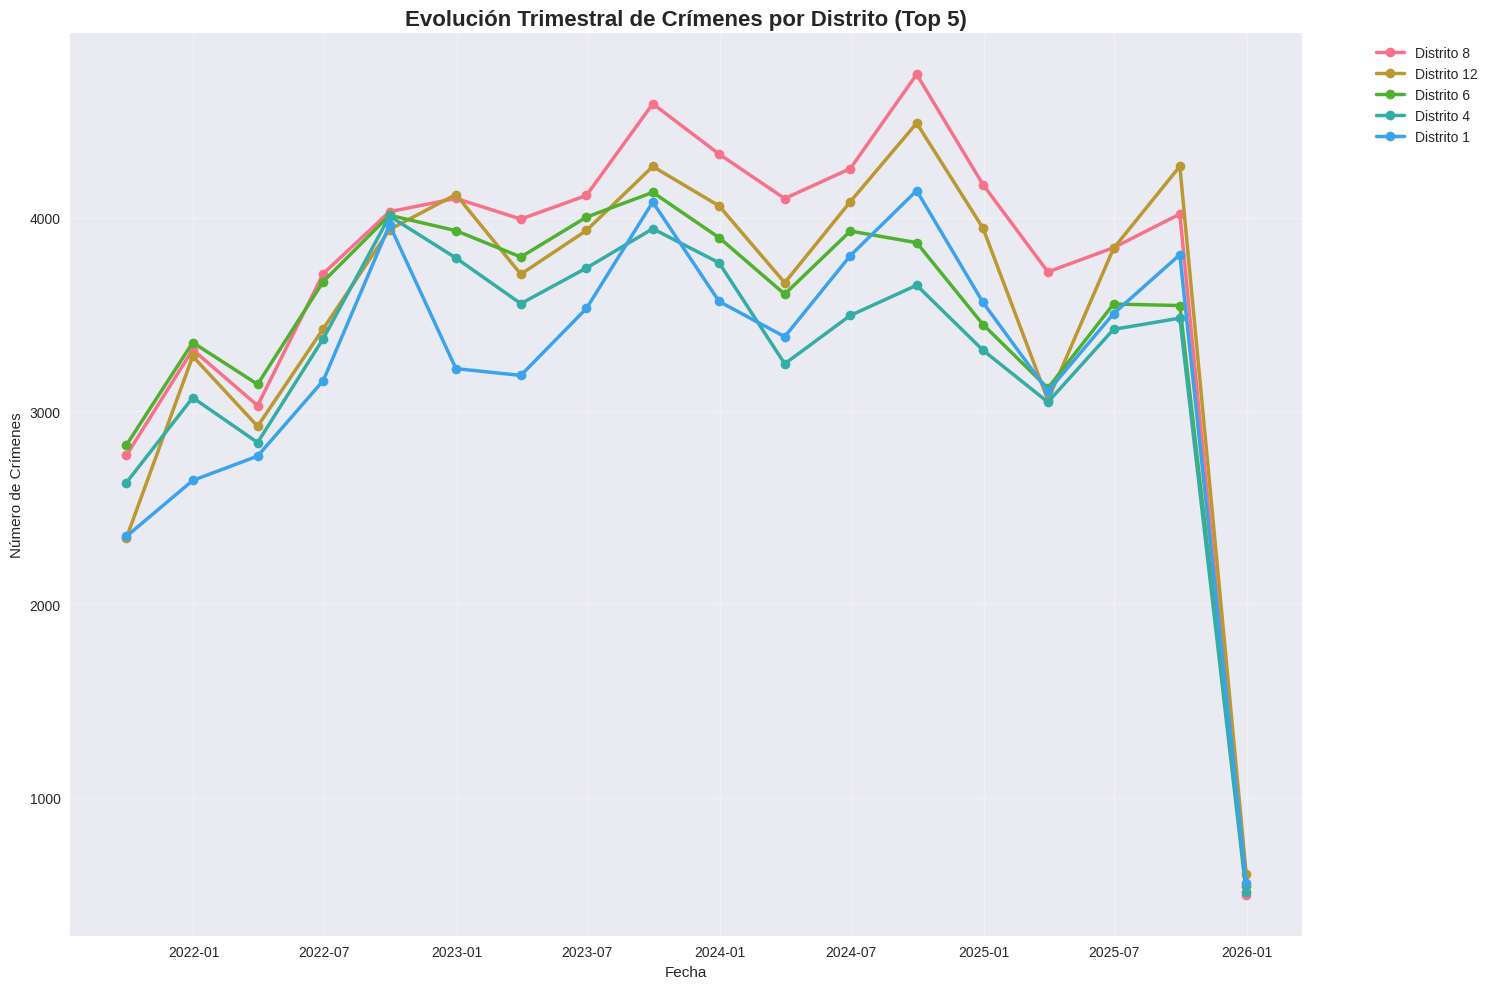


=== ANÁLISIS DE TENDENCIAS ===

Tasas de crecimiento anual:
  📈 2022: +142.8%
  📈 2023: +9.7%
  📉 2024: -1.7%
  📉 2025: -27.4%


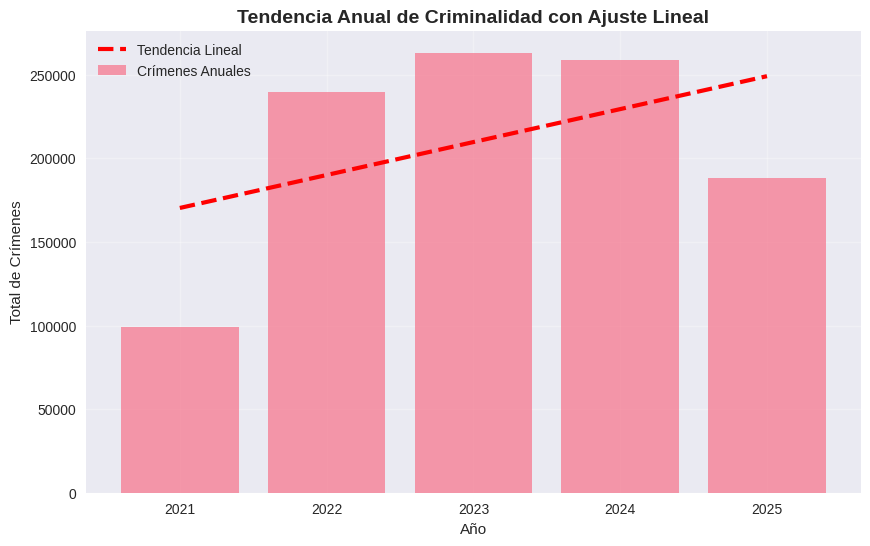


INFORME EJECUTIVO: ANÁLISIS TEMPORAL DE CRIMINALIDAD

📊 RESUMEN EJECUTIVO:
• Período analizado: Jul 2021 a Oct 2025
• Total de incidentes registrados: 1,048,575
• Tendencia general: ALCISTA
• Distritos más críticos: 8, 12, 6
• Tipos de crimen predominantes: THEFT, BATTERY, CRIMINAL DAMAGE

🎯 HALLazgos TEMPORALES CLAVE:
1. Estacionalidad Mensual: Mayor incidencia en Ago
2. Patrón Semanal: Picos los Vie
3. Comportamiento Temporal: Serie no estacionaria
4. Autocorrelación: Patrones significativos

💡 RECOMENDACIONES ESTRATÉGICAS:

1. REFUERZO ESTACIONAL:
   • Intensificar patrullaje en Ago
   • Programas preventivos antes de temporadas críticas

2. OPTIMIZACIÓN DE RECURSOS:
   • Focalizar en distritos 8 y 12
   • Refuerzo los fines de semana (Sáb, Dom)

3. INTERVENCIONES ESPECÍFICAS:
   • Programas contra theft
   • Estrategias para reducir battery

4. MONITOREO CONTINUO:
   • Sistema de alerta temprana basado en patrones temporales
   • Evaluación trimestral de tendencias



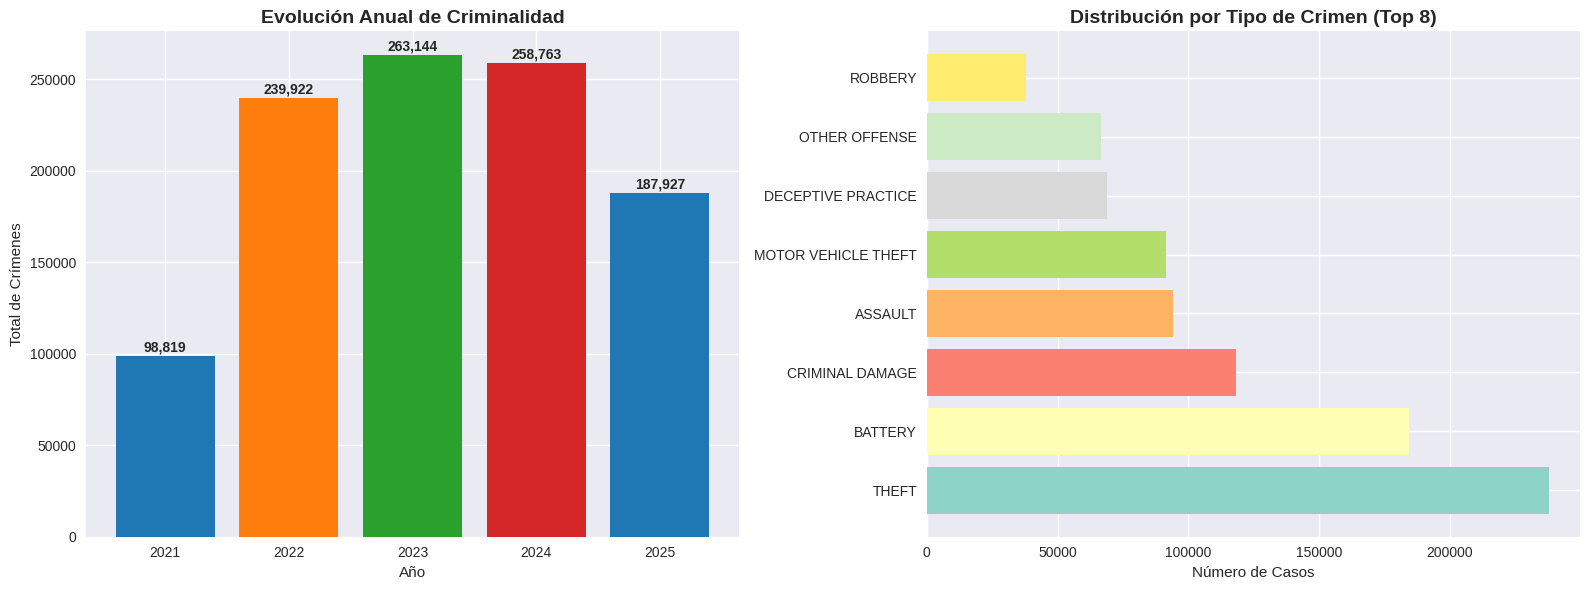


✅ Análisis temporal completado exitosamente!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar los datos (ajusta la ruta según tu archivo)
df = pd.read_csv('Crimes.csv')

# Convertir la columna Date a datetime y ordenar
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')

# 1. ANÁLISIS EXPLORATORIO TEMPORAL MEJORADO
print("=== ANÁLISIS EXPLORATORIO TEMPORAL ===")

# Crear series temporales
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Series temporal mensual y diaria
monthly_crimes = df.resample('M', on='Date').size()
daily_crimes = df.resample('D', on='Date').size()

print(f"Período de datos: {df['Date'].min()} a {df['Date'].max()}")
print(f"Total de crímenes: {len(df):,}")
print(f"Rango de años: {df['Year'].min()} - {df['Year'].max()}")
print(f"Número de meses únicos: {monthly_crimes.shape[0]}")

# 2. VISUALIZACIONES TEMPORALES PRINCIPALES
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tendencia mensual
axes[0,0].plot(monthly_crimes.index, monthly_crimes.values, linewidth=2, color='#2E86AB')
axes[0,0].set_title('Evolución Mensual de Crímenes en Chicago', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Número de Crímenes')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Crímenes por año
yearly_counts = df['Year'].value_counts().sort_index()
axes[0,1].bar(yearly_counts.index, yearly_counts.values, color='#A23B72', alpha=0.7)
axes[0,1].set_title('Total de Crímenes por Año', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Año')
axes[0,1].set_ylabel('Total de Crímenes')
for i, v in enumerate(yearly_counts.values):
    axes[0,1].text(yearly_counts.index[i], v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Crímenes por mes (promedio multi-anual)
monthly_pattern = df.groupby('Month').size()
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1,0].bar(month_names, monthly_pattern.values, color='#F18F01', alpha=0.7)
axes[1,0].set_title('Patrón Mensual Promedio de Crímenes', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Total de Crímenes')

# Crímenes por día de la semana
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
axes[1,1].bar(dow_names, dow_counts.values, color='#C73E1D', alpha=0.7)
axes[1,1].set_title('Distribución por Día de la Semana', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Total de Crímenes')

plt.tight_layout()
plt.show()

# 3. ANÁLISIS DE ESTACIONALIDAD ALTERNATIVO
print("\n=== ANÁLISIS DE ESTACIONALIDAD Y TENDENCIAS ===")

# Método alternativo: Promedio mensual por año
monthly_heatmap_data = df.pivot_table(
    index=df['Date'].dt.year,
    columns=df['Date'].dt.month,
    values='ID',
    aggfunc='count'
)

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Número de Crímenes'})
plt.title('Mapa de Calor: Crímenes por Mes y Año', fontsize=16, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

# 4. ANÁLISIS DE TENDENCIAS CON MEDIAS MÓVILES
print("\n=== ANÁLISIS CON MEDIAS MÓVILES ===")

# Calcular medias móviles para suavizar la serie
monthly_series = monthly_crimes.astype(float)

# Media móvil de 3 meses (suavizado a corto plazo)
ma_3months = monthly_series.rolling(window=3, center=True).mean()

# Media móvil de 6 meses (tendencia a medio plazo)
ma_6months = monthly_series.rolling(window=6, center=True).mean()

plt.figure(figsize=(14, 8))

# Serie original y medias móviles
plt.plot(monthly_series.index, monthly_series.values, alpha=0.5, label='Serie Original', color='gray')
plt.plot(ma_3months.index, ma_3months.values, linewidth=2, label='Media Móvil 3 meses', color='blue')
plt.plot(ma_6months.index, ma_6months.values, linewidth=3, label='Media Móvil 6 meses', color='red')

plt.title('Tendencia de Crímenes con Medias Móviles', fontsize=16, fontweight='bold')
plt.ylabel('Número de Crímenes')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. PRUEBAS DE ESTACIONARIEDAD MEJORADAS
print("\n=== PRUEBAS DE ESTACIONARIEDAD ===")

def test_stationarity(timeseries, title="Serie Temporal"):
    """Función mejorada para prueba de estacionariedad"""

    # Dickey-Fuller test
    result = adfuller(timeseries.dropna())

    print(f'\n{title}:')
    print('-' * 40)
    print('Test Estadístico: {:.4f}'.format(result[0]))
    print('p-value: {:.4f}'.format(result[1]))
    print('Valores Críticos:')
    for key, value in result[4].items():
        print('\t{}: {:.4f}'.format(key, value))

    if result[1] <= 0.05:
        print("✅ La serie es ESTACIONARIA (rechazamos H0)")
        return True
    else:
        print("❌ La serie NO ES ESTACIONARIA (no podemos rechazar H0)")
        return False

# Probar diferentes series
print("Prueba de estacionariedad para serie mensual original:")
original_stationary = test_stationarity(monthly_series, "Serie Mensual Original")

print("\nPrueba de estacionariedad para serie con diferencia de primer orden:")
first_diff = monthly_series.diff().dropna()
diff_stationary = test_stationarity(first_diff, "Serie con Primera Diferencia")

# 6. ANÁLISIS DE AUTOCORRELACIÓN COMPLETO
print("\n=== ANÁLISIS DE AUTOCORRELACIÓN ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF y PACF de la serie original
plot_acf(monthly_series.dropna(), ax=axes[0,0], lags=min(20, len(monthly_series)//2))
axes[0,0].set_title('ACF - Serie Original', fontweight='bold')

plot_pacf(monthly_series.dropna(), ax=axes[0,1], lags=min(10, len(monthly_series)//3))
axes[0,1].set_title('PACF - Serie Original', fontweight='bold')

# ACF y PACF de la serie diferenciada
plot_acf(first_diff.dropna(), ax=axes[1,0], lags=min(15, len(first_diff)//2))
axes[1,0].set_title('ACF - Primera Diferencia', fontweight='bold')

plot_pacf(first_diff.dropna(), ax=axes[1,1], lags=min(8, len(first_diff)//3))
axes[1,1].set_title('PACF - Primera Diferencia', fontweight='bold')

plt.tight_layout()
plt.show()

# 7. ANÁLISIS POR TIPO DE CRIMEN A TRAVÉS DEL TIEMPO
print("\n=== ANÁLISIS POR TIPO DE CRIMEN ===")

# Top 8 tipos de crimen (reducido para mejor visualización)
top_crimes = df['Primary Type'].value_counts().head(8)
print("Tipos de crimen más frecuentes:")
for i, (crime, count) in enumerate(top_crimes.items(), 1):
    print(f"  {i}. {crime}: {count:,}")

# Evolución temporal de los principales tipos
top_5_crimes = top_crimes.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime_type in enumerate(top_5_crimes):
    crime_ts = df[df['Primary Type'] == crime_type].resample('Q', on='Date').size()  # Trimestral para más suavizado
    axes[i].plot(crime_ts.index, crime_ts.values, linewidth=2.5)
    axes[i].set_title(f'{crime_type}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Casos Trimestrales')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

# Tasa de arrestos trimestral
arrest_ts = df.resample('Q', on='Date')['Arrest'].mean() * 100
axes[5].plot(arrest_ts.index, arrest_ts.values, linewidth=2.5, color='red', marker='o')
axes[5].set_title('Tasa de Arrestos Trimestral (%)', fontweight='bold')
axes[5].set_ylabel('Porcentaje de Arrestos')
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 8. ANÁLISIS DE ZONAS ESTRATÉGICAS - DISTRITOS
print("\n=== ANÁLISIS POR DISTRITOS ESTRATÉGICOS ===")

# Identificar distritos con mayor criminalidad
district_analysis = df['District'].value_counts().head(6)

plt.figure(figsize=(15, 10))

# Evolución trimestral por distrito top 5
top_districts = district_analysis.head(5).index.tolist()

for i, district in enumerate(top_districts):
    district_ts = df[df['District'] == district].resample('Q', on='Date').size()
    plt.plot(district_ts.index, district_ts.values, label=f'Distrito {district}',
             linewidth=2.5, marker='o')

plt.title('Evolución Trimestral de Crímenes por Distrito (Top 5)', fontsize=16, fontweight='bold')
plt.ylabel('Número de Crímenes')
plt.xlabel('Fecha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. MODELADO DE TENDENCIAS Y PROYECCIONES
print("\n=== ANÁLISIS DE TENDENCIAS ===")

# Calcular tasas de crecimiento anual
yearly_growth = yearly_counts.pct_change() * 100
print("\nTasas de crecimiento anual:")
for year, growth in yearly_growth.items():
    if not pd.isna(growth):
        trend_icon = "📈" if growth > 0 else "📉" if growth < 0 else "➡️"
        print(f"  {trend_icon} {year}: {growth:+.1f}%")

# Tendencia lineal simple (para visualización)
if len(yearly_counts) > 1:
    x = np.arange(len(yearly_counts))
    y = yearly_counts.values
    z = np.polyfit(x, y, 1)
    trend_line = np.poly1d(z)

    plt.figure(figsize=(10, 6))
    plt.bar(yearly_counts.index, yearly_counts.values, alpha=0.7, label='Crímenes Anuales')
    plt.plot(yearly_counts.index, trend_line(x), 'r--', linewidth=3, label='Tendencia Lineal')
    plt.title('Tendencia Anual de Criminalidad con Ajuste Lineal', fontsize=14, fontweight='bold')
    plt.xlabel('Año')
    plt.ylabel('Total de Crímenes')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# 10. INFORME EJECUTIVO FINAL
print("\n" + "="*60)
print("INFORME EJECUTIVO: ANÁLISIS TEMPORAL DE CRIMINALIDAD")
print("="*60)

# Análisis de patrones clave
peak_month = monthly_pattern.idxmax()
peak_day = dow_counts.idxmax()
trend_direction = "ALCISTA" if z[0] > 0 else "BAJISTA" if z[0] < 0 else "ESTABLE"

print(f"""
📊 RESUMEN EJECUTIVO:
• Período analizado: {df['Date'].min().strftime('%b %Y')} a {df['Date'].max().strftime('%b %Y')}
• Total de incidentes registrados: {len(df):,}
• Tendencia general: {trend_direction}
• Distritos más críticos: {', '.join(map(str, top_districts[:3]))}
• Tipos de crimen predominantes: {', '.join(top_5_crimes[:3])}

🎯 HALLazgos TEMPORALES CLAVE:
1. Estacionalidad Mensual: Mayor incidencia en {month_names[peak_month-1]}
2. Patrón Semanal: Picos los {dow_names[peak_day]}
3. Comportamiento Temporal: Serie {'estacionaria' if diff_stationary else 'no estacionaria'}
4. Autocorrelación: Patrones {'significativos' if any(abs(np.diff(monthly_series)) > np.std(monthly_series)) else 'aleatorios'}

💡 RECOMENDACIONES ESTRATÉGICAS:

1. REFUERZO ESTACIONAL:
   • Intensificar patrullaje en {month_names[peak_month-1]}
   • Programas preventivos antes de temporadas críticas

2. OPTIMIZACIÓN DE RECURSOS:
   • Focalizar en distritos {top_districts[0]} y {top_districts[1]}
   • Refuerzo los fines de semana ({dow_names[-2]}, {dow_names[-1]})

3. INTERVENCIONES ESPECÍFICAS:
   • Programas contra {top_5_crimes[0].lower()}
   • Estrategias para reducir {top_5_crimes[1].lower()}

4. MONITOREO CONTINUO:
   • Sistema de alerta temprana basado en patrones temporales
   • Evaluación trimestral de tendencias
""")

# Visualización final de resumen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resumen anual comparativo
axes[0].bar(yearly_counts.index, yearly_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Evolución Anual de Criminalidad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Total de Crímenes')
for i, v in enumerate(yearly_counts.values):
    axes[0].text(yearly_counts.index[i], v + yearly_counts.max()*0.01,
                f'{v:,}', ha='center', fontweight='bold')

# Distribución por tipo de crimen (top 8)
axes[1].barh(range(len(top_crimes)), top_crimes.values,
             color=plt.cm.Set3(np.linspace(0, 1, len(top_crimes))))
axes[1].set_yticks(range(len(top_crimes)))
axes[1].set_yticklabels([label[:20] + '...' if len(label) > 20 else label
                        for label in top_crimes.index])
axes[1].set_title('Distribución por Tipo de Crimen (Top 8)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Casos')

plt.tight_layout()
plt.show()

print("\n✅ Análisis temporal completado exitosamente!")

## Thrid Version

=== ANÁLISIS EXPLORATORIO TEMPORAL ===
Período de datos: 2021-07-21 19:35:00 a 2025-10-15 00:00:00
Total de crímenes: 1,048,575
Promedio diario: 677 crímenes


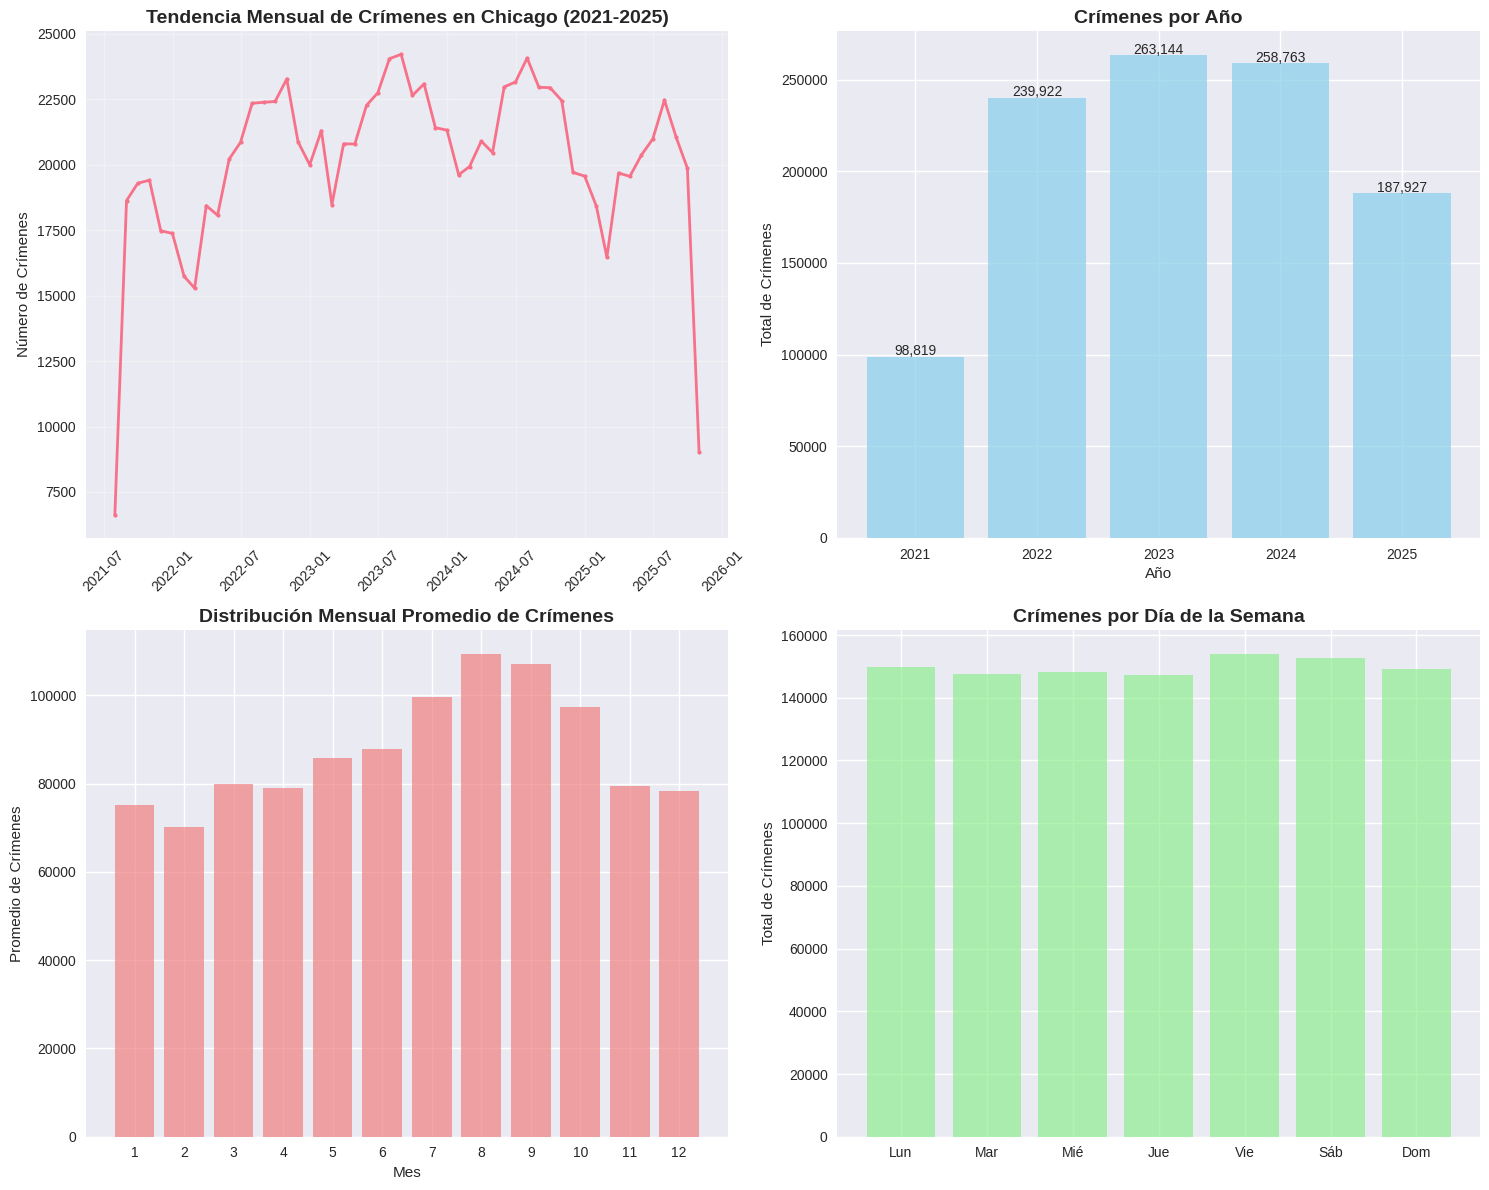


=== ANÁLISIS POR TIPO DE CRIMEN ===
Top 10 tipos de crimen:
  THEFT: 237,796
  BATTERY: 184,400
  CRIMINAL DAMAGE: 118,353
  ASSAULT: 94,006
  MOTOR VEHICLE THEFT: 91,319
  DECEPTIVE PRACTICE: 68,779
  OTHER OFFENSE: 66,734
  ROBBERY: 38,100
  BURGLARY: 34,573
  WEAPONS VIOLATION: 33,761


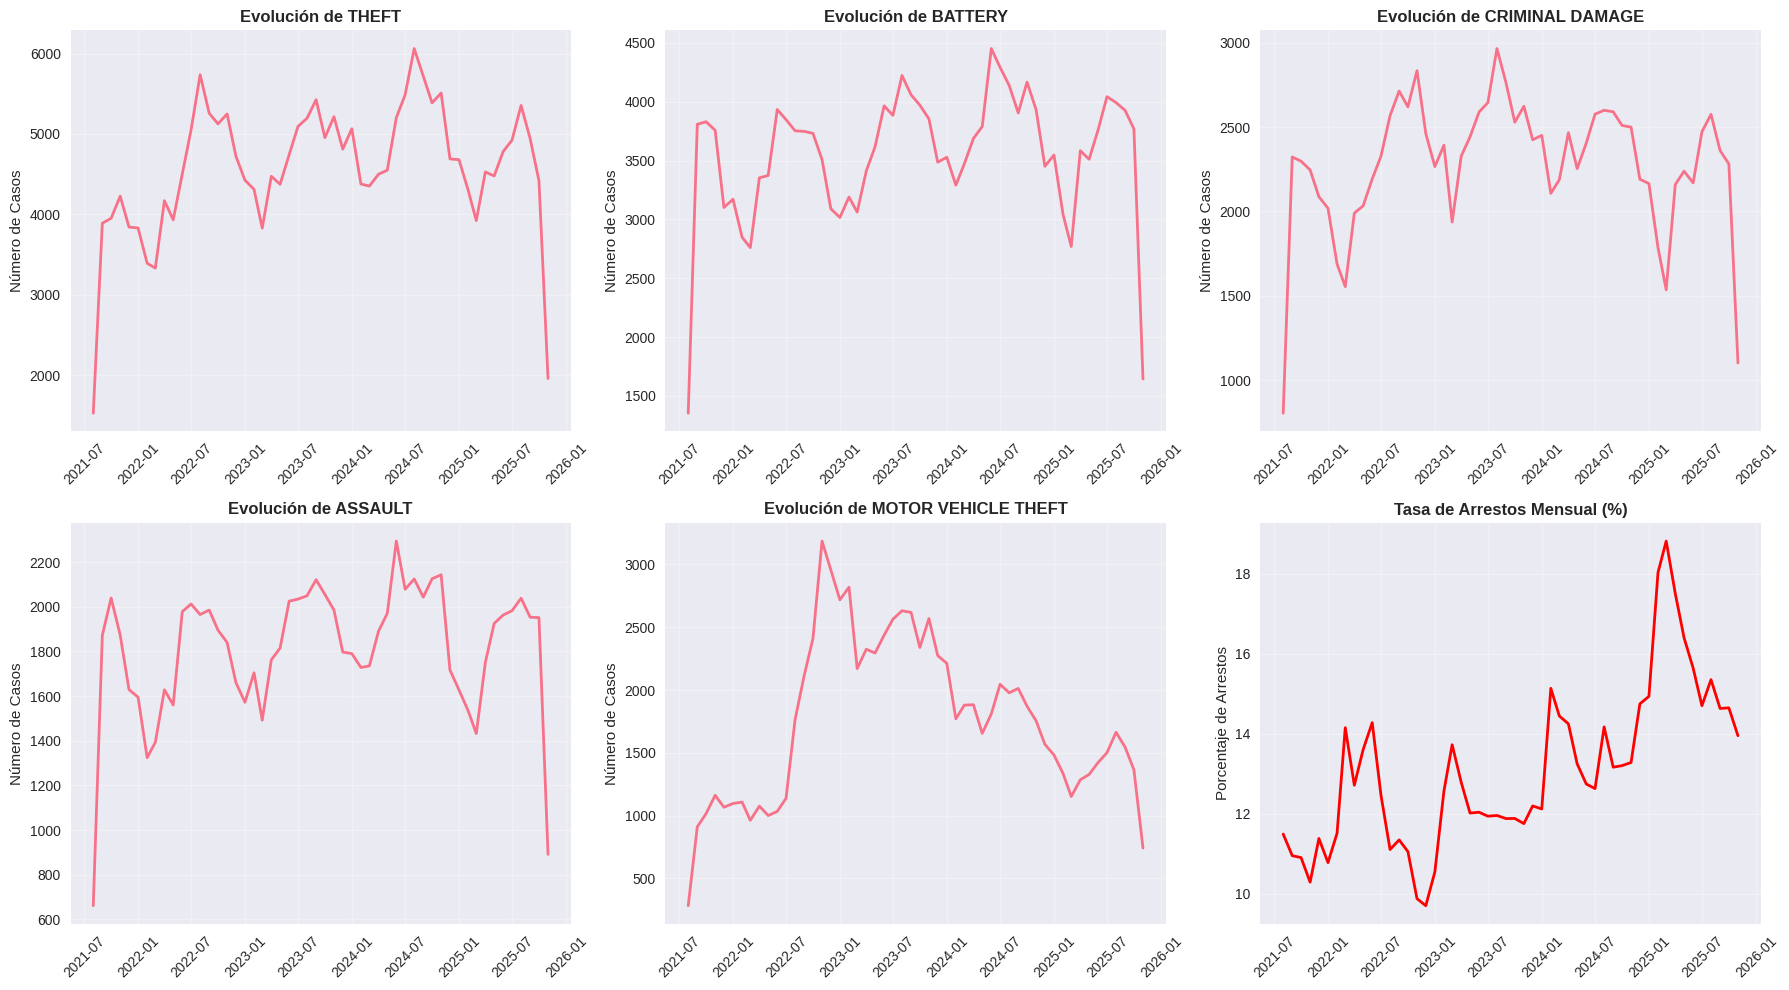


=== ANÁLISIS DE ESTACIONALIDAD ===


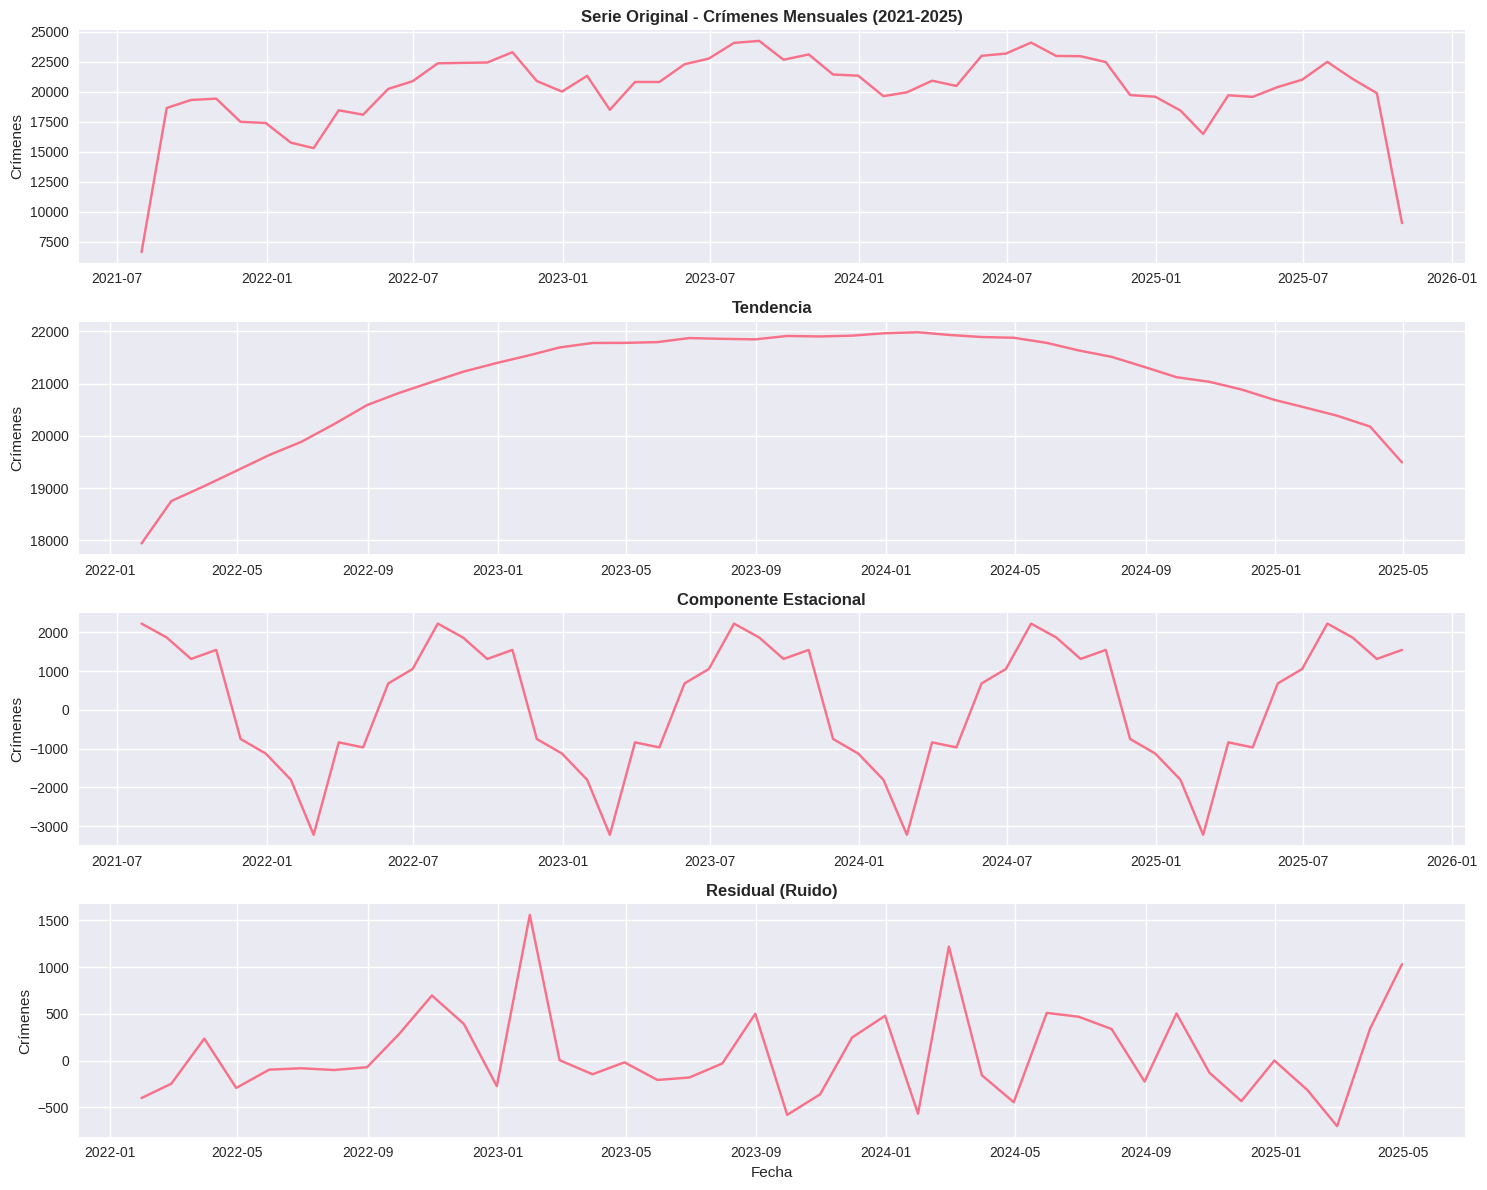


=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===
Distritos con mayor criminalidad:
  Distrito 8: 67,319 crímenes
  Distrito 12: 63,942 crímenes
  Distrito 6: 62,363 crímenes
  Distrito 4: 58,873 crímenes
  Distrito 1: 58,320 crímenes


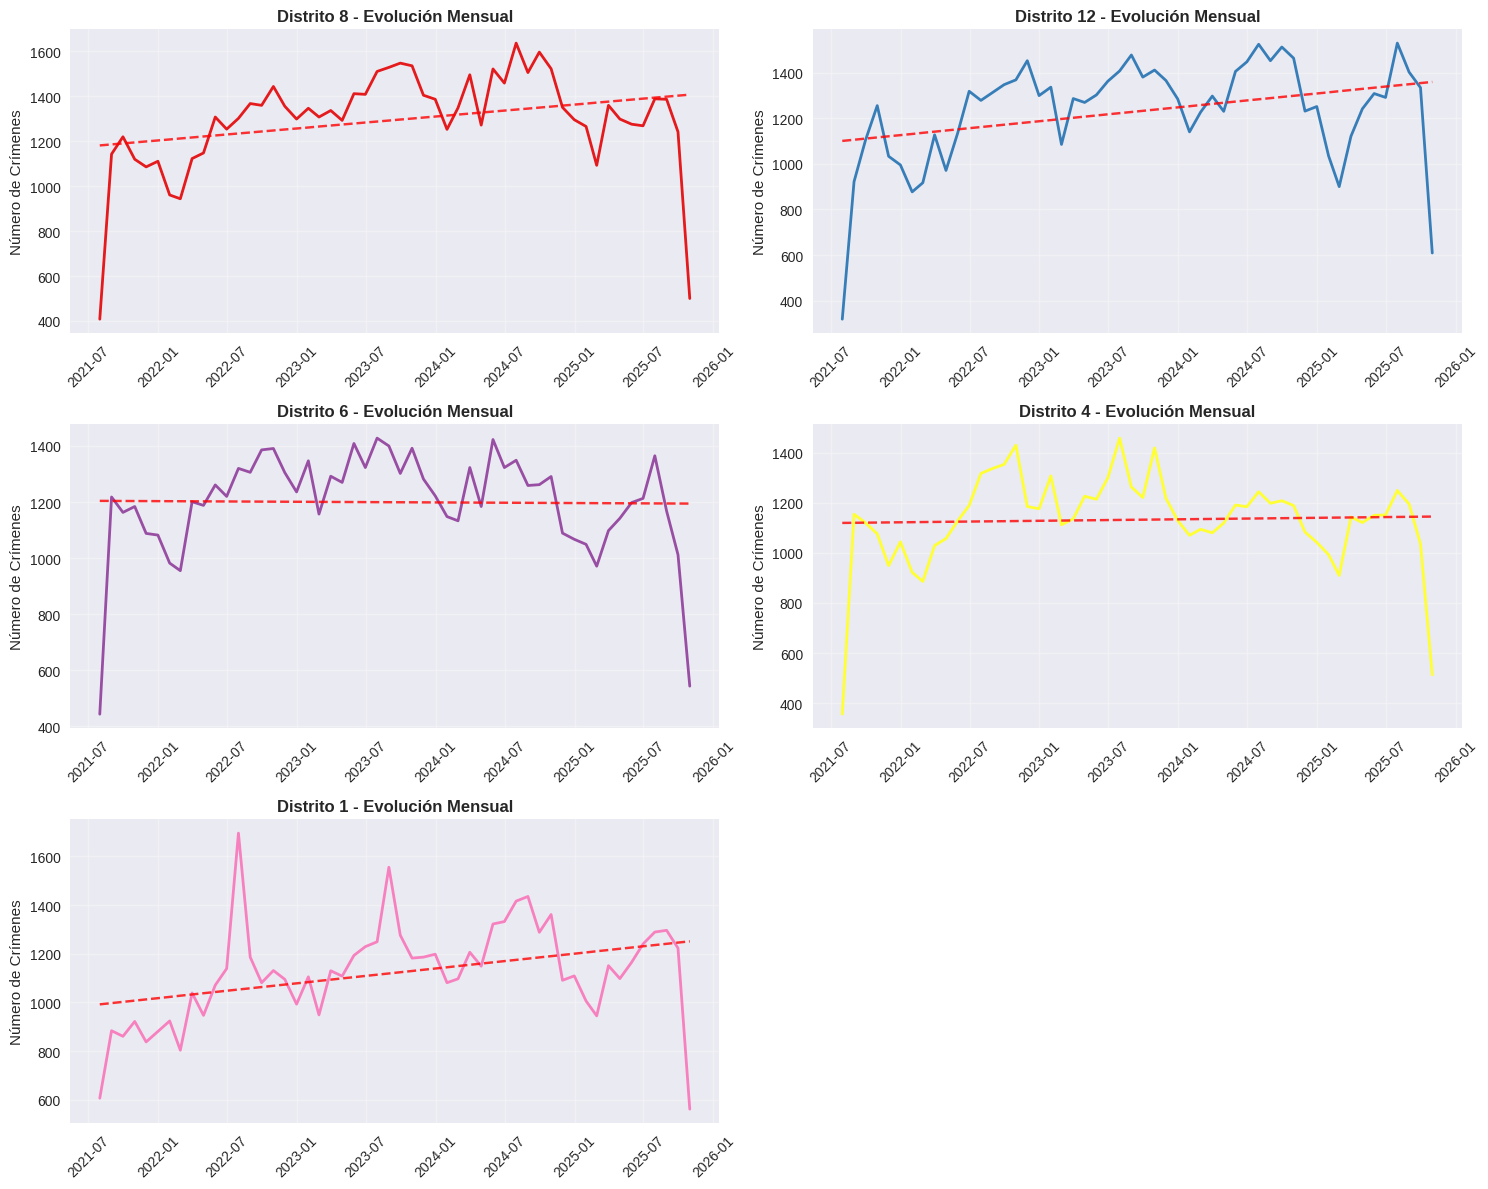

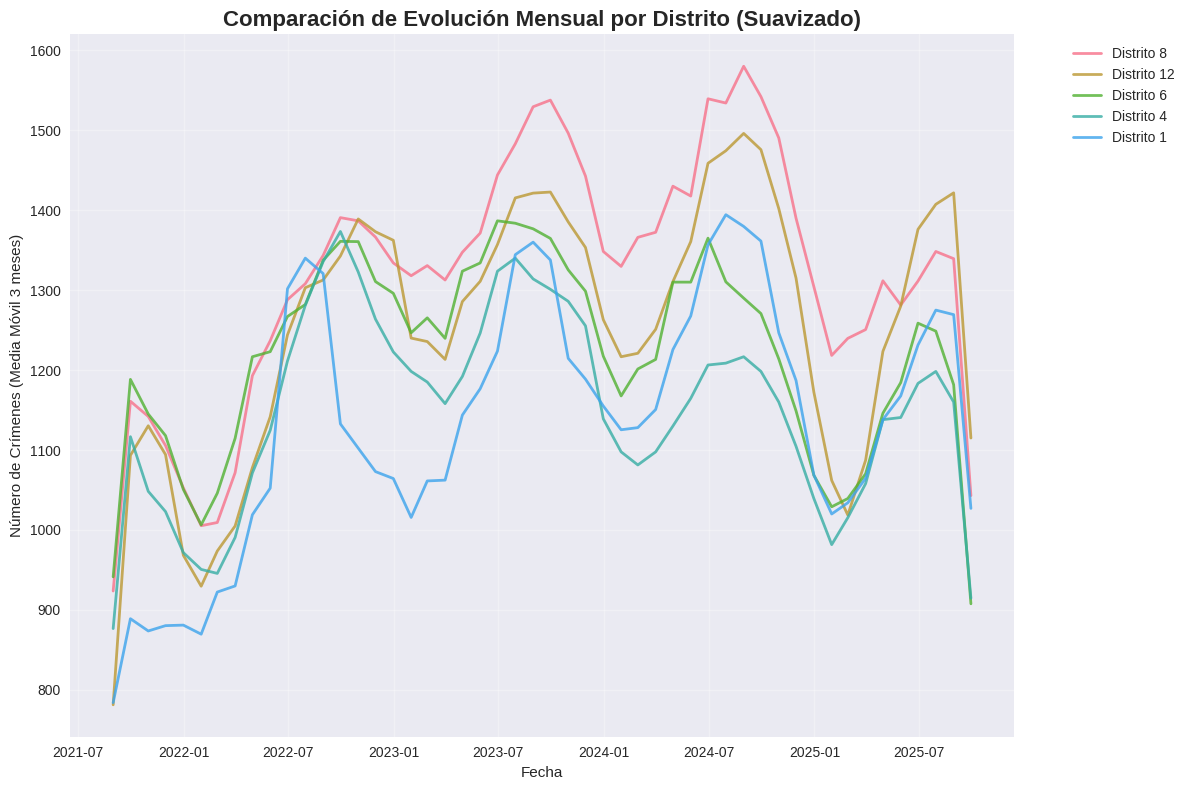


CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR

TENDENCIA POR DISTRITO (2021-2025):
  Distrito 8: ↑ AUMENTO (+98.4%)
  Distrito 12: ↑ AUMENTO (+109.2%)
  Distrito 6: ↑ AUMENTO (+74.2%)
  Distrito 4: ↑ AUMENTO (+83.6%)
  Distrito 1: ↑ AUMENTO (+119.8%)

=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===


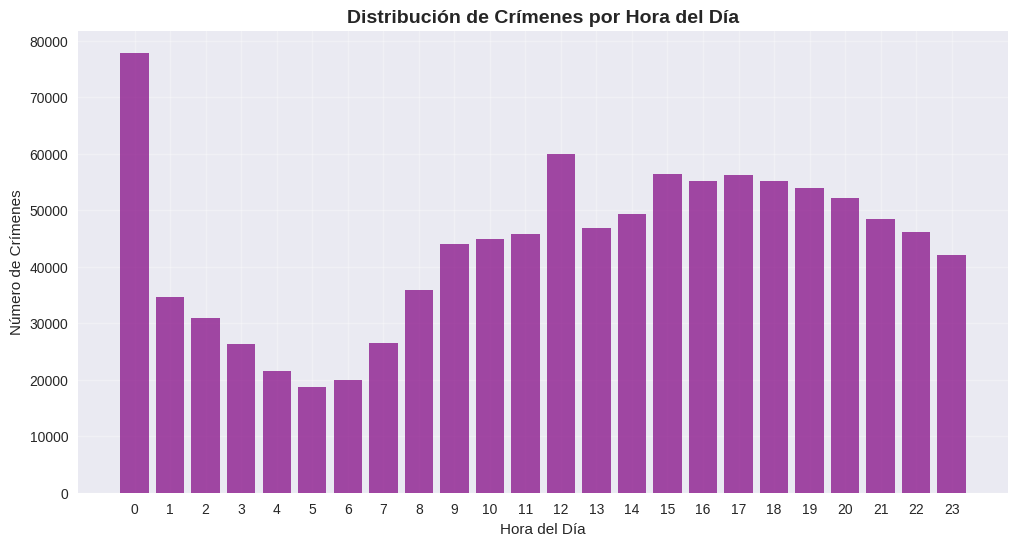


=== MODELADO DE TENDENCIAS ===

Tasas de crecimiento anual:
  2022: +142.8%
  2023: +9.7%
  2024: -1.7%
  2025: -27.4%

CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR

RESUMEN EJECUTIVO:
• Período analizado: 2021-07 a 2025-10
• Total de incidentes: 1,048,575
• Tendencia general: BAJISTA
• Distritos críticos: 8, 12, 6, 4, 1
• Tipos de crimen predominantes: THEFT, BATTERY, CRIMINAL DAMAGE, ASSAULT, MOTOR VEHICLE THEFT

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en 8 y valles en 2
2. Estacionalidad Semanal: Los días Vie muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos 8 y 12 durante 8
2. Programas preventivos enfocados en THEFT y BATTERY
3. Patrullaje intensivo los Vie
4. Monitoreo continuo de las tendencias identificadas



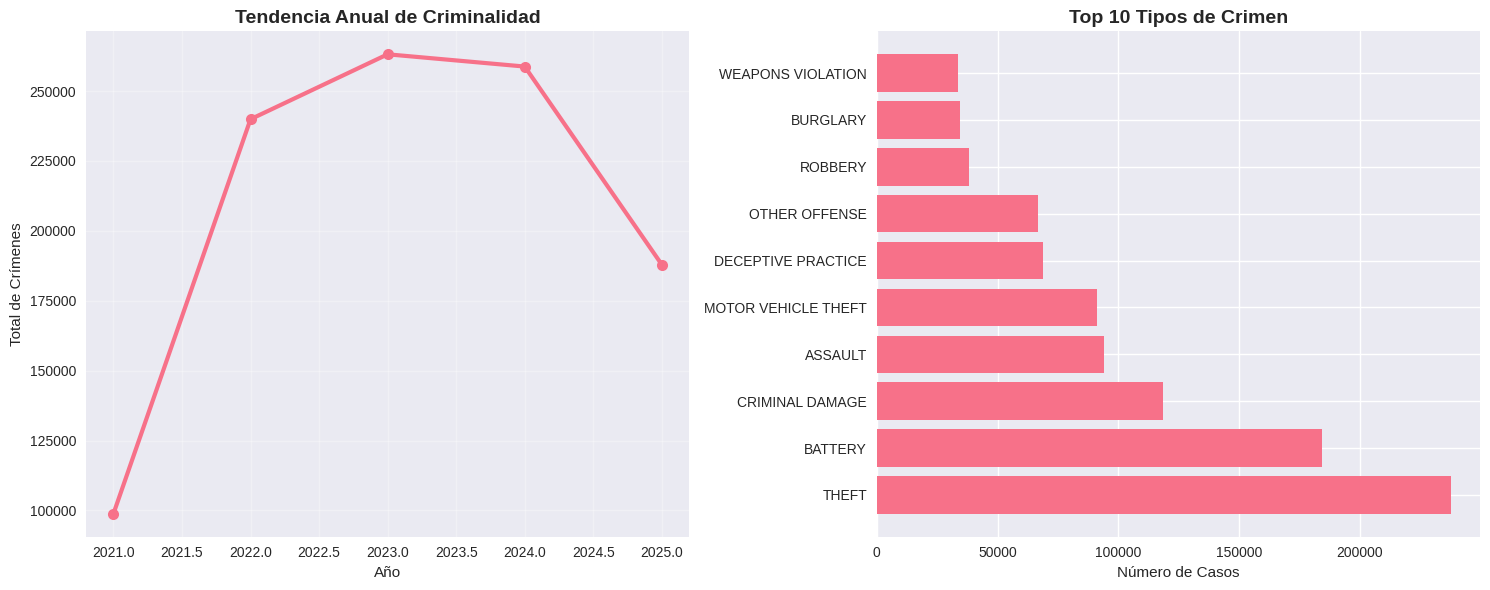

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv('Crimes.csv')

# Convertir la columna Date a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Eliminar filas con fechas inválidas
df = df.dropna(subset=['Date'])

# Filtrar datos solo hasta 2025
df = df[df['Date'].dt.year <= 2025]

# Ordenar por fecha
df = df.sort_values('Date')

# 1. ANÁLISIS EXPLORATORIO TEMPORAL
print("=== ANÁLISIS EXPLORATORIO TEMPORAL ===")

# Crear series temporales por diferentes periodos
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Series temporal mensual (solo hasta 2025)
monthly_crimes = df.resample('M', on='Date').size()
# Filtrar solo hasta diciembre 2025
monthly_crimes = monthly_crimes[monthly_crimes.index.year <= 2025]

daily_crimes = df.resample('D', on='Date').size()

print(f"Período de datos: {df['Date'].min()} a {df['Date'].max()}")
print(f"Total de crímenes: {len(df):,}")
print(f"Promedio diario: {daily_crimes.mean():.0f} crímenes")

# 2. VISUALIZACIONES TEMPORALES
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Tendencia mensual CON INTERACTIVIDAD
ax1 = axes[0,0]
line1 = ax1.plot(monthly_crimes.index, monthly_crimes.values, linewidth=2, marker='o', markersize=3)[0]
ax1.set_title('Tendencia Mensual de Crímenes en Chicago (2021-2025)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Crímenes')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Añadir anotaciones interactivas
annot1 = ax1.annotate("", xy=(0,0), xytext=(20,20), textcoords="offset points",
                     bbox=dict(boxstyle="round", fc="w"),
                     arrowprops=dict(arrowstyle="->"))
annot1.set_visible(False)

def update_annot1(ind):
    x, y = line1.get_data()
    annot1.xy = (x[ind["ind"][0]], y[ind["ind"][0]])
    text = f"Fecha: {x[ind['ind'][0]].strftime('%b %Y')}\nCrímenes: {y[ind['ind'][0]]:,.0f}"
    annot1.set_text(text)

def hover1(event):
    vis = annot1.get_visible()
    if event.inaxes == ax1:
        cont, ind = line1.contains(event)
        if cont:
            update_annot1(ind)
            annot1.set_visible(True)
            fig.canvas.draw_idle()
        else:
            if vis:
                annot1.set_visible(False)
                fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", hover1)

# Crímenes por año
yearly_counts = df['Year'].value_counts().sort_index()
axes[0,1].bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.7)
axes[0,1].set_title('Crímenes por Año', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Año')
axes[0,1].set_ylabel('Total de Crímenes')
for i, v in enumerate(yearly_counts.values):
    axes[0,1].text(yearly_counts.index[i], v + 1000, f'{v:,}', ha='center')

# Crímenes por mes (promedio)
monthly_avg = df.groupby('Month').size()
axes[1,0].bar(monthly_avg.index, monthly_avg.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Distribución Mensual Promedio de Crímenes', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Promedio de Crímenes')
axes[1,0].set_xticks(range(1, 13))

# Crímenes por día de la semana
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
axes[1,1].bar(dow_names, dow_counts.values, color='lightgreen', alpha=0.7)
axes[1,1].set_title('Crímenes por Día de la Semana', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Total de Crímenes')

plt.tight_layout()
plt.show()

# 3. ANÁLISIS POR TIPO DE CRIMEN A TRAVÉS DEL TIEMPO
print("\n=== ANÁLISIS POR TIPO DE CRIMEN ===")

# Top 10 tipos de crimen
top_crimes = df['Primary Type'].value_counts().head(10)
print("Top 10 tipos de crimen:")
for crime, count in top_crimes.items():
    print(f"  {crime}: {count:,}")

# Evolución de los principales tipos de crimen (solo hasta 2025)
top_5_crimes = top_crimes.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime_type in enumerate(top_5_crimes):
    crime_ts = df[df['Primary Type'] == crime_type].resample('M', on='Date').size()
    crime_ts = crime_ts[crime_ts.index.year <= 2025]  # Filtrar hasta 2025

    line = axes[i].plot(crime_ts.index, crime_ts.values, linewidth=2)[0]
    axes[i].set_title(f'Evolución de {crime_type}', fontweight='bold')
    axes[i].set_ylabel('Número de Casos')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

    # Añadir interactividad
    annot = axes[i].annotate("", xy=(0,0), xytext=(20,20), textcoords="offset points",
                           bbox=dict(boxstyle="round", fc="w"),
                           arrowprops=dict(arrowstyle="->"))
    annot.set_visible(False)

    def make_update_annot(ax, line, annot):
        def update_annot(ind):
            x, y = line.get_data()
            annot.xy = (x[ind["ind"][0]], y[ind["ind"][0]])
            text = f"Fecha: {x[ind['ind'][0]].strftime('%b %Y')}\nCasos: {y[ind['ind'][0]]:,.0f}"
            annot.set_text(text)
        return update_annot

    def make_hover(ax, line, annot, update_func):
        def hover(event):
            vis = annot.get_visible()
            if event.inaxes == ax:
                cont, ind = line.contains(event)
                if cont:
                    update_func(ind)
                    annot.set_visible(True)
                    fig.canvas.draw_idle()
                else:
                    if vis:
                        annot.set_visible(False)
                        fig.canvas.draw_idle()
        return hover

    update_func = make_update_annot(axes[i], line, annot)
    fig.canvas.mpl_connect("motion_notify_event", make_hover(axes[i], line, annot, update_func))

# Tendencia de arrestos (solo hasta 2025)
arrest_ts = df.resample('M', on='Date')['Arrest'].mean() * 100
arrest_ts = arrest_ts[arrest_ts.index.year <= 2025]  # Filtrar hasta 2025

line_arrest = axes[5].plot(arrest_ts.index, arrest_ts.values, linewidth=2, color='red')[0]
axes[5].set_title('Tasa de Arrestos Mensual (%)', fontweight='bold')
axes[5].set_ylabel('Porcentaje de Arrestos')
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis='x', rotation=45)

# Interactividad para tasa de arrestos
annot_arrest = axes[5].annotate("", xy=(0,0), xytext=(20,20), textcoords="offset points",
                              bbox=dict(boxstyle="round", fc="w"),
                              arrowprops=dict(arrowstyle="->"))
annot_arrest.set_visible(False)

def update_annot_arrest(ind):
    x, y = line_arrest.get_data()
    annot_arrest.xy = (x[ind["ind"][0]], y[ind["ind"][0]])
    text = f"Fecha: {x[ind['ind'][0]].strftime('%b %Y')}\nTasa: {y[ind['ind'][0]]:.1f}%"
    annot_arrest.set_text(text)

def hover_arrest(event):
    vis = annot_arrest.get_visible()
    if event.inaxes == axes[5]:
        cont, ind = line_arrest.contains(event)
        if cont:
            update_annot_arrest(ind)
            annot_arrest.set_visible(True)
            fig.canvas.draw_idle()
        else:
            if vis:
                annot_arrest.set_visible(False)
                fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", hover_arrest)

plt.tight_layout()
plt.show()

# 4. ANÁLISIS DE ESTACIONALIDAD (solo hasta 2025)
print("\n=== ANÁLISIS DE ESTACIONALIDAD ===")

# Descomposición estacional de la serie temporal mensual (solo hasta 2025)
monthly_series = monthly_crimes.astype(float)

# Completar valores faltantes si los hay
if monthly_series.isnull().any():
    monthly_series = monthly_series.interpolate()

# Asegurarse de que tenemos datos suficientes para la descomposición
if len(monthly_series) >= 24:  # Mínimo 2 años para descomposición estacional
    try:
        # Descomposición estacional
        decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

        fig, axes = plt.subplots(4, 1, figsize=(15, 12))

        # Serie original
        axes[0].plot(decomposition.observed)
        axes[0].set_title('Serie Original - Crímenes Mensuales (2021-2025)', fontweight='bold')
        axes[0].set_ylabel('Crímenes')

        # Tendencia
        axes[1].plot(decomposition.trend)
        axes[1].set_title('Tendencia', fontweight='bold')
        axes[1].set_ylabel('Crímenes')

        # Estacionalidad
        axes[2].plot(decomposition.seasonal)
        axes[2].set_title('Componente Estacional', fontweight='bold')
        axes[2].set_ylabel('Crímenes')

        # Residual
        axes[3].plot(decomposition.resid)
        axes[3].set_title('Residual (Ruido)', fontweight='bold')
        axes[3].set_ylabel('Crímenes')
        axes[3].set_xlabel('Fecha')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error en descomposición estacional: {e}")
else:
    print("Datos insuficientes para descomposición estacional")

# 5. ANÁLISIS DE ZONAS ESTRATÉGICAS POR DISTRITO - GRÁFICAS SEPARADAS
print("\n=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===")

# Identificar distritos con mayor criminalidad
district_crimes = df['District'].value_counts().head(5)
print("Distritos con mayor criminalidad:")
for district, count in district_crimes.items():
    print(f"  Distrito {district}: {count:,} crímenes")

# Evolución temporal por distrito - GRÁFICAS SEPARADAS
top_districts = district_crimes.index.tolist()

# Crear una figura con subgráficas para cada distrito
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, district in enumerate(top_districts):
    district_ts = df[df['District'] == district].resample('M', on='Date').size()
    district_ts = district_ts[district_ts.index.year <= 2025]  # Filtrar hasta 2025

    axes[i].plot(district_ts.index, district_ts.values, linewidth=2,
                color=plt.cm.Set1(i/len(top_districts)))
    axes[i].set_title(f'Distrito {district} - Evolución Mensual', fontweight='bold')
    axes[i].set_ylabel('Número de Crímenes')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

    # Añadir línea de tendencia
    if len(district_ts) > 1:
        z = np.polyfit(range(len(district_ts)), district_ts.values, 1)
        p = np.poly1d(z)
        axes[i].plot(district_ts.index, p(range(len(district_ts))), "r--", alpha=0.8,
                    label=f'Tendencia: {"↑" if z[0] > 0 else "↓"}')

# Ocultar el último subplot si no se usa
if len(top_districts) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# 6. GRÁFICA COMPARATIVA MEJORADA
plt.figure(figsize=(12, 8))
for i, district in enumerate(top_districts):
    district_ts = df[df['District'] == district].resample('M', on='Date').size()
    district_ts = district_ts[district_ts.index.year <= 2025]

    # Suavizar la línea con media móvil
    if len(district_ts) > 3:
        district_smooth = district_ts.rolling(window=3, center=True).mean()
        plt.plot(district_smooth.index, district_smooth.values,
                label=f'Distrito {district}', linewidth=2, alpha=0.8)
    else:
        plt.plot(district_ts.index, district_ts.values,
                label=f'Distrito {district}', linewidth=2, alpha=0.8)

plt.title('Comparación de Evolución Mensual por Distrito (Suavizado)',
          fontsize=16, fontweight='bold')
plt.ylabel('Número de Crímenes (Media Móvil 3 meses)')
plt.xlabel('Fecha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. RESUMEN EJECUTIVO MEJORADO
print("\n" + "="*60)
print("CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR")
print("="*60)

# Calcular tasas de crecimiento por distrito
print("\nTENDENCIA POR DISTRITO (2021-2025):")
for district in top_districts:
    district_data = df[df['District'] == district].resample('Y', on='Date').size()
    if len(district_data) > 1:
        growth = (district_data.iloc[-1] - district_data.iloc[0]) / district_data.iloc[0] * 100
        trend = "↑ AUMENTO" if growth > 0 else "↓ DISMINUCIÓN" if growth < 0 else "→ ESTABLE"
        print(f"  Distrito {district}: {trend} ({growth:+.1f}%)")


# 8. ANÁLISIS DE PATRONES DIARIOS Y HORARIOS
print("\n=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===")

# Extraer hora del día (si está disponible en los datos)
try:
    df['Hour'] = df['Date'].dt.hour
    hourly_pattern = df['Hour'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(hourly_pattern.index, hourly_pattern.values, color='purple', alpha=0.7)
    plt.title('Distribución de Crímenes por Hora del Día', fontsize=14, fontweight='bold')
    plt.xlabel('Hora del Día')
    plt.ylabel('Número de Crímenes')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.show()
except:
    print("Información de hora no disponible en los datos")

# 9. MODELADO DE TENDENCIAS
print("\n=== MODELADO DE TENDENCIAS ===")

# Calcular tasas de crecimiento anual
yearly_growth = yearly_counts.pct_change() * 100
print("\nTasas de crecimiento anual:")
for year, growth in yearly_growth.items():
    if not pd.isna(growth):
        print(f"  {year}: {growth:+.1f}%")

# 10. PRONÓSTICO SIMPLE Y RECOMENDACIONES
print("\n" + "="*50)
print("CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR")
print("="*50)

# Resumen ejecutivo
print(f"""
RESUMEN EJECUTIVO:
• Período analizado: {df['Date'].min().strftime('%Y-%m')} a {df['Date'].max().strftime('%Y-%m')}
• Total de incidentes: {len(df):,}
• Tendencia general: {'ALCISTA' if yearly_growth.iloc[-1] > 0 else 'BAJISTA' if yearly_growth.iloc[-1] < 0 else 'ESTABLE'}
• Distritos críticos: {', '.join(map(str, top_districts))}
• Tipos de crimen predominantes: {', '.join(top_5_crimes)}

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en {monthly_avg.idxmax()} y valles en {monthly_avg.idxmin()}
2. Estacionalidad Semanal: Los días {dow_names[dow_counts.idxmax()]} muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos {top_districts[0]} y {top_districts[1]} durante {monthly_avg.idxmax()}
2. Programas preventivos enfocados en {top_5_crimes[0]} y {top_5_crimes[1]}
3. Patrullaje intensivo los {dow_names[dow_counts.idxmax()]}
4. Monitoreo continuo de las tendencias identificadas
""")

# Visualización final resumen
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Resumen anual con tendencia
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=3, markersize=8)
axes[0].set_title('Tendencia Anual de Criminalidad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Total de Crímenes')
axes[0].grid(True, alpha=0.3)

# Distribución por tipo de crimen (top 10)
axes[1].barh(range(len(top_crimes)), top_crimes.values)
axes[1].set_yticks(range(len(top_crimes)))
axes[1].set_yticklabels(top_crimes.index)
axes[1].set_title('Top 10 Tipos de Crimen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Casos')

plt.tight_layout()
plt.show()

## Fourth Version

=== ANÁLISIS EXPLORATORIO TEMPORAL ===
Período de datos: 2021-07 a 2025-07
Total de crímenes: 997,901


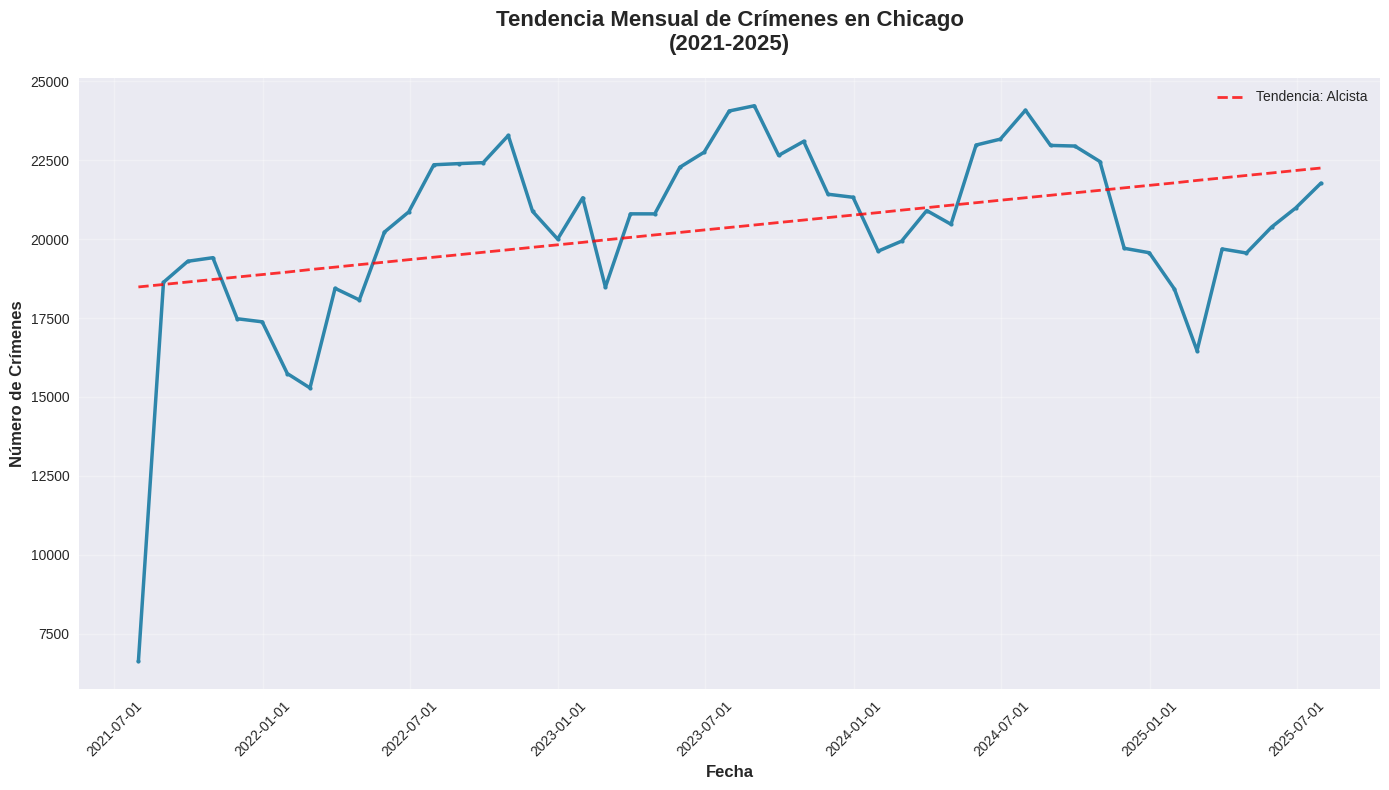


=== ANÁLISIS POR TIPO DE CRIMEN ===


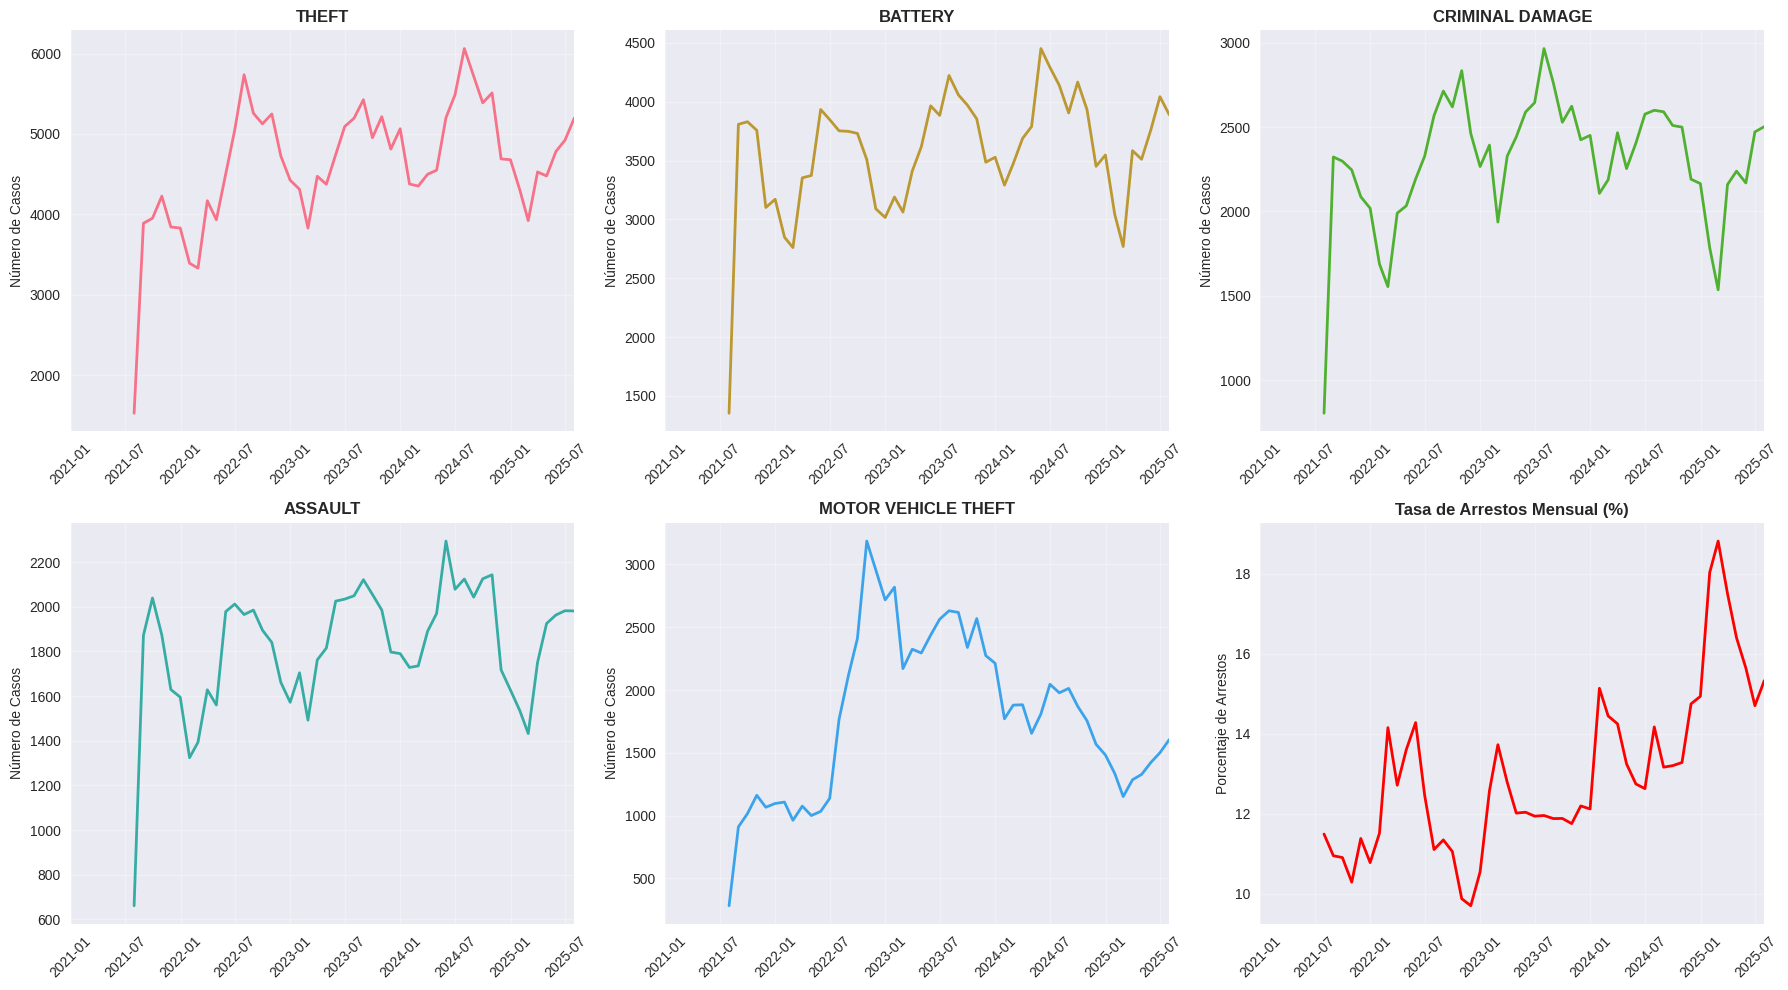


=== ANÁLISIS DE ESTACIONALIDAD ===


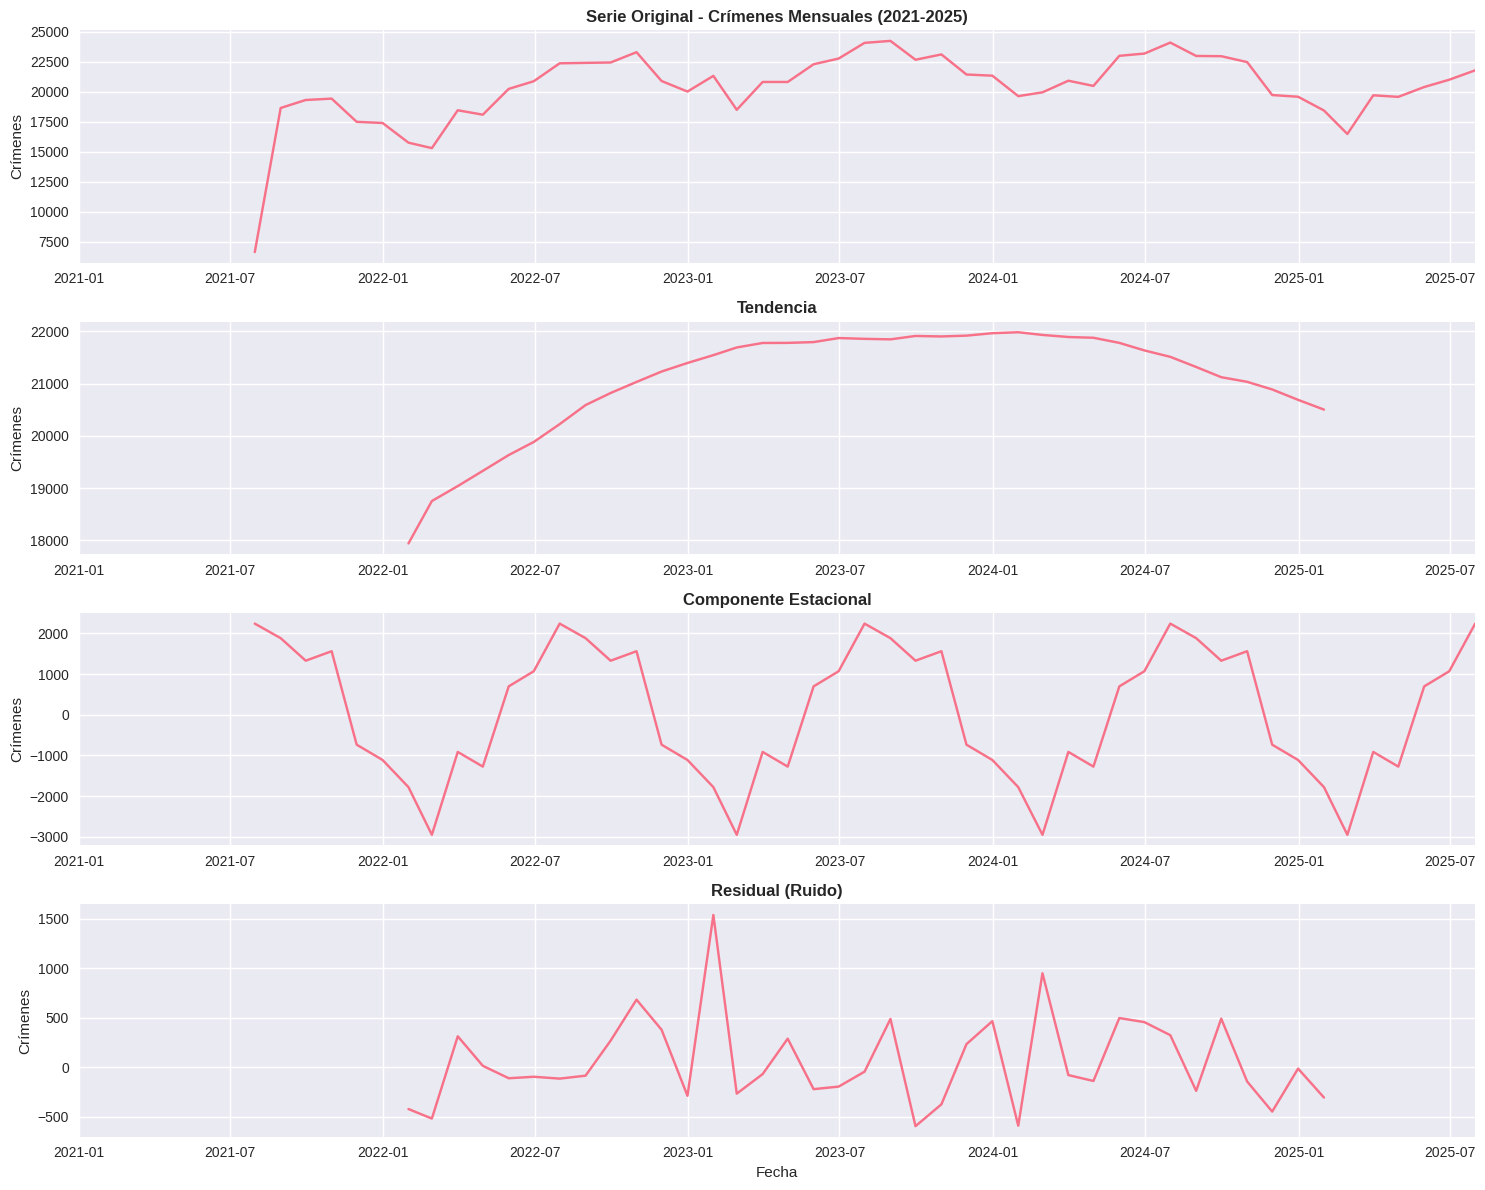


=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===
Distritos con mayor criminalidad:
  Distrito 8: 64,150 crímenes
  Distrito 12: 60,555 crímenes
  Distrito 6: 59,601 crímenes
  Distrito 4: 56,078 crímenes
  Distrito 1: 55,182 crímenes


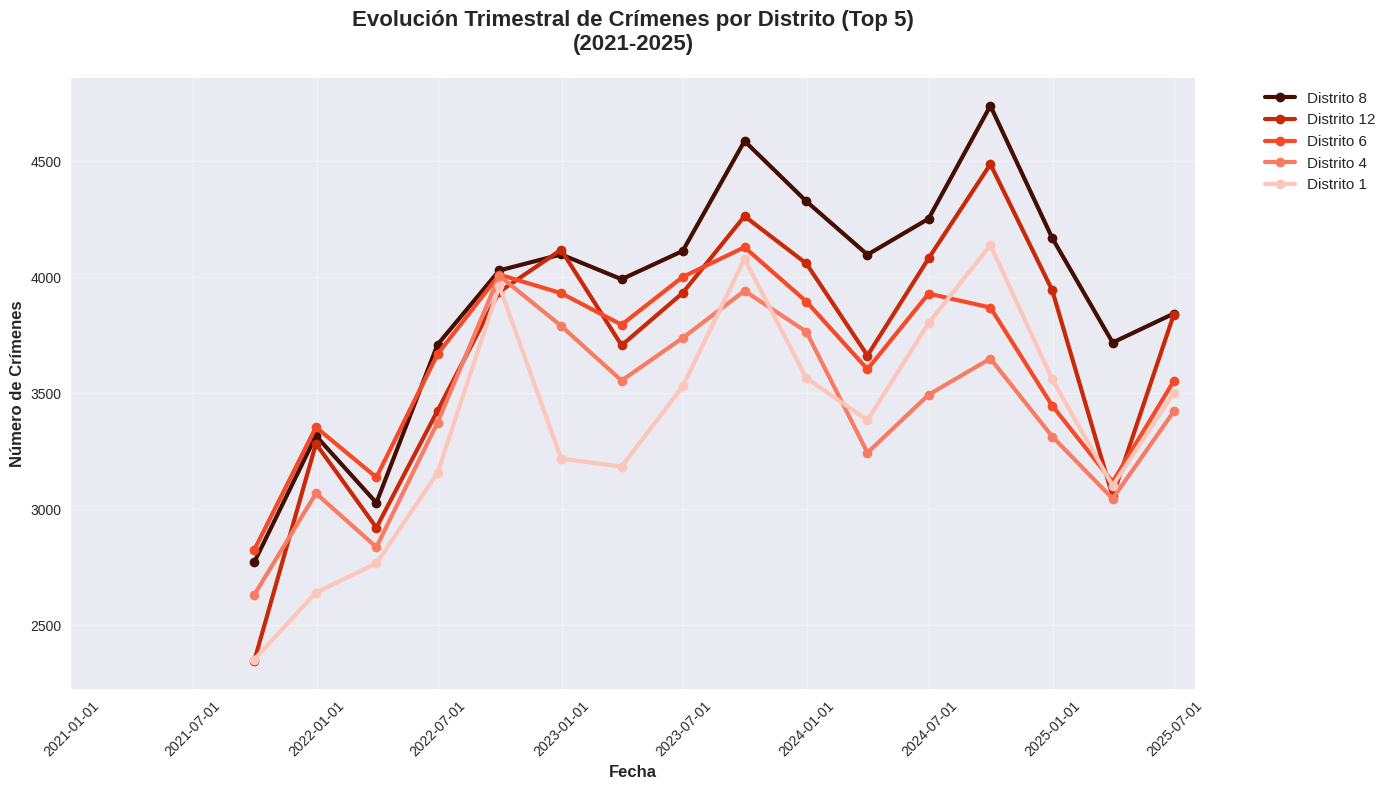

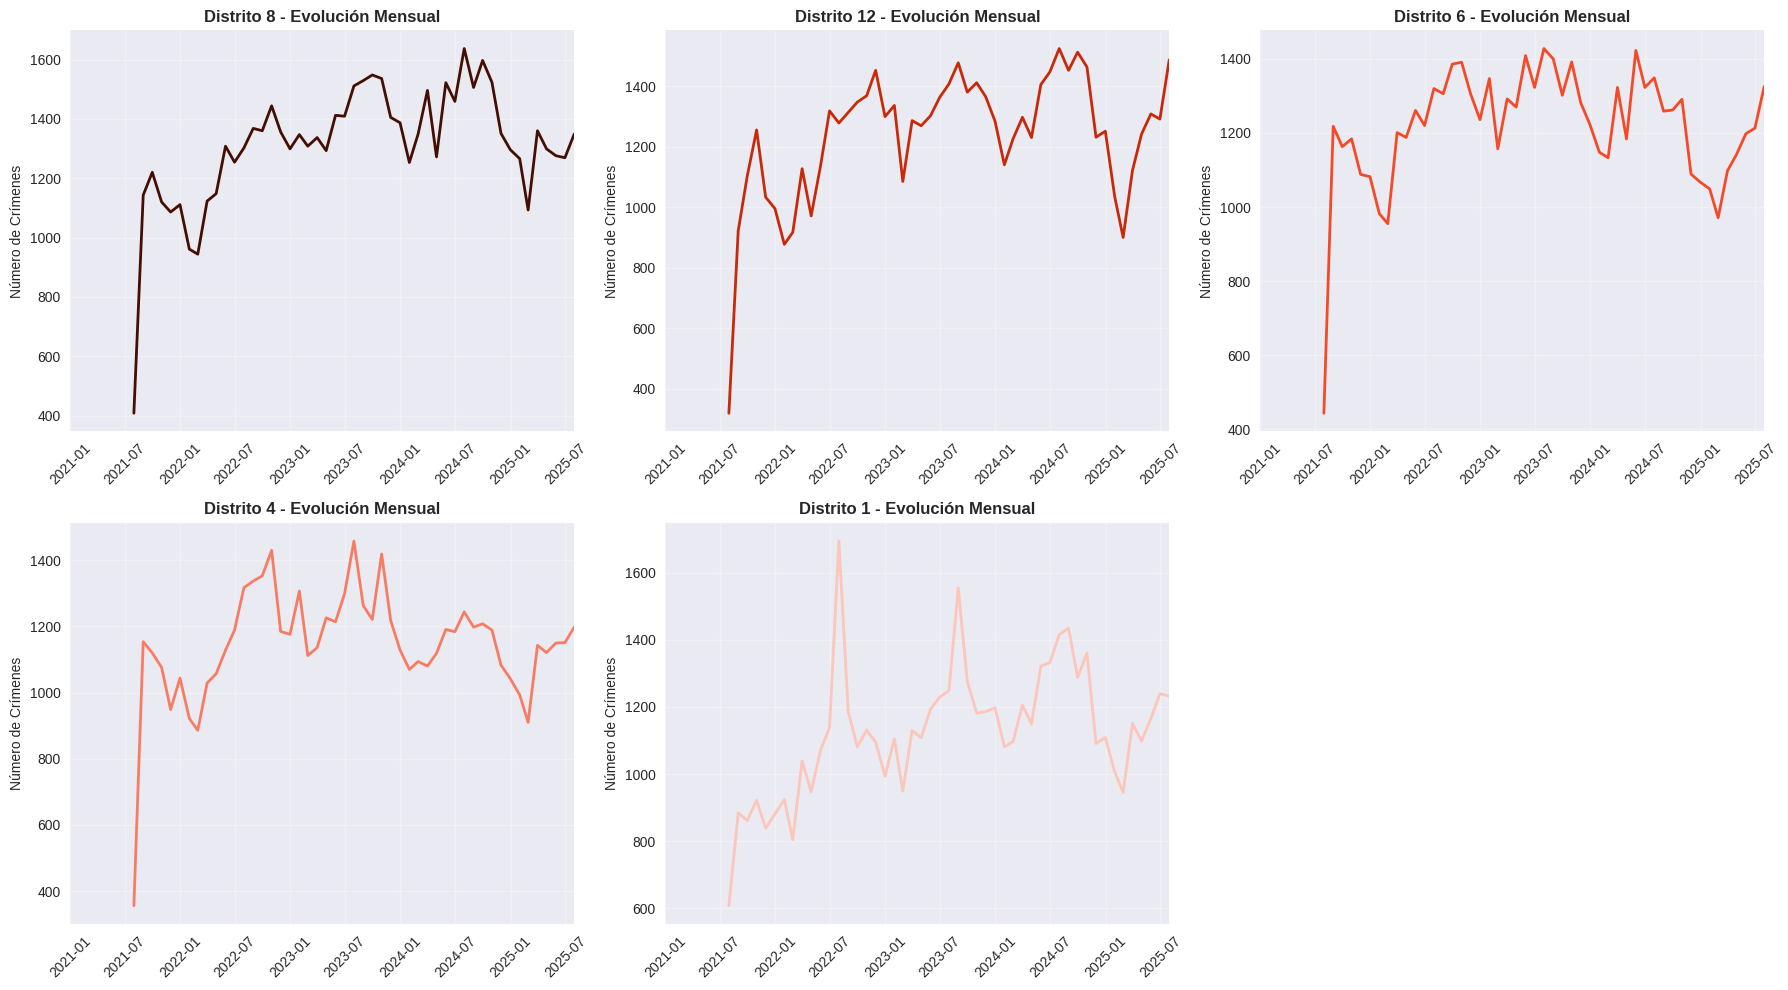

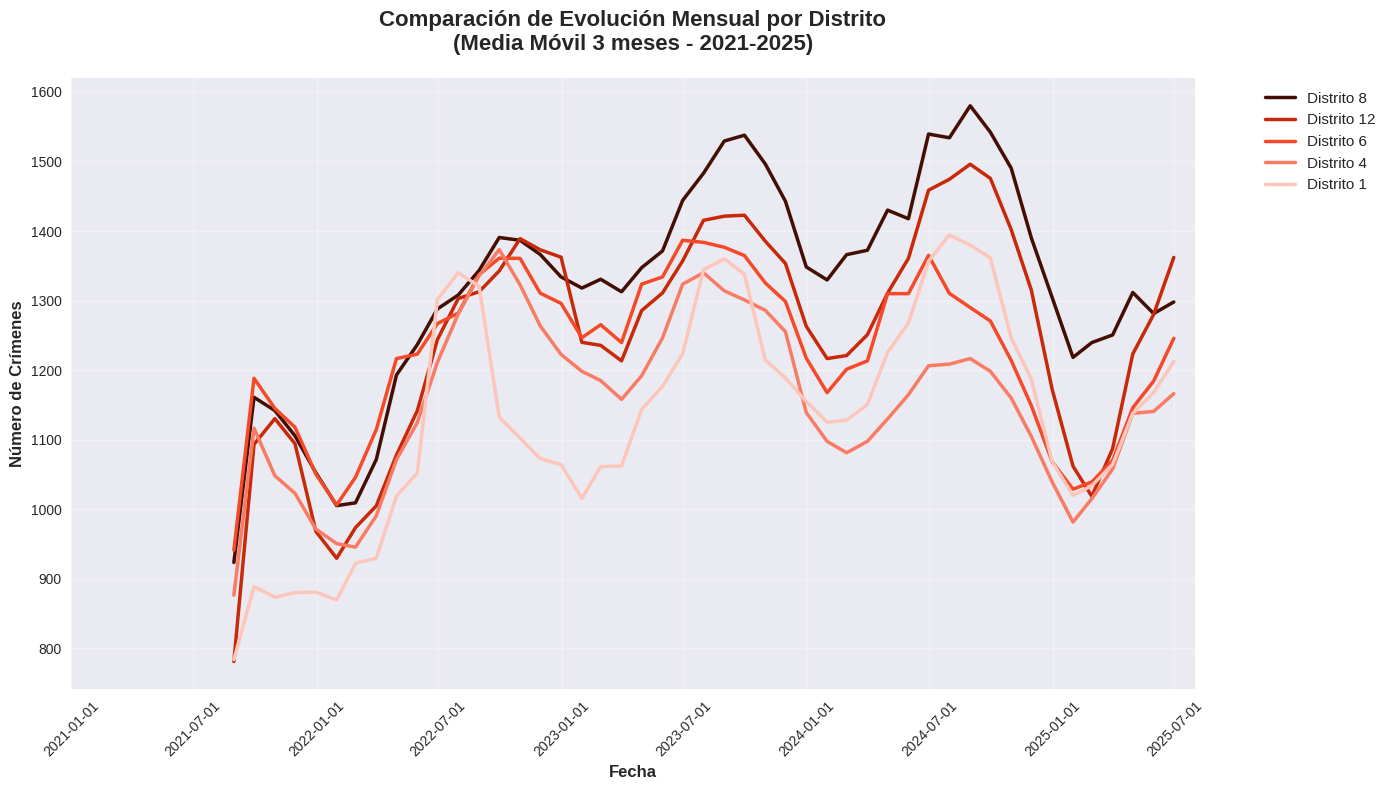


CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR

TENDENCIA POR DISTRITO (2021-2025):
  Distrito 8: ↑ AUMENTO (+46.4%)
  Distrito 12: ↑ AUMENTO (+49.0%)
  Distrito 6: ↑ AUMENTO (+29.4%)
  Distrito 4: ↑ AUMENTO (+34.5%)
  Distrito 1: ↑ AUMENTO (+57.0%)

=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===


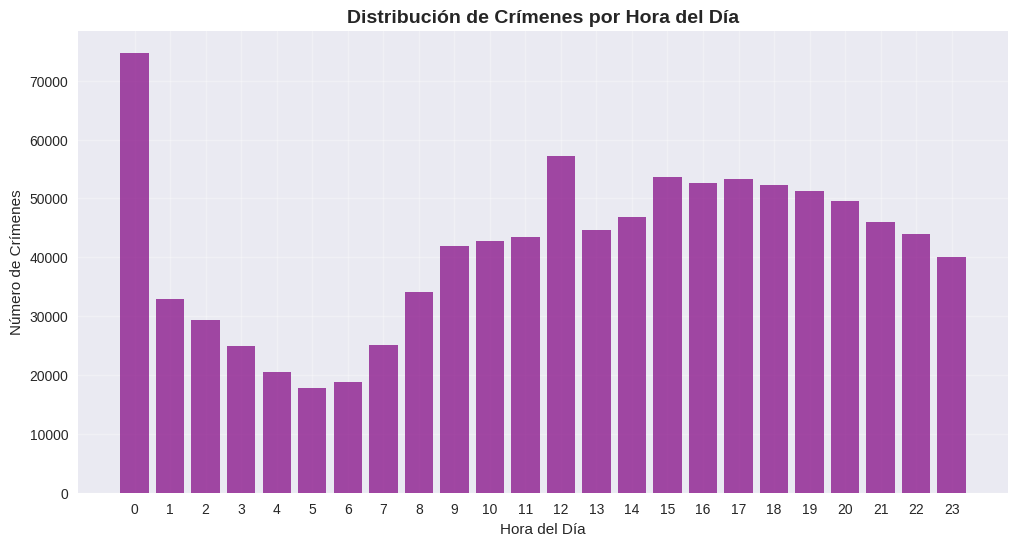


=== MODELADO DE TENDENCIAS ===

Tasas de crecimiento anual:
  2022: +142.8%
  2023: +9.7%
  2024: -1.7%
  2025: -27.4%

CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR

RESUMEN EJECUTIVO:
• Período analizado: 2021-07 a 2025-07
• Total de incidentes: 997,901
• Tendencia general: BAJISTA
• Distritos críticos: 8, 12, 6, 4, 1
• Tipos de crimen predominantes: THEFT, BATTERY, CRIMINAL DAMAGE, ASSAULT, MOTOR VEHICLE THEFT

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en 8 y valles en 2
2. Estacionalidad Semanal: Los días Vie muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos 8 y 12 durante 8
2. Programas preventivos enfocados en THEFT y BATTERY
3. Patrullaje intensivo los Vie
4. Monitoreo continuo de las tendencias identificadas



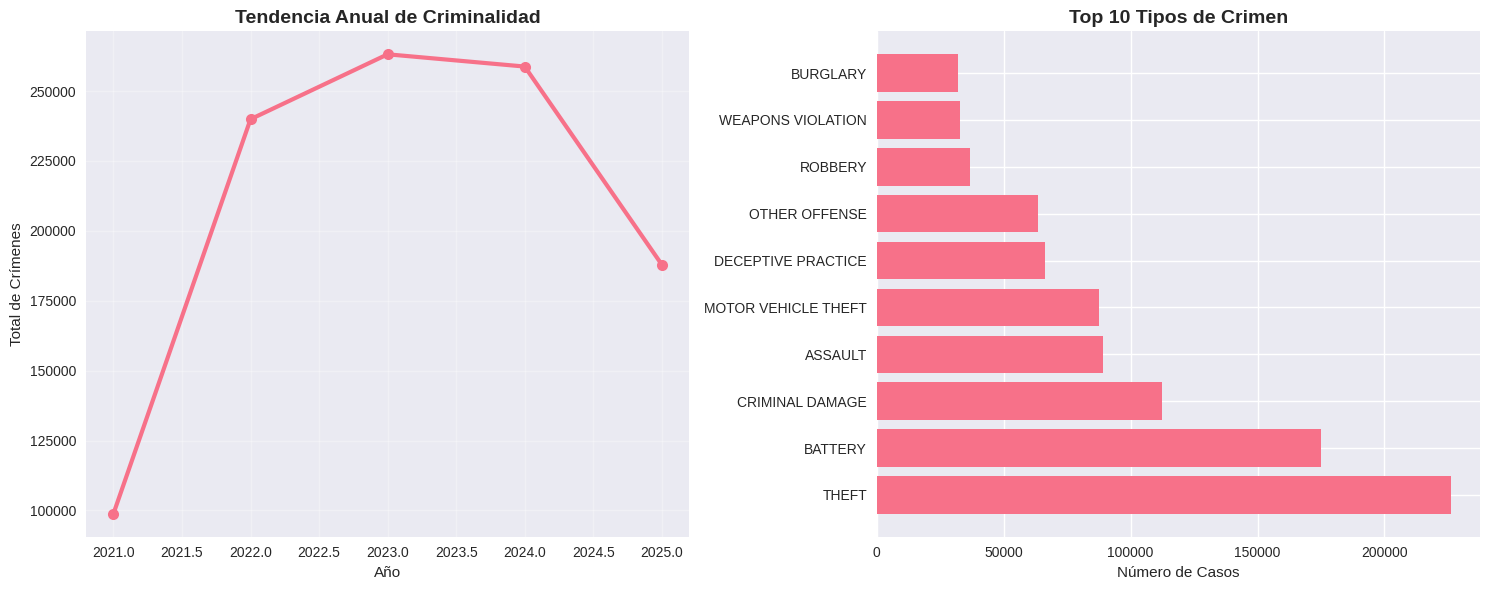

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar los datos
df = pd.read_csv('Crimes.csv')

# Convertir la columna Date a datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Eliminar filas con fechas inválidas
df = df.dropna(subset=['Date'])

# FILTRAR DATOS SOLO HASTA JULIO 2025
cutoff_date = pd.Timestamp('2025-07-31')
df = df[df['Date'] <= cutoff_date]

# Ordenar por fecha
df = df.sort_values('Date')

# 1. ANÁLISIS EXPLORATORIO TEMPORAL
print("=== ANÁLISIS EXPLORATORIO TEMPORAL ===")

# Crear series temporales por diferentes periodos
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Series temporal mensual (SOLO HASTA JULIO 2025)
monthly_crimes = df.resample('M', on='Date').size()
monthly_crimes = monthly_crimes[monthly_crimes.index <= cutoff_date]

print(f"Período de datos: {df['Date'].min().strftime('%Y-%m')} a {df['Date'].max().strftime('%Y-%m')}")
print(f"Total de crímenes: {len(df):,}")

# 2. VISUALIZACIÓN PRINCIPAL - TENDENCIA MENSUAL
plt.figure(figsize=(14, 8))
plt.plot(monthly_crimes.index, monthly_crimes.values, linewidth=2.5, color='#2E86AB', marker='o', markersize=3)
plt.title('Tendencia Mensual de Crímenes en Chicago\n(2021-2025)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Crímenes', fontsize=12, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Formatear el eje x para mostrar años completos
plt.xticks(pd.date_range(start='2021-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

# Añadir línea de tendencia
x_numeric = np.arange(len(monthly_crimes))
z = np.polyfit(x_numeric, monthly_crimes.values, 1)
p = np.poly1d(z)
plt.plot(monthly_crimes.index, p(x_numeric), "r--", alpha=0.8, linewidth=2,
         label=f'Tendencia: {"Alcista" if z[0] > 0 else "Bajista"}')

plt.legend()
plt.tight_layout()
plt.show()

# 3. ANÁLISIS POR TIPO DE CRIMEN (SOLO HASTA 2025)
print("\n=== ANÁLISIS POR TIPO DE CRIMEN ===")

top_crimes = df['Primary Type'].value_counts().head(10)
top_5_crimes = top_crimes.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime_type in enumerate(top_5_crimes):
    crime_ts = df[df['Primary Type'] == crime_type].resample('M', on='Date').size()
    crime_ts = crime_ts[crime_ts.index <= cutoff_date]  # Filtrar hasta julio 2025

    axes[i].plot(crime_ts.index, crime_ts.values, linewidth=2, color=f'C{i}')
    axes[i].set_title(f'{crime_type}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Número de Casos', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

    # Configurar límites del eje x
    axes[i].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

# Tendencia de arrestos (SOLO HASTA 2025)
arrest_ts = df.resample('M', on='Date')['Arrest'].mean() * 100
arrest_ts = arrest_ts[arrest_ts.index <= cutoff_date]

axes[5].plot(arrest_ts.index, arrest_ts.values, linewidth=2, color='red')
axes[5].set_title('Tasa de Arrestos Mensual (%)', fontweight='bold', fontsize=12)
axes[5].set_ylabel('Porcentaje de Arrestos', fontsize=10)
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis='x', rotation=45)
axes[5].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

plt.tight_layout()
plt.show()

# 4. ANÁLISIS DE ESTACIONALIDAD (SOLO HASTA 2025)
print("\n=== ANÁLISIS DE ESTACIONALIDAD ===")

monthly_series = monthly_crimes.astype(float)

if monthly_series.isnull().any():
    monthly_series = monthly_series.interpolate()

if len(monthly_series) >= 24:
    try:
        decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

        fig, axes = plt.subplots(4, 1, figsize=(15, 12))

        # Serie original
        axes[0].plot(decomposition.observed)
        axes[0].set_title('Serie Original - Crímenes Mensuales (2021-2025)', fontweight='bold')
        axes[0].set_ylabel('Crímenes')
        axes[0].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

        # Tendencia
        axes[1].plot(decomposition.trend)
        axes[1].set_title('Tendencia', fontweight='bold')
        axes[1].set_ylabel('Crímenes')
        axes[1].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

        # Estacionalidad
        axes[2].plot(decomposition.seasonal)
        axes[2].set_title('Componente Estacional', fontweight='bold')
        axes[2].set_ylabel('Crímenes')
        axes[2].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

        # Residual
        axes[3].plot(decomposition.resid)
        axes[3].set_title('Residual (Ruido)', fontweight='bold')
        axes[3].set_ylabel('Crímenes')
        axes[3].set_xlabel('Fecha')
        axes[3].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error en descomposición estacional: {e}")

# 5. ANÁLISIS POR DISTRITOS - GRÁFICA MEJORADA
print("\n=== ANÁLISIS TEMPORAL POR DISTRITOS ESTRATÉGICOS ===")

district_crimes = df['District'].value_counts().head(5)
top_districts = district_crimes.index.tolist()

print("Distritos con mayor criminalidad:")
for district, count in district_crimes.items():
    print(f"  Distrito {district}: {count:,} crímenes")

# GRÁFICA EVOLUCIÓN TRIMESTRAL POR DISTRITO
plt.figure(figsize=(14, 8))

colors = ['#440E03', '#C82909', '#F54927', '#F87C63', '#FCC6BB']

for i, district in enumerate(top_districts):
    # Resample trimestral para mayor claridad
    district_ts = df[df['District'] == district].resample('Q', on='Date').size()
    district_ts = district_ts[district_ts.index <= cutoff_date]

    plt.plot(district_ts.index, district_ts.values,
             label=f'Distrito {district}',
             linewidth=3,
             color=colors[i],
             marker='o')

plt.title('Evolución Trimestral de Crímenes por Distrito (Top 5)\n(2021-2025)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Crímenes', fontsize=12, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Configurar límites del eje x
plt.xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

# Formatear eje x
plt.xticks(pd.date_range(start='2021-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

plt.tight_layout()
plt.show()

# 6. GRÁFICAS INDIVIDUALES POR DISTRITO
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, district in enumerate(top_districts):
    district_ts = df[df['District'] == district].resample('M', on='Date').size()
    district_ts = district_ts[district_ts.index <= cutoff_date]

    axes[i].plot(district_ts.index, district_ts.values,
                linewidth=2,
                color=colors[i])
    axes[i].set_title(f'Distrito {district} - Evolución Mensual',
                     fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Número de Crímenes', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

# Ocultar el último subplot si no se usa
if len(top_districts) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# 7. COMPARACIÓN MENSUAL MEJORADA
plt.figure(figsize=(14, 8))

for i, district in enumerate(top_districts):
    district_ts = df[df['District'] == district].resample('M', on='Date').size()
    district_ts = district_ts[district_ts.index <= cutoff_date]

    # Suavizar con media móvil de 3 meses
    if len(district_ts) > 3:
        district_smooth = district_ts.rolling(window=3, center=True).mean()
        plt.plot(district_smooth.index, district_smooth.values,
                label=f'Distrito {district}',
                linewidth=2.5,
                color=colors[i])
    else:
        plt.plot(district_ts.index, district_ts.values,
                label=f'Distrito {district}',
                linewidth=2.5,
                color=colors[i])

plt.title('Comparación de Evolución Mensual por Distrito\n(Media Móvil 3 meses - 2021-2025)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Número de Crímenes', fontsize=12, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Configurar límites del eje x
plt.xlim([pd.Timestamp('2021-01-01'), pd.Timestamp('2025-07-31')])

# Formatear eje x
plt.xticks(pd.date_range(start='2021-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

plt.tight_layout()
plt.show()

# 7. RESUMEN EJECUTIVO MEJORADO
print("\n" + "="*60)
print("CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR")
print("="*60)

# Calcular tasas de crecimiento por distrito
print("\nTENDENCIA POR DISTRITO (2021-2025):")
for district in top_districts:
    district_data = df[df['District'] == district].resample('Y', on='Date').size()
    if len(district_data) > 1:
        growth = (district_data.iloc[-1] - district_data.iloc[0]) / district_data.iloc[0] * 100
        trend = "↑ AUMENTO" if growth > 0 else "↓ DISMINUCIÓN" if growth < 0 else "→ ESTABLE"
        print(f"  Distrito {district}: {trend} ({growth:+.1f}%)")


# 8. ANÁLISIS DE PATRONES DIARIOS Y HORARIOS
print("\n=== ANÁLISIS DE PATRONES TEMPORALES DETALLADOS ===")

# Extraer hora del día (si está disponible en los datos)
try:
    df['Hour'] = df['Date'].dt.hour
    hourly_pattern = df['Hour'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(hourly_pattern.index, hourly_pattern.values, color='purple', alpha=0.7)
    plt.title('Distribución de Crímenes por Hora del Día', fontsize=14, fontweight='bold')
    plt.xlabel('Hora del Día')
    plt.ylabel('Número de Crímenes')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.show()
except:
    print("Información de hora no disponible en los datos")

# 9. MODELADO DE TENDENCIAS
print("\n=== MODELADO DE TENDENCIAS ===")

# Calcular tasas de crecimiento anual
yearly_growth = yearly_counts.pct_change() * 100
print("\nTasas de crecimiento anual:")
for year, growth in yearly_growth.items():
    if not pd.isna(growth):
        print(f"  {year}: {growth:+.1f}%")

# 10. PRONÓSTICO SIMPLE Y RECOMENDACIONES
print("\n" + "="*50)
print("CONCLUSIONES Y RECOMENDACIONES PARA EL GOBERNADOR")
print("="*50)

# Resumen ejecutivo
print(f"""
RESUMEN EJECUTIVO:
• Período analizado: {df['Date'].min().strftime('%Y-%m')} a {df['Date'].max().strftime('%Y-%m')}
• Total de incidentes: {len(df):,}
• Tendencia general: {'ALCISTA' if yearly_growth.iloc[-1] > 0 else 'BAJISTA' if yearly_growth.iloc[-1] < 0 else 'ESTABLE'}
• Distritos críticos: {', '.join(map(str, top_districts))}
• Tipos de crimen predominantes: {', '.join(top_5_crimes)}

HALLazgos Clave:
1. Patrones Estacionales: Se observa variación estacional con picos en {monthly_avg.idxmax()} y valles en {monthly_avg.idxmin()}
2. Estacionalidad Semanal: Los días {dow_names[dow_counts.idxmax()]} muestran mayor incidencia criminal
3. No Estacionariedad: La serie temporal muestra tendencias y estacionalidad significativas

RECOMENDACIONES ESTRATÉGICAS:
1. Refuerzo policial en distritos {top_districts[0]} y {top_districts[1]} durante {monthly_avg.idxmax()}
2. Programas preventivos enfocados en {top_5_crimes[0]} y {top_5_crimes[1]}
3. Patrullaje intensivo los {dow_names[dow_counts.idxmax()]}
4. Monitoreo continuo de las tendencias identificadas
""")

# Visualización final resumen
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Resumen anual con tendencia
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=3, markersize=8)
axes[0].set_title('Tendencia Anual de Criminalidad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Total de Crímenes')
axes[0].grid(True, alpha=0.3)

# Distribución por tipo de crimen (top 10)
axes[1].barh(range(len(top_crimes)), top_crimes.values)
axes[1].set_yticks(range(len(top_crimes)))
axes[1].set_yticklabels(top_crimes.index)
axes[1].set_title('Top 10 Tipos de Crimen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Casos')

plt.tight_layout()
plt.show()

## Final Version

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# Style configuration
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Load the data
df = pd.read_csv('Crimes.csv')

# Convert the Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['Date'])

# FILTER DATA ONLY UP TO JULY 2025
cutoff_date = pd.Timestamp('2025-07-31')
df = df[df['Date'] <= cutoff_date]

# Sort by date
df = df.sort_values('Date')

# Create time series for different periods
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

print(" Data loaded and prepared")
print(f"Data period: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f"Total crimes: {len(df):,}")

 Data loaded and prepared
Data period: 2020-01 to 2025-07
Total crimes: 1,321,175


=== TEMPORAL EXPLORATORY ANALYSIS ===


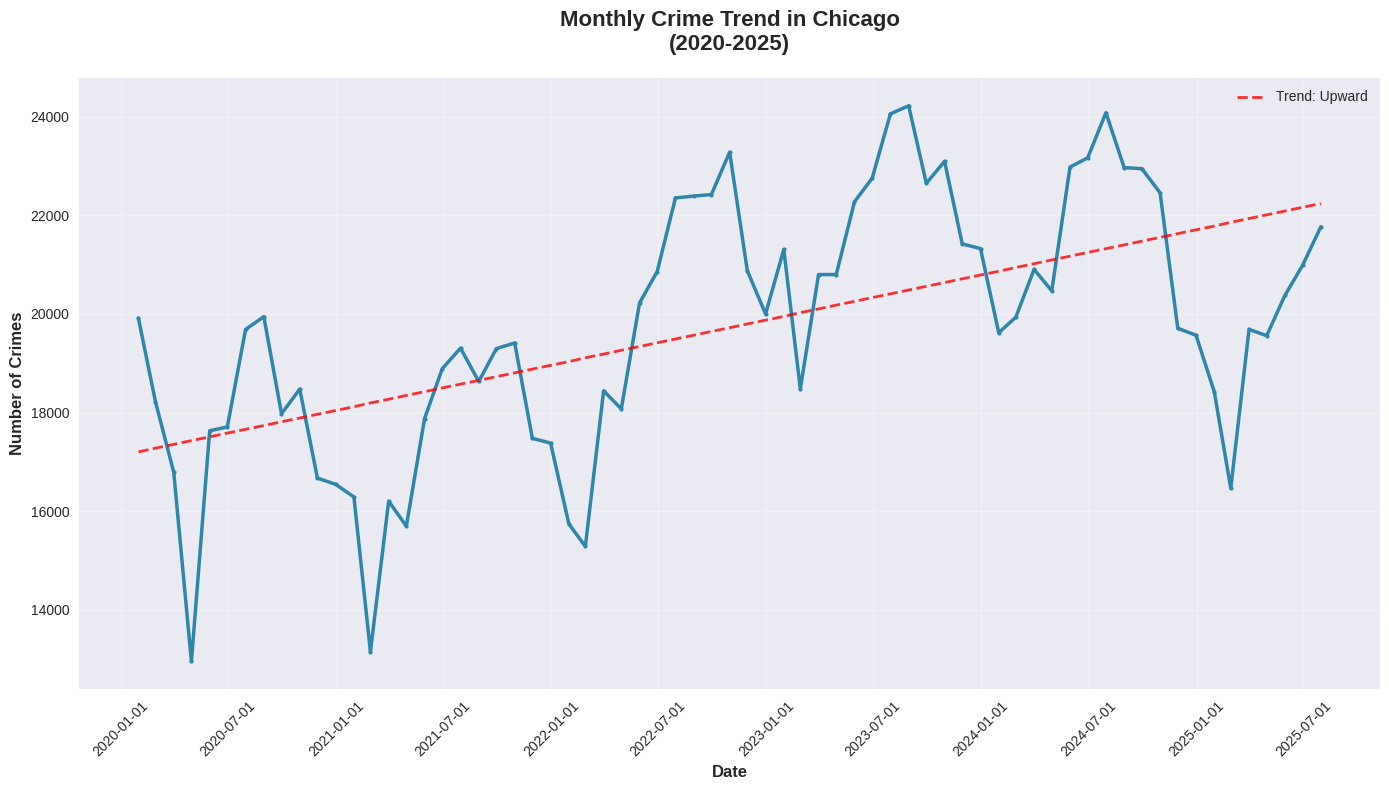

In [ ]:
# Cell 3: Exploratory analysis and monthly trend
print("=== TEMPORAL EXPLORATORY ANALYSIS ===")

# Monthly time series (ONLY UP TO JULY 2025)
monthly_crimes = df.resample('M', on='Date').size()
monthly_crimes = monthly_crimes[monthly_crimes.index <= cutoff_date]

# MAIN VISUALIZATION - MONTHLY TREND
plt.figure(figsize=(14, 8))
plt.plot(monthly_crimes.index, monthly_crimes.values, linewidth=2.5, color='#2E86AB', marker='o', markersize=3)
plt.title('Monthly Crime Trend in Chicago\n(2020-2025)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Crimes', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Format x-axis to show full years
plt.xticks(pd.date_range(start='2020-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

# Add trend line
x_numeric = np.arange(len(monthly_crimes))
z = np.polyfit(x_numeric, monthly_crimes.values, 1)
p = np.poly1d(z)
plt.plot(monthly_crimes.index, p(x_numeric), "r--", alpha=0.8, linewidth=2,
         label=f'Trend: {"Upward" if z[0] > 0 else "Downward"}')

plt.legend()
plt.tight_layout()
plt.show()

=== TEMPORAL EXPLORATORY ANALYSIS ===


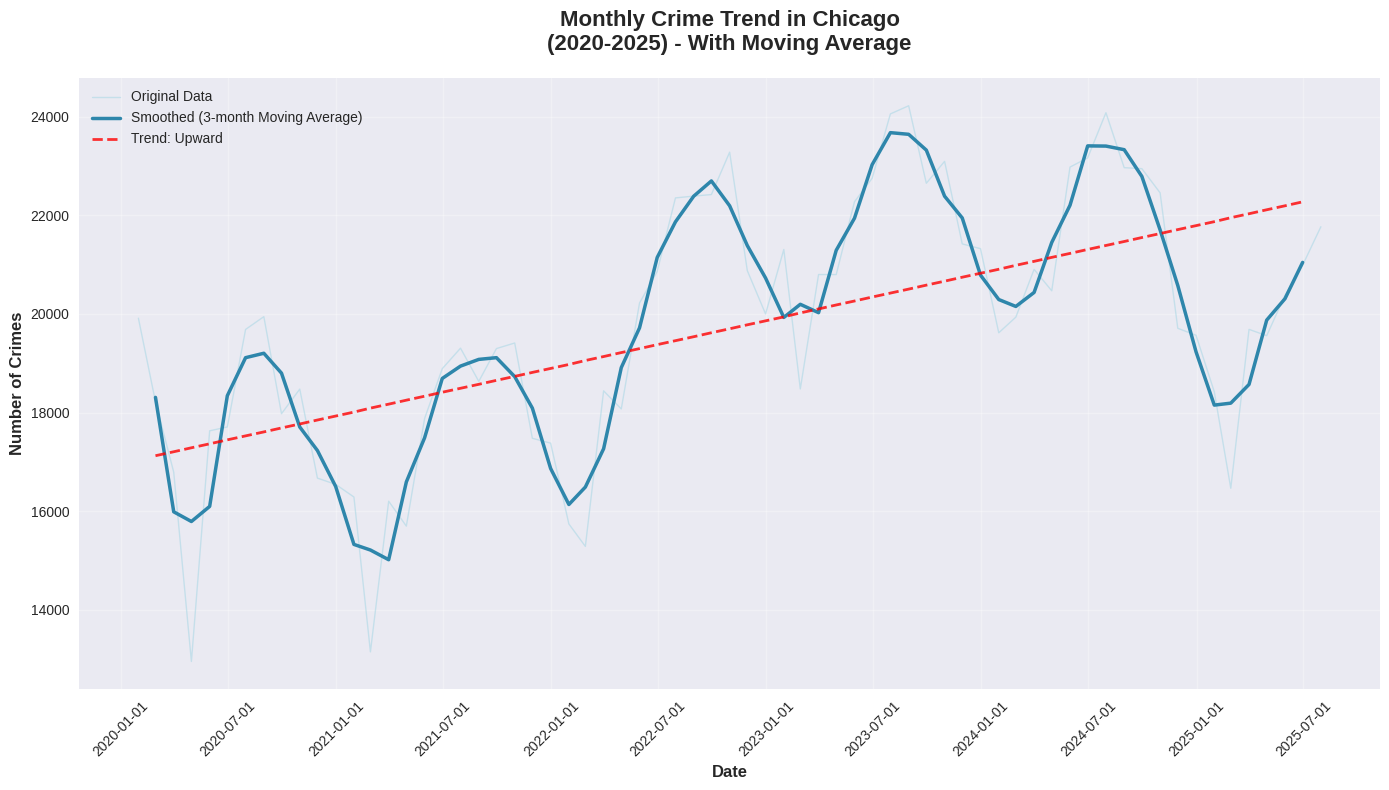

In [ ]:
# Cell 3: Exploratory analysis and monthly trend WITH MOVING AVERAGE
print("=== TEMPORAL EXPLORATORY ANALYSIS ===")

# Monthly time series (ONLY UP TO JULY 2025)
monthly_crimes = df.resample('M', on='Date').size()
monthly_crimes = monthly_crimes[monthly_crimes.index <= cutoff_date]

# Apply 3-month moving average to smooth the data
monthly_smoothed = monthly_crimes.rolling(window=3, center=True).mean()

# MAIN VISUALIZATION - MONTHLY TREND WITH MOVING AVERAGE
plt.figure(figsize=(14, 8))

# Plot original data (thin line)
plt.plot(monthly_crimes.index, monthly_crimes.values,
         linewidth=1, color='lightblue', alpha=0.6,
         label='Original Data')

# Plot smoothed data (thick line)
plt.plot(monthly_smoothed.index, monthly_smoothed.values,
         linewidth=2.5, color='#2E86AB',
         label='Smoothed (3-month Moving Average)')

plt.title('Monthly Crime Trend in Chicago\n(2020-2025) - With Moving Average',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Crimes', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Format x-axis to show full years
plt.xticks(pd.date_range(start='2020-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

# Add trend line to the SMOOTHED data
x_numeric_smooth = np.arange(len(monthly_smoothed.dropna()))
z_smooth = np.polyfit(x_numeric_smooth, monthly_smoothed.dropna().values, 1)
p_smooth = np.poly1d(z_smooth)
plt.plot(monthly_smoothed.dropna().index, p_smooth(x_numeric_smooth), "r--",
         alpha=0.8, linewidth=2,
         label=f'Trend: {"Upward" if z_smooth[0] > 0 else "Downward"}')

plt.legend()
plt.tight_layout()
plt.show()




=== ANALYSIS BY CRIME TYPE ===
Top 5 crime types:
  1. THEFT: 287,210 cases
  2. BATTERY: 237,938 cases
  3. CRIMINAL DAMAGE: 150,736 cases
  4. ASSAULT: 118,086 cases
  5. MOTOR VEHICLE THEFT: 102,640 cases


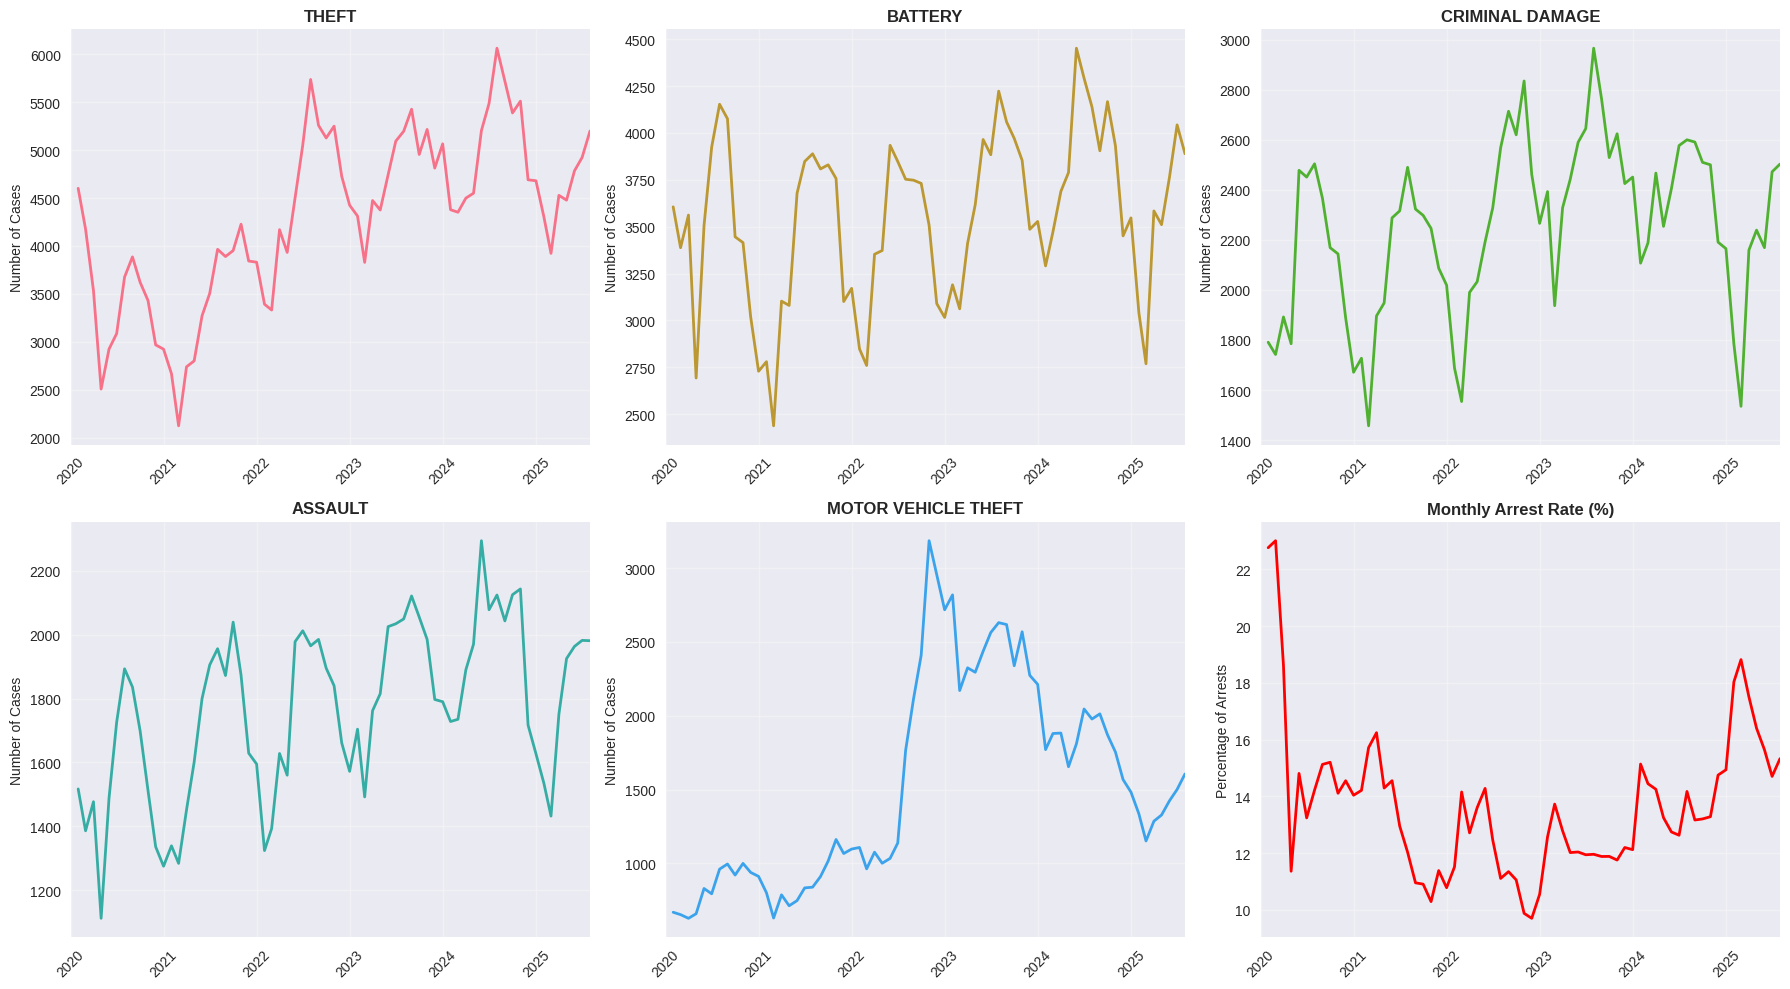

In [ ]:
# Cell 4: Analysis by crime type
print("\n=== ANALYSIS BY CRIME TYPE ===")

top_crimes = df['Primary Type'].value_counts().head(10)
top_5_crimes = top_crimes.head(5).index.tolist()

print("Top 5 crime types:")
for i, crime_type in enumerate(top_5_crimes, 1):
    count = top_crimes[crime_type]
    print(f"  {i}. {crime_type}: {count:,} cases")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, crime_type in enumerate(top_5_crimes):
    crime_ts = df[df['Primary Type'] == crime_type].resample('M', on='Date').size()
    crime_ts = crime_ts[crime_ts.index <= cutoff_date]

    axes[i].plot(crime_ts.index, crime_ts.values, linewidth=2, color=f'C{i}')
    axes[i].set_title(f'{crime_type}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Number of Cases', fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

# Arrest trend
arrest_ts = df.resample('M', on='Date')['Arrest'].mean() * 100
arrest_ts = arrest_ts[arrest_ts.index <= cutoff_date]

axes[5].plot(arrest_ts.index, arrest_ts.values, linewidth=2, color='red')
axes[5].set_title('Monthly Arrest Rate (%)', fontweight='bold', fontsize=12)
axes[5].set_ylabel('Percentage of Arrests', fontsize=10)
axes[5].grid(True, alpha=0.3)
axes[5].tick_params(axis='x', rotation=45)
axes[5].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

plt.tight_layout()
plt.show()


=== ANALYSIS BY DAY OF THE WEEK ===
Crimes by day of the week:
  Monday: 188,957 crimes (14.3%)
  Tuesday: 185,622 crimes (14.0%)
  Wednesday: 187,576 crimes (14.2%)
  Thursday: 184,458 crimes (14.0%)
  Friday: 193,576 crimes (14.7%)
  Saturday: 191,982 crimes (14.5%)
  Sunday: 189,004 crimes (14.3%)


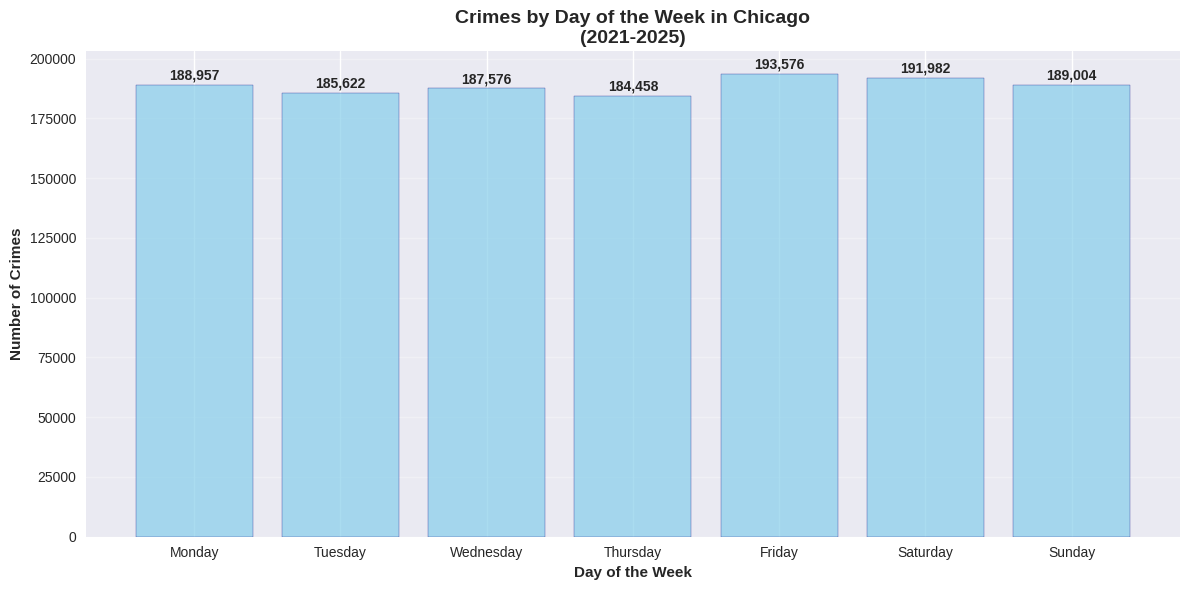


 DAY WITH HIGHEST INCIDENCE: Friday (193,576 crimes)


In [ ]:
# Analysis of days of the week
print("\n=== ANALYSIS BY DAY OF THE WEEK ===")

# Count crimes by day of the week
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Crimes by day of the week:")
for i, (day_num, count) in enumerate(dow_counts.items()):
    percentage = (count / len(df)) * 100
    print(f"  {dow_names[day_num]}: {count:,} crimes ({percentage:.1f}%)")

# Main chart
plt.figure(figsize=(12, 6))
bars = plt.bar(dow_names, dow_counts.values, color='skyblue', alpha=0.7, edgecolor='navy')

plt.title('Crimes by Day of the Week in Chicago\n(2021-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Crimes', fontweight='bold')
plt.xlabel('Day of the Week', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add values on the bars
for bar, count in zip(bars, dow_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

max_day = dow_names[dow_counts.idxmax()]
max_count = dow_counts.max()
print(f"\n DAY WITH HIGHEST INCIDENCE: {max_day} ({max_count:,} crimes)")

In [ ]:
# Analysis of days of the week by crime type (Top 5)
print("\n" + "="*70)
print("ANALYSIS OF DAYS OF THE WEEK BY CRIME TYPE (TOP 5)")
print("="*70)

# Define the top 5 crime types
top_5_crimes = {
    'THEFT':287210,
    'BATTERY': 237938,
    'CRIMINAL DAMAGE': 150736,
    'ASSAULT': 118086,
    'MOTOR VEHICLE THEFT': 102640
}

dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_names_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print("\n DETAILED ANALYSIS BY CRIME TYPE:\n")

for crime_type in top_5_crimes.keys():
    print(f"\n {crime_type}:")
    print("-" * 50)

    # Filter data for this crime type
    crime_data = df[df['Primary Type'] == crime_type]
    total_crimes = len(crime_data)

    # Count by day of the week
    crime_by_dow = crime_data['DayOfWeek'].value_counts().sort_index()

    # Find day with maximum and minimum
    max_day_index = crime_by_dow.idxmax()
    min_day_index = crime_by_dow.idxmin()
    max_day_count = crime_by_dow.max()
    min_day_count = crime_by_dow.min()

    print(f"Total: {total_crimes:,} cases")
    print(f" DAY WITH MOST CASES: {dow_names[max_day_index]} ({max_day_count:,} cases - {max_day_count/total_crimes*100:.1f}%)")
    print(f" DAY WITH LEAST CASES: {dow_names[min_day_index]} ({min_day_count:,} cases - {min_day_count/total_crimes*100:.1f}%)")

    # Show full distribution
    print("\nDistribution by day:")
    for day_num in range(7):
        count = crime_by_dow.get(day_num, 0)
        percentage = (count / total_crimes) * 100
        print(f"  {dow_names_short[day_num]}: {count:>6,} cases ({percentage:5.1f}%)")

# COMPARATIVE ANALYSIS
print("\n" + "="*70)
print(" COMPARATIVE ANALYSIS - PATTERNS BY CRIME TYPE")
print("="*70)

# Create analysis matrix
crime_patterns = {}

for crime_type in top_5_crimes.keys():
    crime_data = df[df['Primary Type'] == crime_type]
    crime_by_dow = crime_data['DayOfWeek'].value_counts().sort_index()

    # Normalize the data (percentage per day)
    total = crime_by_dow.sum()
    crime_patterns[crime_type] = [crime_by_dow.get(i, 0)/total * 100 for i in range(7)]

# Identify common patterns
print("\n IDENTIFIED PATTERNS:")

# Day with most crime in general
overall_pattern = df['DayOfWeek'].value_counts().sort_index()
overall_max_day = overall_pattern.idxmax()
print(f"\n• DAY WITH MOST CRIMES OVERALL: {dow_names[overall_max_day]}")

# Specific patterns by crime type
print("\n• PEAK DAYS BY CRIME TYPE:")
for crime_type in top_5_crimes.keys():
    crime_data = df[df['Primary Type'] == crime_type]
    crime_by_dow = crime_data['DayOfWeek'].value_counts().sort_index()
    max_day = crime_by_dow.idxmax()
    max_percentage = (crime_by_dow.max() / crime_by_dow.sum()) * 100

    print(f"  {crime_type:<25} → {dow_names[max_day]:<12} ({max_percentage:.1f}% of total)")

# Weekend vs weekday analysis
print("\n• WEEKEND VS WEEKDAY BEHAVIOR:")
weekend_days = [5, 6]  # Saturday and Sunday
weekday_days = [0, 1, 2, 3, 4]  # Monday to Friday

for crime_type in top_5_crimes.keys():
    crime_data = df[df['Primary Type'] == crime_type]
    total_crimes = len(crime_data)

    weekend_crimes = crime_data[crime_data['DayOfWeek'].isin(weekend_days)].shape[0]
    weekday_crimes = crime_data[crime_data['DayOfWeek'].isin(weekday_days)].shape[0]

    weekend_percentage = (weekend_crimes / total_crimes) * 100
    weekday_percentage = (weekday_crimes / total_crimes) * 100

    print(f"  {crime_type:<25} → Weekday: {weekday_percentage:5.1f}% | Weekend: {weekend_percentage:5.1f}%")

# EXECUTIVE SUMMARY
print("\n" + "="*70)
print(" EXECUTIVE SUMMARY - STRATEGIC RECOMMENDATIONS")
print("="*70)

print("\n RECOMMENDATIONS BY CRIME TYPE:")

recommendations = {
    'THEFT': "Reinforcement in commercial areas and shops",
    'BATTERY': "Patrolling in nightlife entertainment areas",
    'CRIMINAL DAMAGE': "Surveillance in residential areas and vehicles",
    'ASSAULT': "Police presence in high concentration areas",
    'MOTOR VEHICLE THEFT': "Vehicle checkpoints and surveillance in parking lots"
}

for crime_type in top_5_crimes.keys():
    crime_data = df[df['Primary Type'] == crime_type]
    crime_by_dow = crime_data['DayOfWeek'].value_counts().sort_index()
    max_day = crime_by_dow.idxmax()

    print(f"\n {crime_type}:")
    print(f"   Critical day: {dow_names[max_day]}")
    print(f"   Recommendation: {recommendations[crime_type]}")
    print(f"   Strategy: Intensify patrolling on {dow_names[max_day]}s")

print(f"\n GENERAL INSIGHT:")
general_max_day = df['DayOfWeek'].value_counts().idxmax()
print(f"   {dow_names[general_max_day]} is the day with the highest overall criminal activity")
print("   Consider resource reallocation to cover specific peaks")




ANALYSIS OF DAYS OF THE WEEK BY CRIME TYPE (TOP 5)

 DETAILED ANALYSIS BY CRIME TYPE:


 THEFT:
--------------------------------------------------
Total: 287,210 cases
 DAY WITH MOST CASES: Friday (43,737 cases - 15.2%)
 DAY WITH LEAST CASES: Sunday (36,705 cases - 12.8%)

Distribution by day:
  Mon: 40,278 cases ( 14.0%)
  Tue: 41,383 cases ( 14.4%)
  Wed: 41,857 cases ( 14.6%)
  Thu: 41,642 cases ( 14.5%)
  Fri: 43,737 cases ( 15.2%)
  Sat: 41,608 cases ( 14.5%)
  Sun: 36,705 cases ( 12.8%)

 BATTERY:
--------------------------------------------------
Total: 237,938 cases
 DAY WITH MOST CASES: Sunday (40,147 cases - 16.9%)
 DAY WITH LEAST CASES: Tuesday (31,103 cases - 13.1%)

Distribution by day:
  Mon: 32,935 cases ( 13.8%)
  Tue: 31,103 cases ( 13.1%)
  Wed: 31,623 cases ( 13.3%)
  Thu: 31,377 cases ( 13.2%)
  Fri: 33,073 cases ( 13.9%)
  Sat: 37,680 cases ( 15.8%)
  Sun: 40,147 cases ( 16.9%)

 CRIMINAL DAMAGE:
--------------------------------------------------
Total: 150,736 ca


=== SEASONALITY ANALYSIS ===


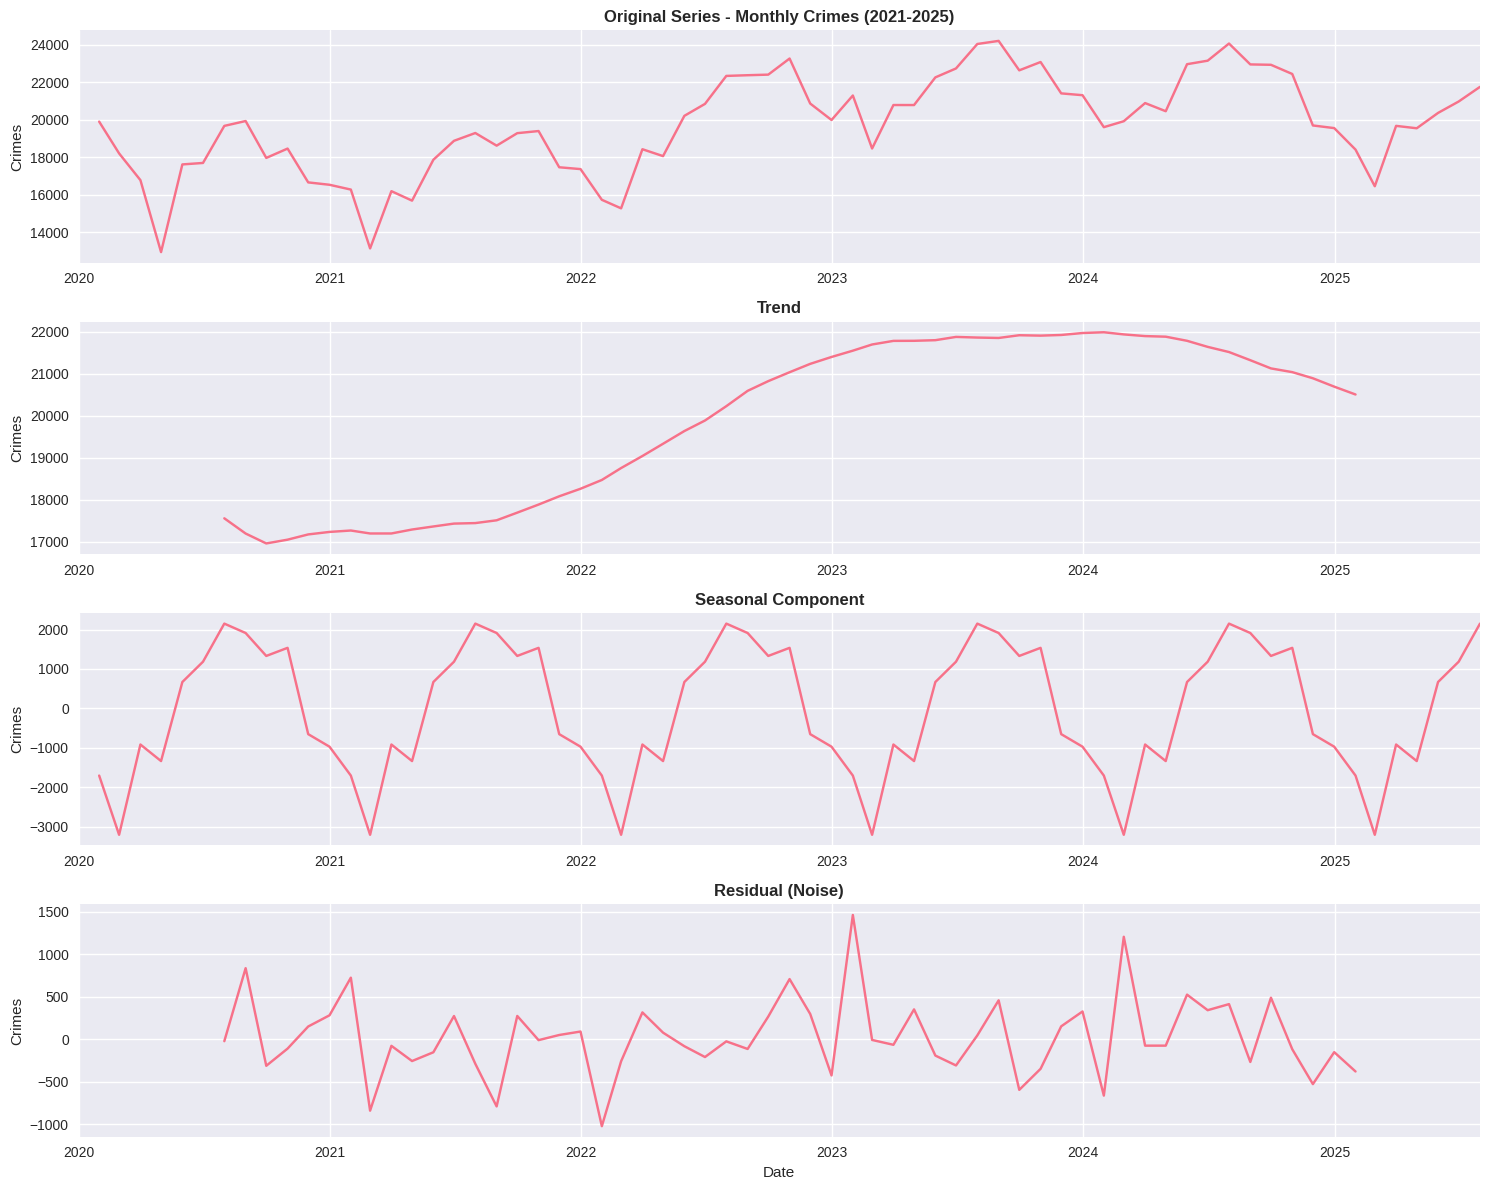

In [ ]:
# Cell 5: Seasonality analysis
print("\n=== SEASONALITY ANALYSIS ===")

monthly_series = monthly_crimes.astype(float)

if monthly_series.isnull().any():
    monthly_series = monthly_series.interpolate()

if len(monthly_series) >= 24:
    try:
        decomposition = seasonal_decompose(monthly_series, model='additive', period=12)

        fig, axes = plt.subplots(4, 1, figsize=(15, 12))

        # Original series
        axes[0].plot(decomposition.observed)
        axes[0].set_title('Original Series - Monthly Crimes (2021-2025)', fontweight='bold')
        axes[0].set_ylabel('Crimes')
        axes[0].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

        # Trend
        axes[1].plot(decomposition.trend)
        axes[1].set_title('Trend', fontweight='bold')
        axes[1].set_ylabel('Crimes')
        axes[1].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

        # Seasonality
        axes[2].plot(decomposition.seasonal)
        axes[2].set_title('Seasonal Component', fontweight='bold')
        axes[2].set_ylabel('Crimes')
        axes[2].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

        # Residual
        axes[3].plot(decomposition.resid)
        axes[3].set_title('Residual (Noise)', fontweight='bold')
        axes[3].set_ylabel('Crimes')
        axes[3].set_xlabel('Date')
        axes[3].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Error in seasonal decomposition: {e}")
else:
    print(" Insufficient data for seasonal decomposition")


=== TEMPORAL ANALYSIS BY STRATEGIC COMMUNITY AREAS ===
Community Areas with highest criminality:
  AUSTIN: 67,964 crimes
  NEAR NORTH SIDE: 54,436 crimes
  NEAR WEST SIDE: 49,615 crimes
  SOUTH SHORE: 45,213 crimes
  LOOP: 40,906 crimes


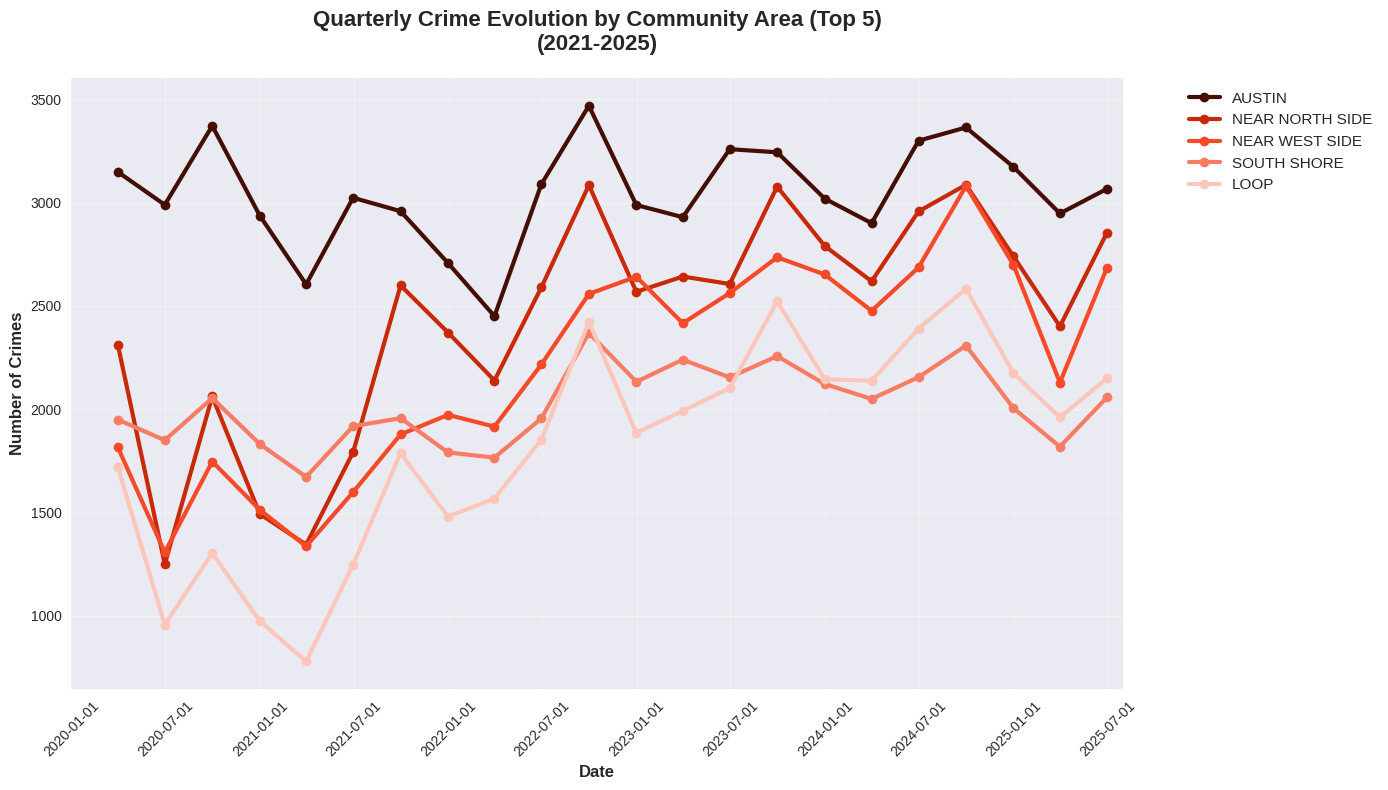

In [ ]:
# Cell 6: Analysis by Community Areas (replaces District analysis)
print("\n=== TEMPORAL ANALYSIS BY STRATEGIC COMMUNITY AREAS ===")

import geopandas as gpd

# Load Community Areas GeoJSON file
communities = gpd.read_file("/content/Boundaries_-_Community_Areas_20251023.geojson")

# Create a GeoDataFrame with crime data
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)

# Ensure both have the same CRS
communities = communities.to_crs("EPSG:4326")

# Perform spatial join
gdf_joined = gpd.sjoin(gdf, communities, how="inner", predicate="within")

# Count crimes by community area
crime_counts = (
    gdf_joined.groupby('community')
    .size()
    .reset_index(name='crime_count')
)

# Sort by crime count and take top 5
top_communities = crime_counts.nlargest(5, 'crime_count')
top_community_names = top_communities['community'].tolist()

print("Community Areas with highest criminality:")
for _, row in top_communities.iterrows():
    print(f"  {row['community']}: {row['crime_count']:,} crimes")

# QUARTERLY EVOLUTION CHART BY COMMUNITY AREA
plt.figure(figsize=(14, 8))

colors = ['#440E03', '#C82909', '#F54927', '#F87C63', '#FCC6BB']

for i, community_name in enumerate(top_community_names):
    # Filter data for this community area and do quarterly resample
    community_data = gdf_joined[gdf_joined['community'] == community_name]
    community_ts = community_data.resample('Q', on='Date').size()
    community_ts = community_ts[community_ts.index <= cutoff_date]

    plt.plot(community_ts.index, community_ts.values,
             label=f'{community_name}',
             linewidth=3,
             color=colors[i],
             marker='o')

plt.title('Quarterly Crime Evolution by Community Area (Top 5)\n(2021-2025)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Crimes', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Configure x-axis limits
plt.xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

# Format x-axis
plt.xticks(pd.date_range(start='2020-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

plt.tight_layout()
plt.show()



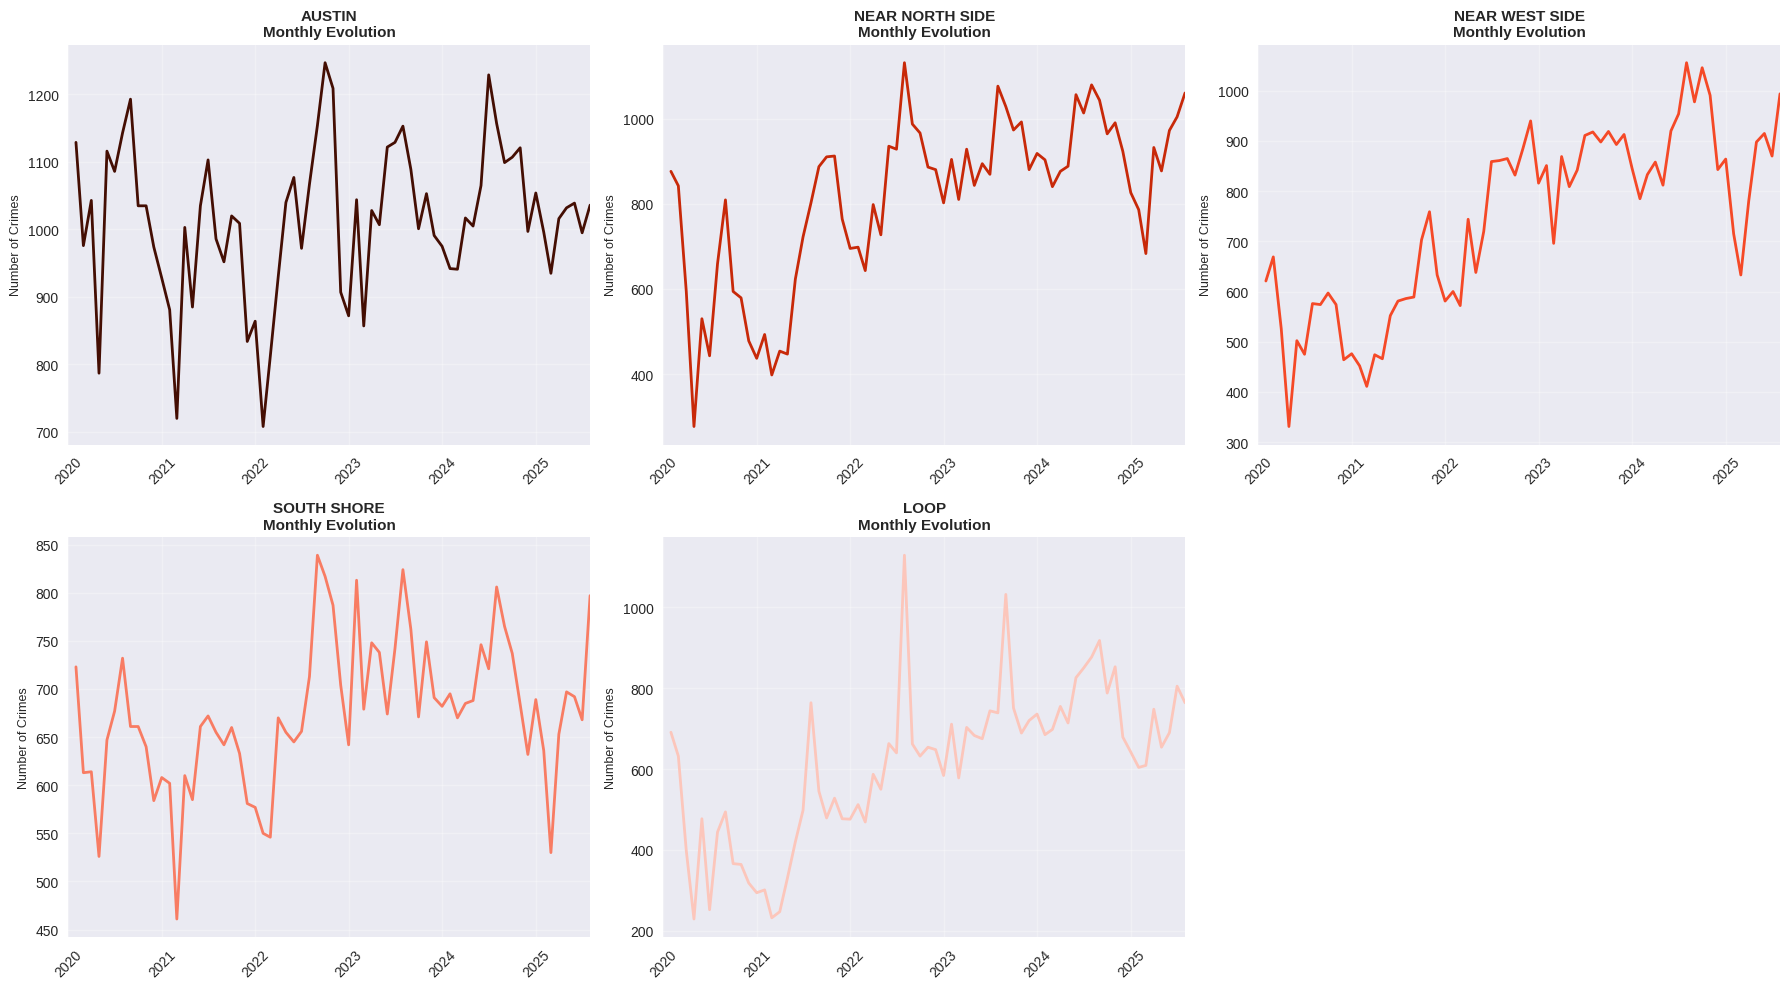

In [ ]:
# Cell 7: Individual charts by Community Area
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, community_name in enumerate(top_community_names):
    community_data = gdf_joined[gdf_joined['community'] == community_name]
    community_ts = community_data.resample('M', on='Date').size()
    community_ts = community_ts[community_ts.index <= cutoff_date]

    axes[i].plot(community_ts.index, community_ts.values,
                linewidth=2,
                color=colors[i])
    axes[i].set_title(f'{community_name}\nMonthly Evolution',
                     fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Number of Crimes', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

# Hide the last subplot if not used
if len(top_community_names) < 6:
    for j in range(len(top_community_names), 6):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

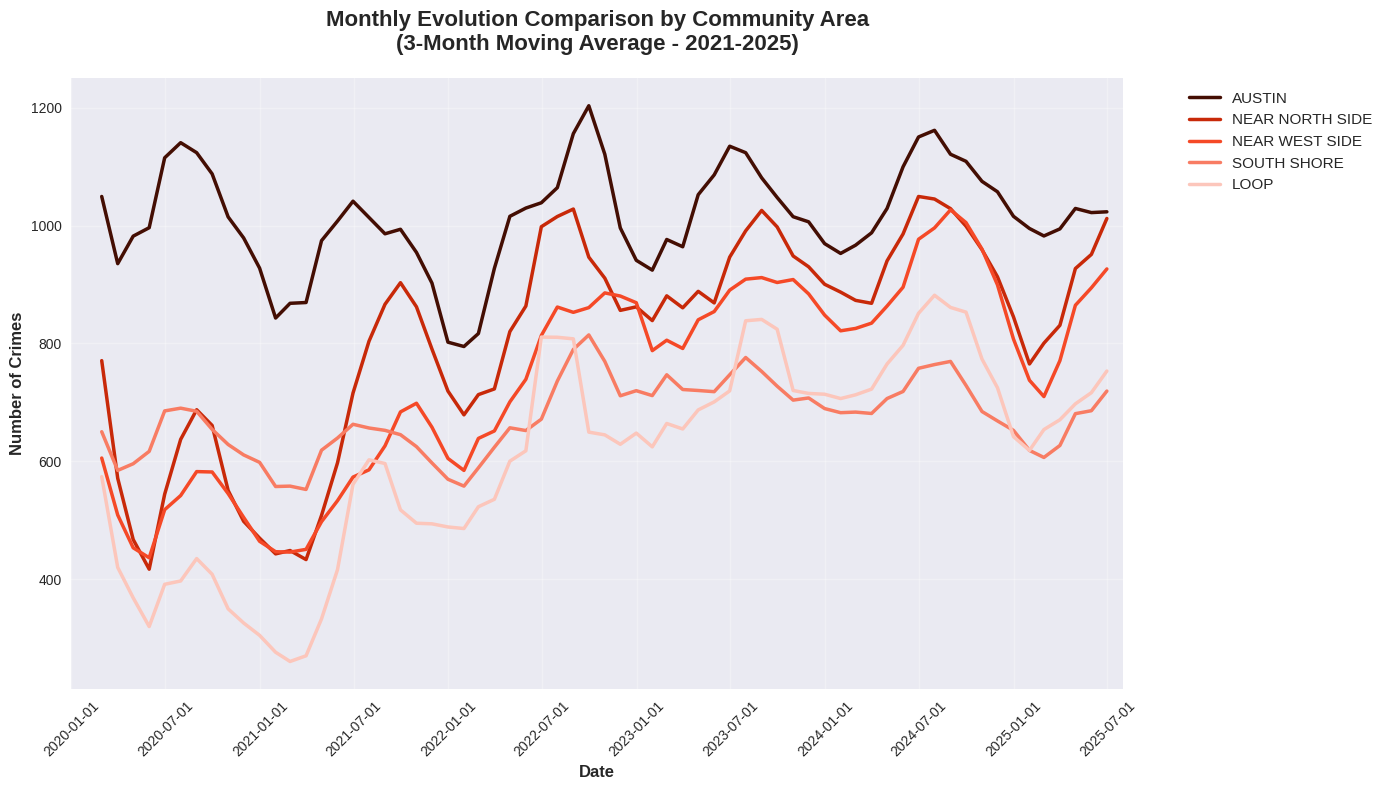

In [ ]:
# Cell 8: Monthly comparison with moving average by Community Area
plt.figure(figsize=(14, 8))

for i, community_name in enumerate(top_community_names):
    community_data = gdf_joined[gdf_joined['community'] == community_name]
    community_ts = community_data.resample('M', on='Date').size()
    community_ts = community_ts[community_ts.index <= cutoff_date]

    # Smooth with 3-month moving average
    if len(community_ts) > 3:
        community_smooth = community_ts.rolling(window=3, center=True).mean()
        plt.plot(community_smooth.index, community_smooth.values,
                label=f'{community_name}',
                linewidth=2.5,
                color=colors[i])
    else:
        plt.plot(community_ts.index, community_ts.values,
                label=f'{community_name}',
                linewidth=2.5,
                color=colors[i])

plt.title('Monthly Evolution Comparison by Community Area\n(3-Month Moving Average - 2021-2025)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Crimes', fontsize=12, fontweight='bold')
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Configure x-axis limits
plt.xlim([pd.Timestamp('2020-01-01'), pd.Timestamp('2025-07-31')])

# Format x-axis
plt.xticks(pd.date_range(start='2020-01-01', end='2025-07-31', freq='6MS'),
           rotation=45)

plt.tight_layout()
plt.show()


=== DETAILED TEMPORAL PATTERN ANALYSIS ===


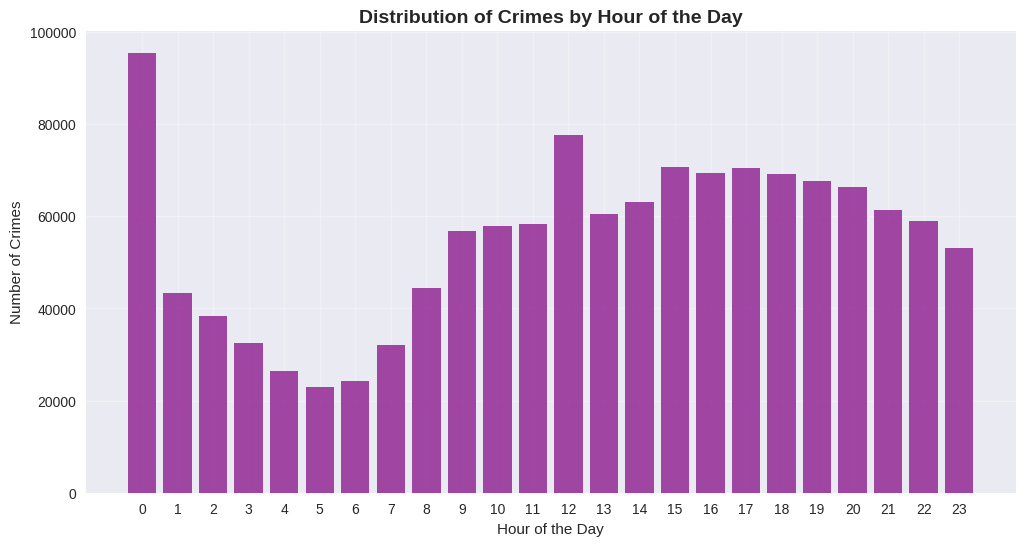


Annual growth rates:
  2021: -1.4%
  2022: +14.5%
  2023: +9.7%
  2024: -1.7%
  2025: -47.0%


In [ ]:
# Cell 9: Analysis of hourly patterns and growth rates
print("\n=== DETAILED TEMPORAL PATTERN ANALYSIS ===")

# Extract hour of the day
try:
    df['Hour'] = df['Date'].dt.hour
    hourly_pattern = df['Hour'].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    plt.bar(hourly_pattern.index, hourly_pattern.values, color='purple', alpha=0.7)
    plt.title('Distribution of Crimes by Hour of the Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Number of Crimes')
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f" Hour information not available: {e}")

# Calculate annual growth rates
yearly_counts = df['Year'].value_counts().sort_index()
yearly_growth = yearly_counts.pct_change() * 100
print("\nAnnual growth rates:")
for year, growth in yearly_growth.items():
    if not pd.isna(growth):
        print(f"  {year}: {growth:+.1f}%")


CONCLUSIONS AND RECOMMENDATIONS FOR THE GOVERNOR

TREND BY COMMUNITY AREA (2021-2025):
  AUSTIN: ↓ DECREASE (-43.4%)
  NEAR NORTH SIDE: ↓ DECREASE (-11.3%)
  NEAR WEST SIDE: ↓ DECREASE (-9.1%)
  SOUTH SHORE: ↓ DECREASE (-39.2%)
  LOOP: ↓ DECREASE (-1.7%)

EXECUTIVE SUMMARY:
• Analyzed period: 2020-01 to 2025-07
• Total incidents: 1,321,175
• Overall trend: DOWNWARD
• Critical Community Areas: AUSTIN, NEAR NORTH SIDE, NEAR WEST SIDE, SOUTH SHORE, LOOP
• Predominant crime types: THEFT, BATTERY, CRIMINAL DAMAGE, ASSAULT, MOTOR VEHICLE THEFT

Key Findings:
1. Seasonal Patterns: Specific seasonal variation with peaks and valleys observed
2. Weekly Seasonality: Fri shows the highest crime incidence
3. Non-Stationarity: The time series shows significant trends and seasonality
4. Geographic Hotspots: AUSTIN and NEAR NORTH SIDE are the highest crime areas

STRATEGIC RECOMMENDATIONS:
1. Police reinforcement in AUSTIN and NEAR NORTH SIDE
2. Preventive programs focused on THEFT and BATTERY
3. Int

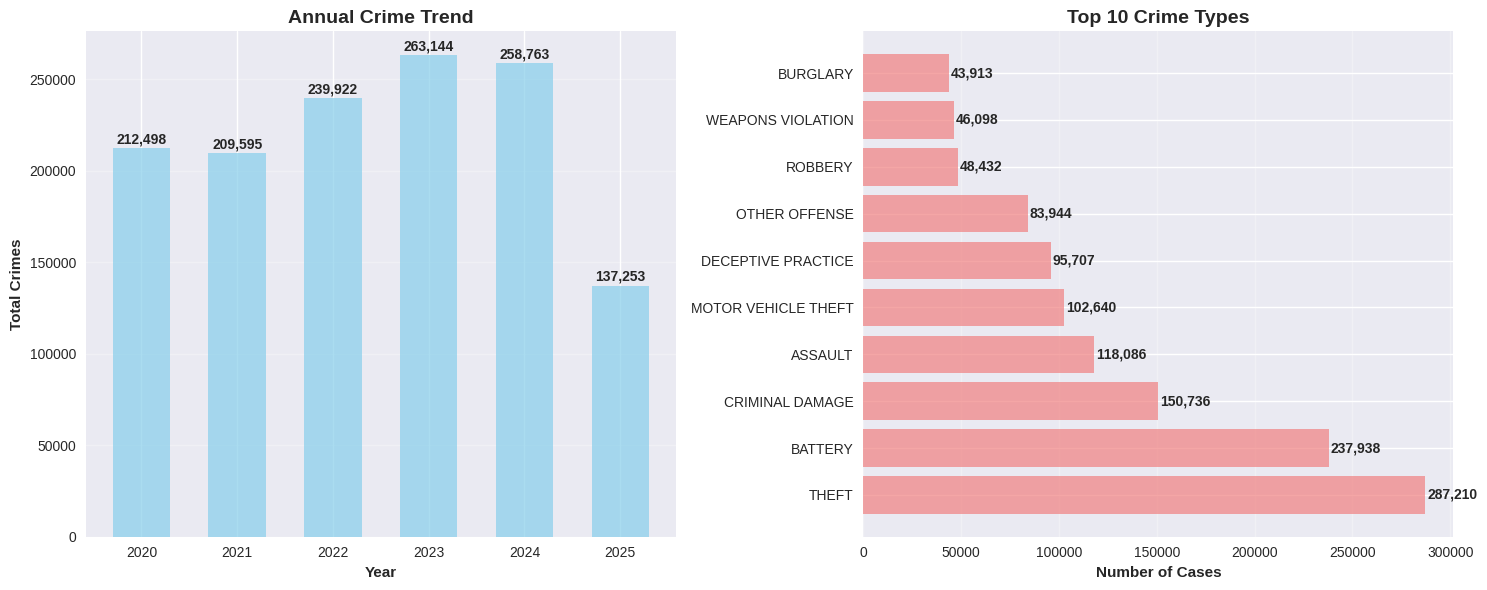

In [ ]:
# Celda 10: Executive summary and conclusions (UPDATED FOR COMMUNITY AREAS)
print("\n" + "="*60)
print("CONCLUSIONS AND RECOMMENDATIONS FOR THE GOVERNOR")
print("="*60)

# Calculate growth rates by COMMUNITY AREA (replacing district)
print("\nTREND BY COMMUNITY AREA (2021-2025):")
for community_name in top_community_names:
    community_data = gdf_joined[gdf_joined['community'] == community_name].resample('Y', on='Date').size()
    if len(community_data) > 1:
        growth = (community_data.iloc[-1] - community_data.iloc[0]) / community_data.iloc[0] * 100
        trend = "↑ INCREASE" if growth > 0 else "↓ DECREASE" if growth < 0 else "→ STABLE"
        print(f"  {community_name}: {trend} ({growth:+.1f}%)")

# Variables for the summary
monthly_avg = df.groupby('Month').size()
dow_counts = df['DayOfWeek'].value_counts().sort_index()
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# Get the keys (crime names) from the top_5_crimes dictionary
top_5_crime_names = list(top_5_crimes.keys())

print(f"""
EXECUTIVE SUMMARY:
• Analyzed period: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}
• Total incidents: {len(df):,}
• Overall trend: {'UPWARD' if yearly_growth.iloc[-1] > 0 else 'DOWNWARD' if yearly_growth.iloc[-1] < 0 else 'STABLE'}
• Critical Community Areas: {', '.join(top_community_names)}
• Predominant crime types: {', '.join(top_5_crime_names)}

Key Findings:
1. Seasonal Patterns: Specific seasonal variation with peaks and valleys observed
2. Weekly Seasonality: {dow_names[dow_counts.idxmax()]} shows the highest crime incidence
3. Non-Stationarity: The time series shows significant trends and seasonality
4. Geographic Hotspots: {top_community_names[0]} and {top_community_names[1]} are the highest crime areas

STRATEGIC RECOMMENDATIONS:
1. Police reinforcement in {top_community_names[0]} and {top_community_names[1]}
2. Preventive programs focused on {top_5_crime_names[0]} and {top_5_crime_names[1]}
3. Intensive patrolling on {dow_names[dow_counts.idxmax()]}
4. Continuous monitoring of identified trends in high-risk communities
5. Community-based interventions in {top_community_names[2]} and {top_community_names[3]}
""")

# Corrected final summary visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# CORRECTED ANNUAL SUMMARY - Bar chart instead of line
yearly_counts = df['Year'].value_counts().sort_index()

# Bar chart for full years
axes[0].bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.7, width=0.6)
axes[0].set_title('Annual Crime Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontweight='bold')
axes[0].set_ylabel('Total Crimes', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add values on the bars
for i, v in enumerate(yearly_counts.values):
    axes[0].text(yearly_counts.index[i], v + 1000, f'{v:,}',
                ha='center', va='bottom', fontweight='bold')

# Ensure years are shown as integers
axes[0].set_xticks(yearly_counts.index)
axes[0].set_xticklabels([str(int(year)) for year in yearly_counts.index])

# Distribution by crime type (top 10)
axes[1].barh(range(len(top_crimes)), top_crimes.values, color='lightcoral', alpha=0.7)
axes[1].set_yticks(range(len(top_crimes)))
axes[1].set_yticklabels(top_crimes.index)
axes[1].set_title('Top 10 Crime Types', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Cases', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add values on horizontal bars
for i, v in enumerate(top_crimes.values):
    axes[1].text(v + 1000, i, f'{v:,}',
                va='center', fontweight='bold')

plt.tight_layout()
plt.show()

